In [25]:
import numpy as np
import torch
import pandas as pd
import h5py
from src.interpolate import shift_spectra_linear
from src.ccf import compute_CCFs, get_full_ccf_analysis
from astropy.timeseries import LombScargle
from torch.utils.data import DataLoader

/home/tliopis/Codes/exoplanets_llopis_mary_2025/venv/lib/python3.9/site-packages/numba/core/decorators.py:246: RuntimeWarning: nopython is set for njit and is ignored
  warnings.warn('nopython is set for njit and is ignored', RuntimeWarning)


In [26]:
import matplotlib as mpl
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# 1) D'abord fixer le style de base
plt.style.use("default")  # ou un autre style si tu veux

# 2) Ensuite seulement surcharger avec tes rcParams
mpl.rcParams.update(
    {
        "text.usetex": True,
        "font.family": "serif",
        "font.size": 14,
        "axes.labelsize": 16,
        "axes.titlesize": 16,
        "legend.fontsize": 13,
        "xtick.labelsize": 13,
        "ytick.labelsize": 13,
        "axes.linewidth": 1.2,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
        "xtick.minor.visible": True,
        "ytick.minor.visible": True,
        "xtick.major.size": 6,
        "ytick.major.size": 6,
        "xtick.minor.size": 3,
        "ytick.minor.size": 3,
        "legend.frameon": True,
        "legend.facecolor": "white",
        "legend.edgecolor": "black",
        "legend.framealpha": 0.9,
        "legend.fancybox": False,
        "figure.dpi": 300,
        "savefig.bbox": "tight",
        "savefig.dpi": 300,
        "savefig.format": "pdf",
        "axes.grid": False,
        "grid.alpha": 0.8,
        "grid.linestyle": ":",
    }
)

In [27]:
dset_soap = np.load(
    "../data/npz_datasets/plot_dataset.npz",
)

soap_wavegrid = dset_soap["wavegrid"]
soap_spectra = dset_soap["spectra"]
soap_activity = dset_soap["activity"]
soap_template = dset_soap["template"]
soap_time_values = dset_soap["time_values"]

dset_soap_ccf_activity = np.load("../data/npz_datasets/plot_dataset_ccf_activity.npz", allow_pickle=True)
dset_soap_ccf_activity_planet = np.load("../data/npz_datasets/plot_dataset_ccf_activity_planet.npz", allow_pickle=True)


In [28]:
dset_soap_ccf_activity["metadata"].item().keys()

dict_keys(['n_spectra_file', 'n_spectra', 'n_pixels', 'wavemin', 'wavemax', 'downscaling_factor', 'smooth_after_downscaling', 'smooth_kernel_size', 'add_photon_noise', 'snr_target', 'noise_seed', 'original_pixels', 'downscaled_pixels', 'batch_size', 'planets_periods', 'planets_amplitudes', 'planets_phases', 'activity_definition'])

In [29]:
soap_spectra[0].shape

(10000,)

In [30]:
for key in dset_soap_ccf_activity.keys():
    print(key)
    if key == "metadata":
        for key2 in dset_soap_ccf_activity[key].item().keys():
            print("===", key2)

wavegrid
template
spectra
activity
time_values
v_true
metadata
=== n_spectra_file
=== n_spectra
=== n_pixels
=== wavemin
=== wavemax
=== downscaling_factor
=== smooth_after_downscaling
=== smooth_kernel_size
=== add_photon_noise
=== snr_target
=== noise_seed
=== original_pixels
=== downscaled_pixels
=== batch_size
=== planets_periods
=== planets_amplitudes
=== planets_phases
=== activity_definition
spectra_no_activity


# Contexte scientifique

### Plot d'un spectre

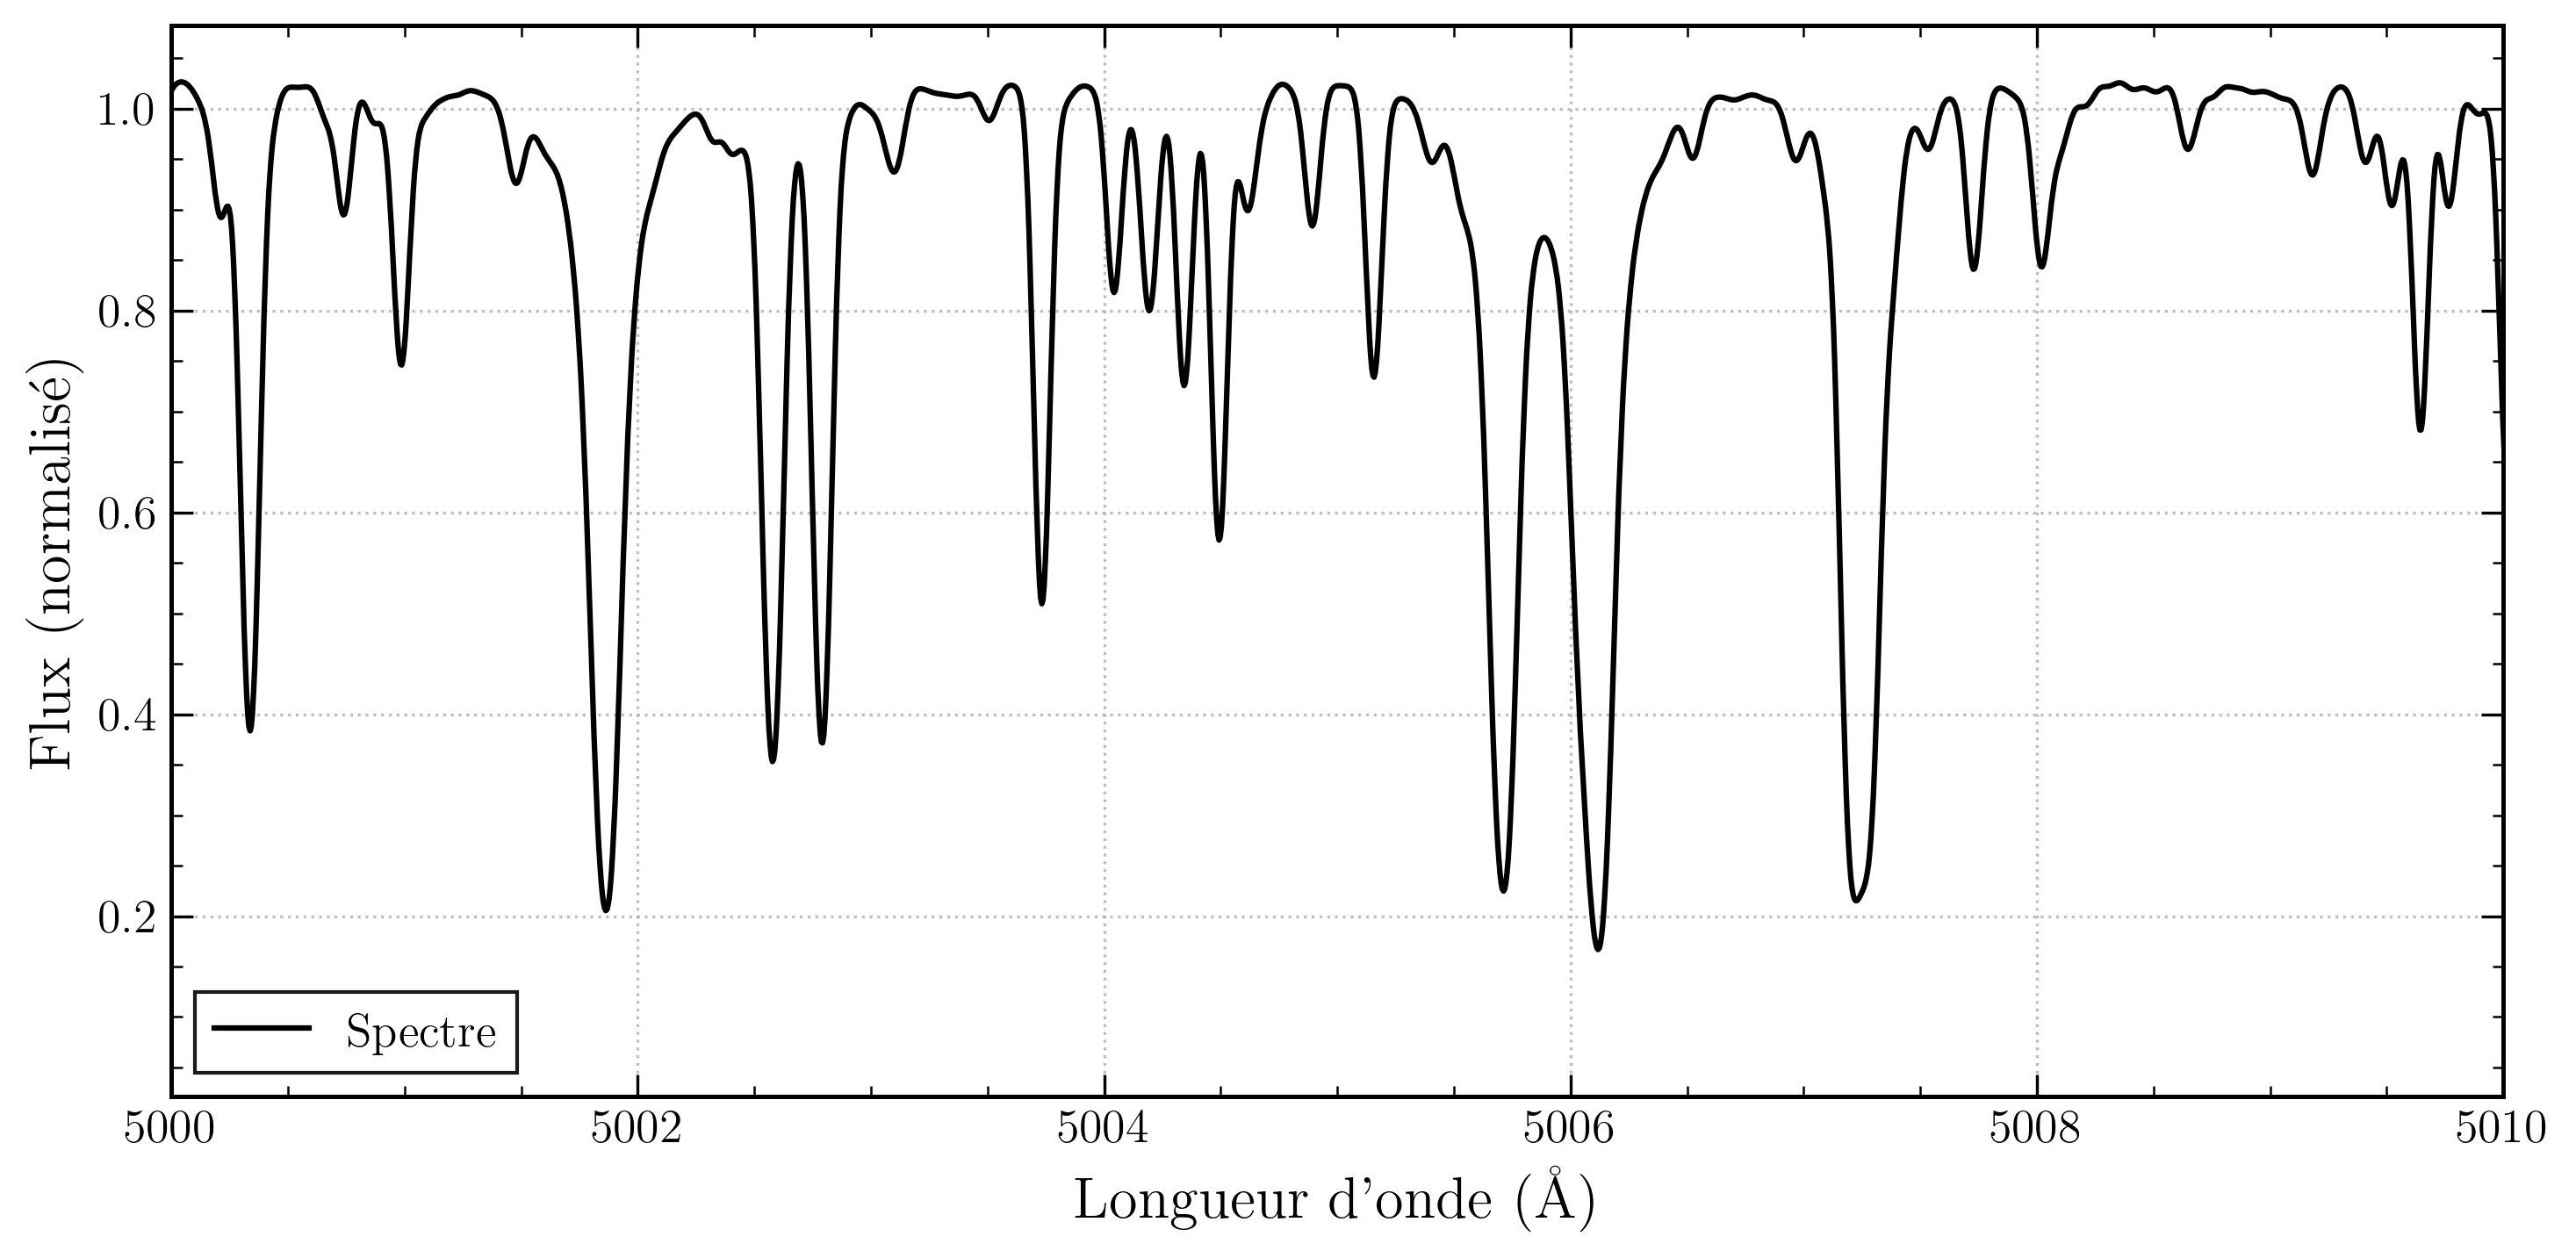

In [31]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre", color="black")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5000, 5010)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/spectrum_example.png",
    dpi=300,
)
plt.show()

In [32]:
t_velocity = torch.tensor([3000]).unsqueeze(0)
t_spectrum = torch.tensor(soap_spectra[0, :]).unsqueeze(0)
t_wavegrid = torch.tensor(soap_wavegrid).unsqueeze(0)

shifted_spectrum = shift_spectra_linear(
    spectra=t_spectrum,
    velocities=t_velocity,
    wavegrid=t_wavegrid
)

shifted_spectrum = shifted_spectrum.squeeze(0).detach().numpy()

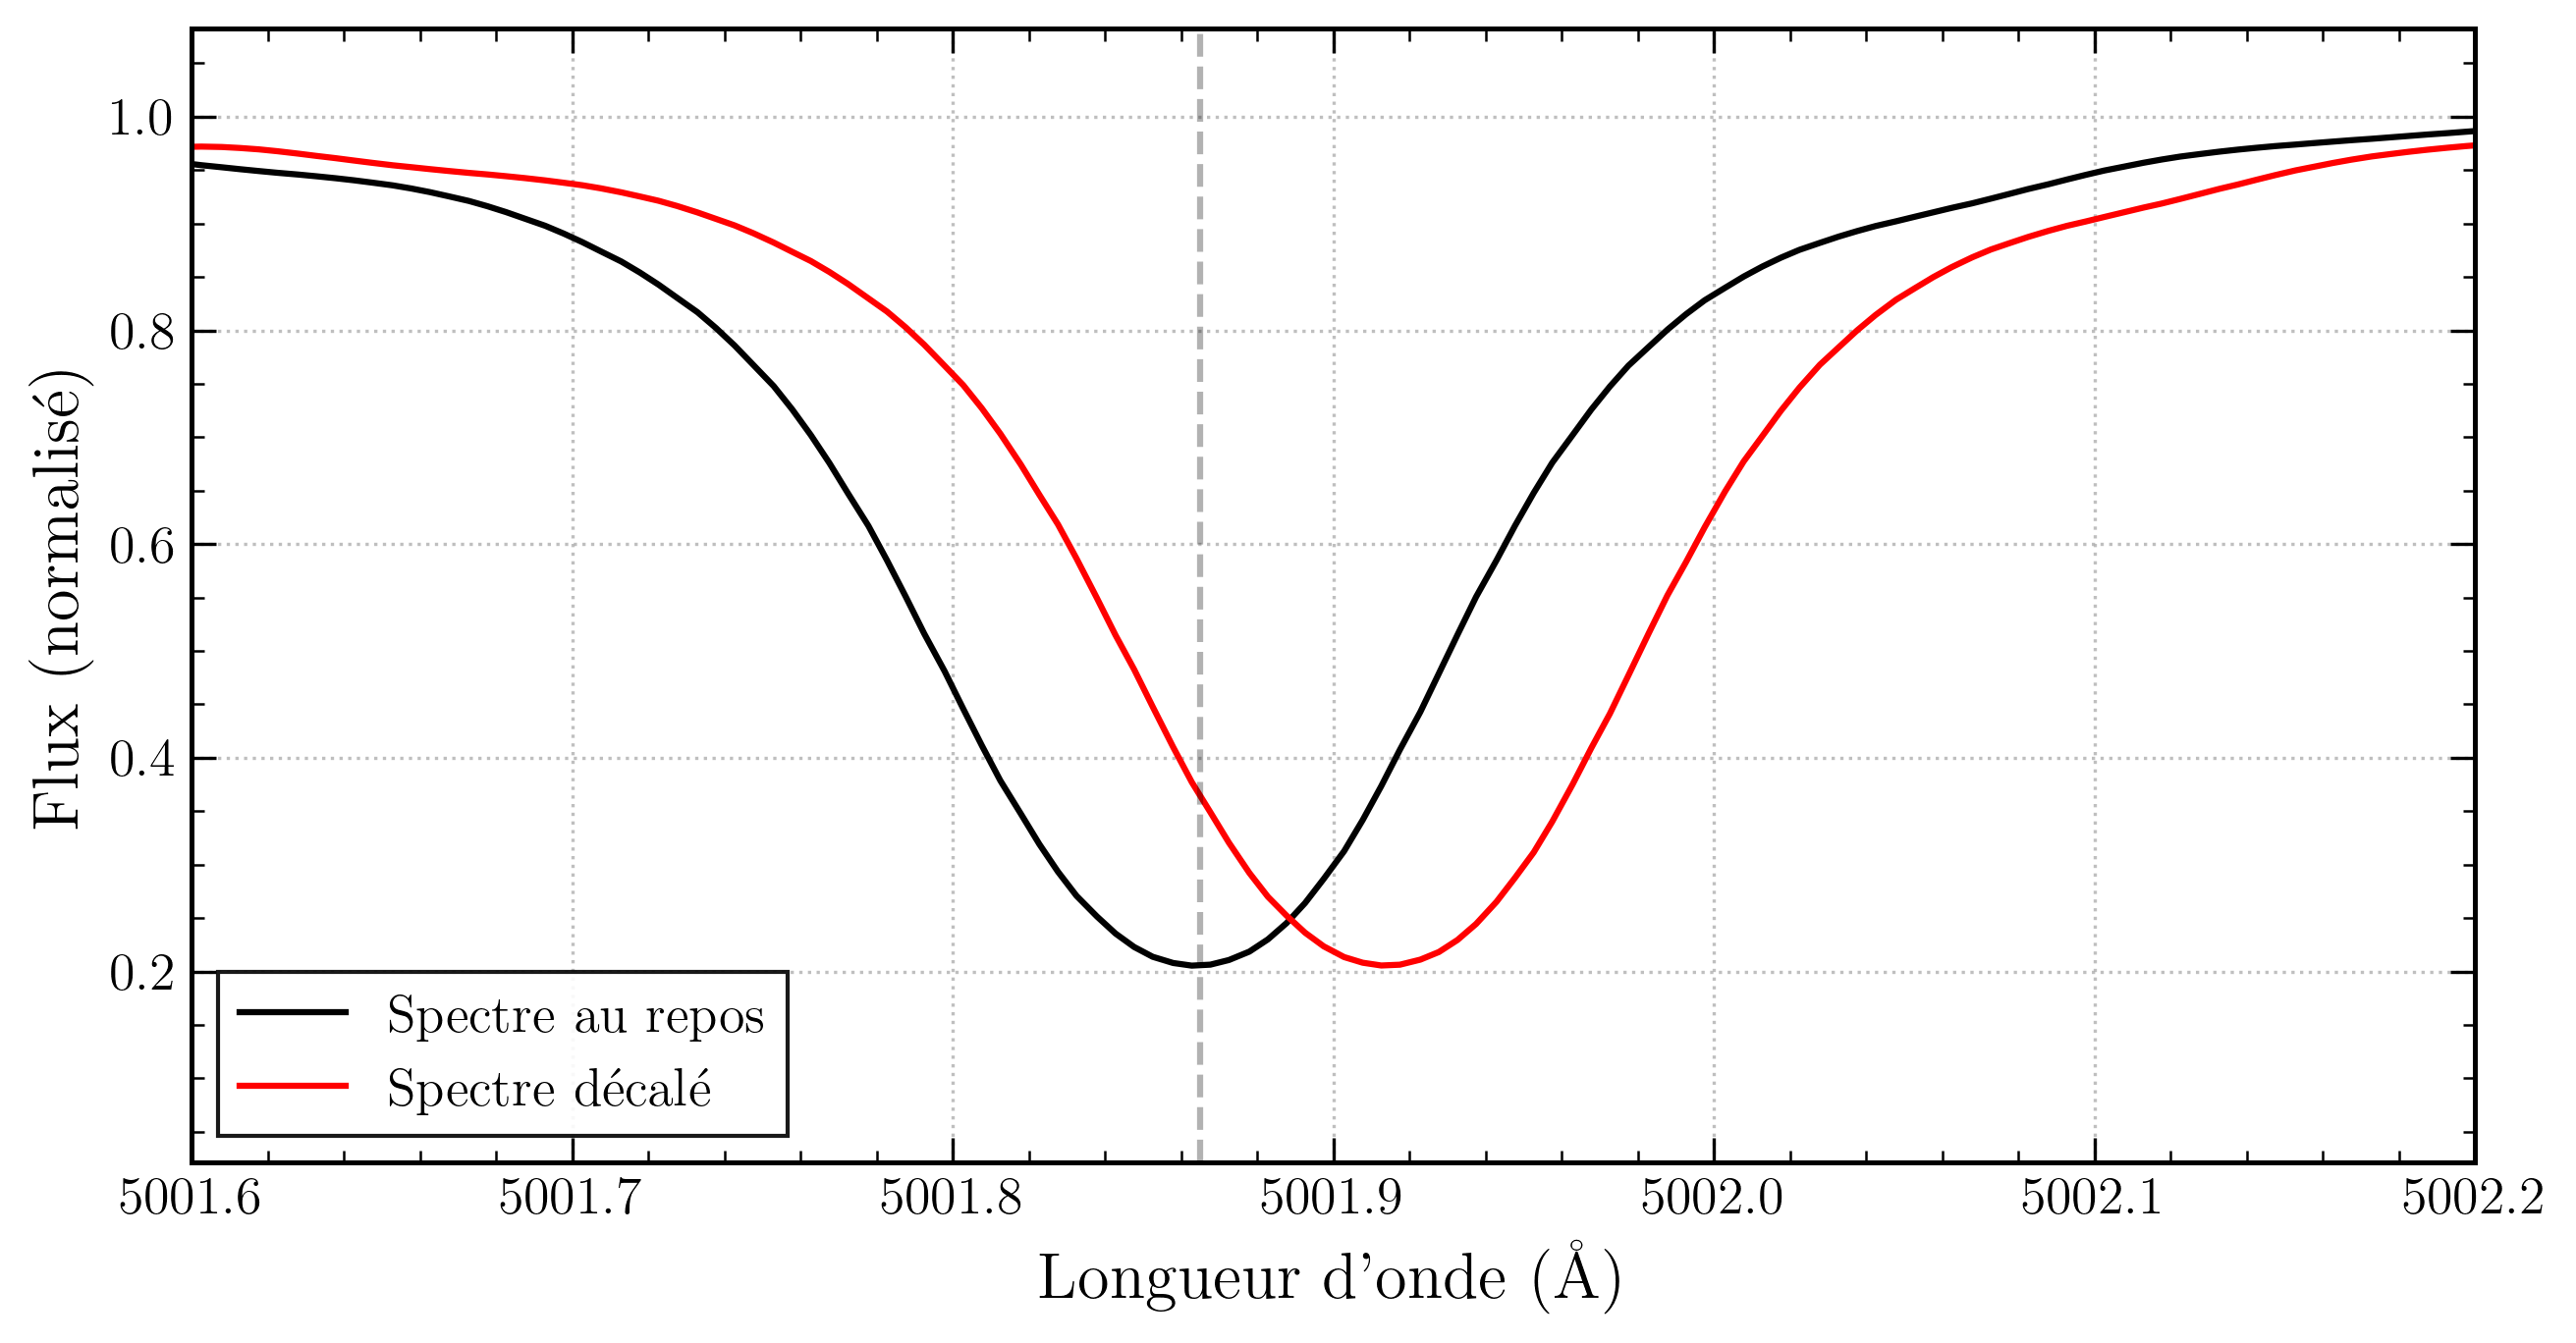

In [33]:
plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_spectra[0, :], label="Spectre au repos", color="black")
plt.plot(soap_wavegrid, shifted_spectrum, label="Spectre décalé", color="red")
plt.axvline(
    x=5001.865,
    color="black",
    linestyle="--",
    alpha=0.3,
)
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid(alpha=0.8)
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/doppler_shift.png",
    dpi=300,
)
plt.show()

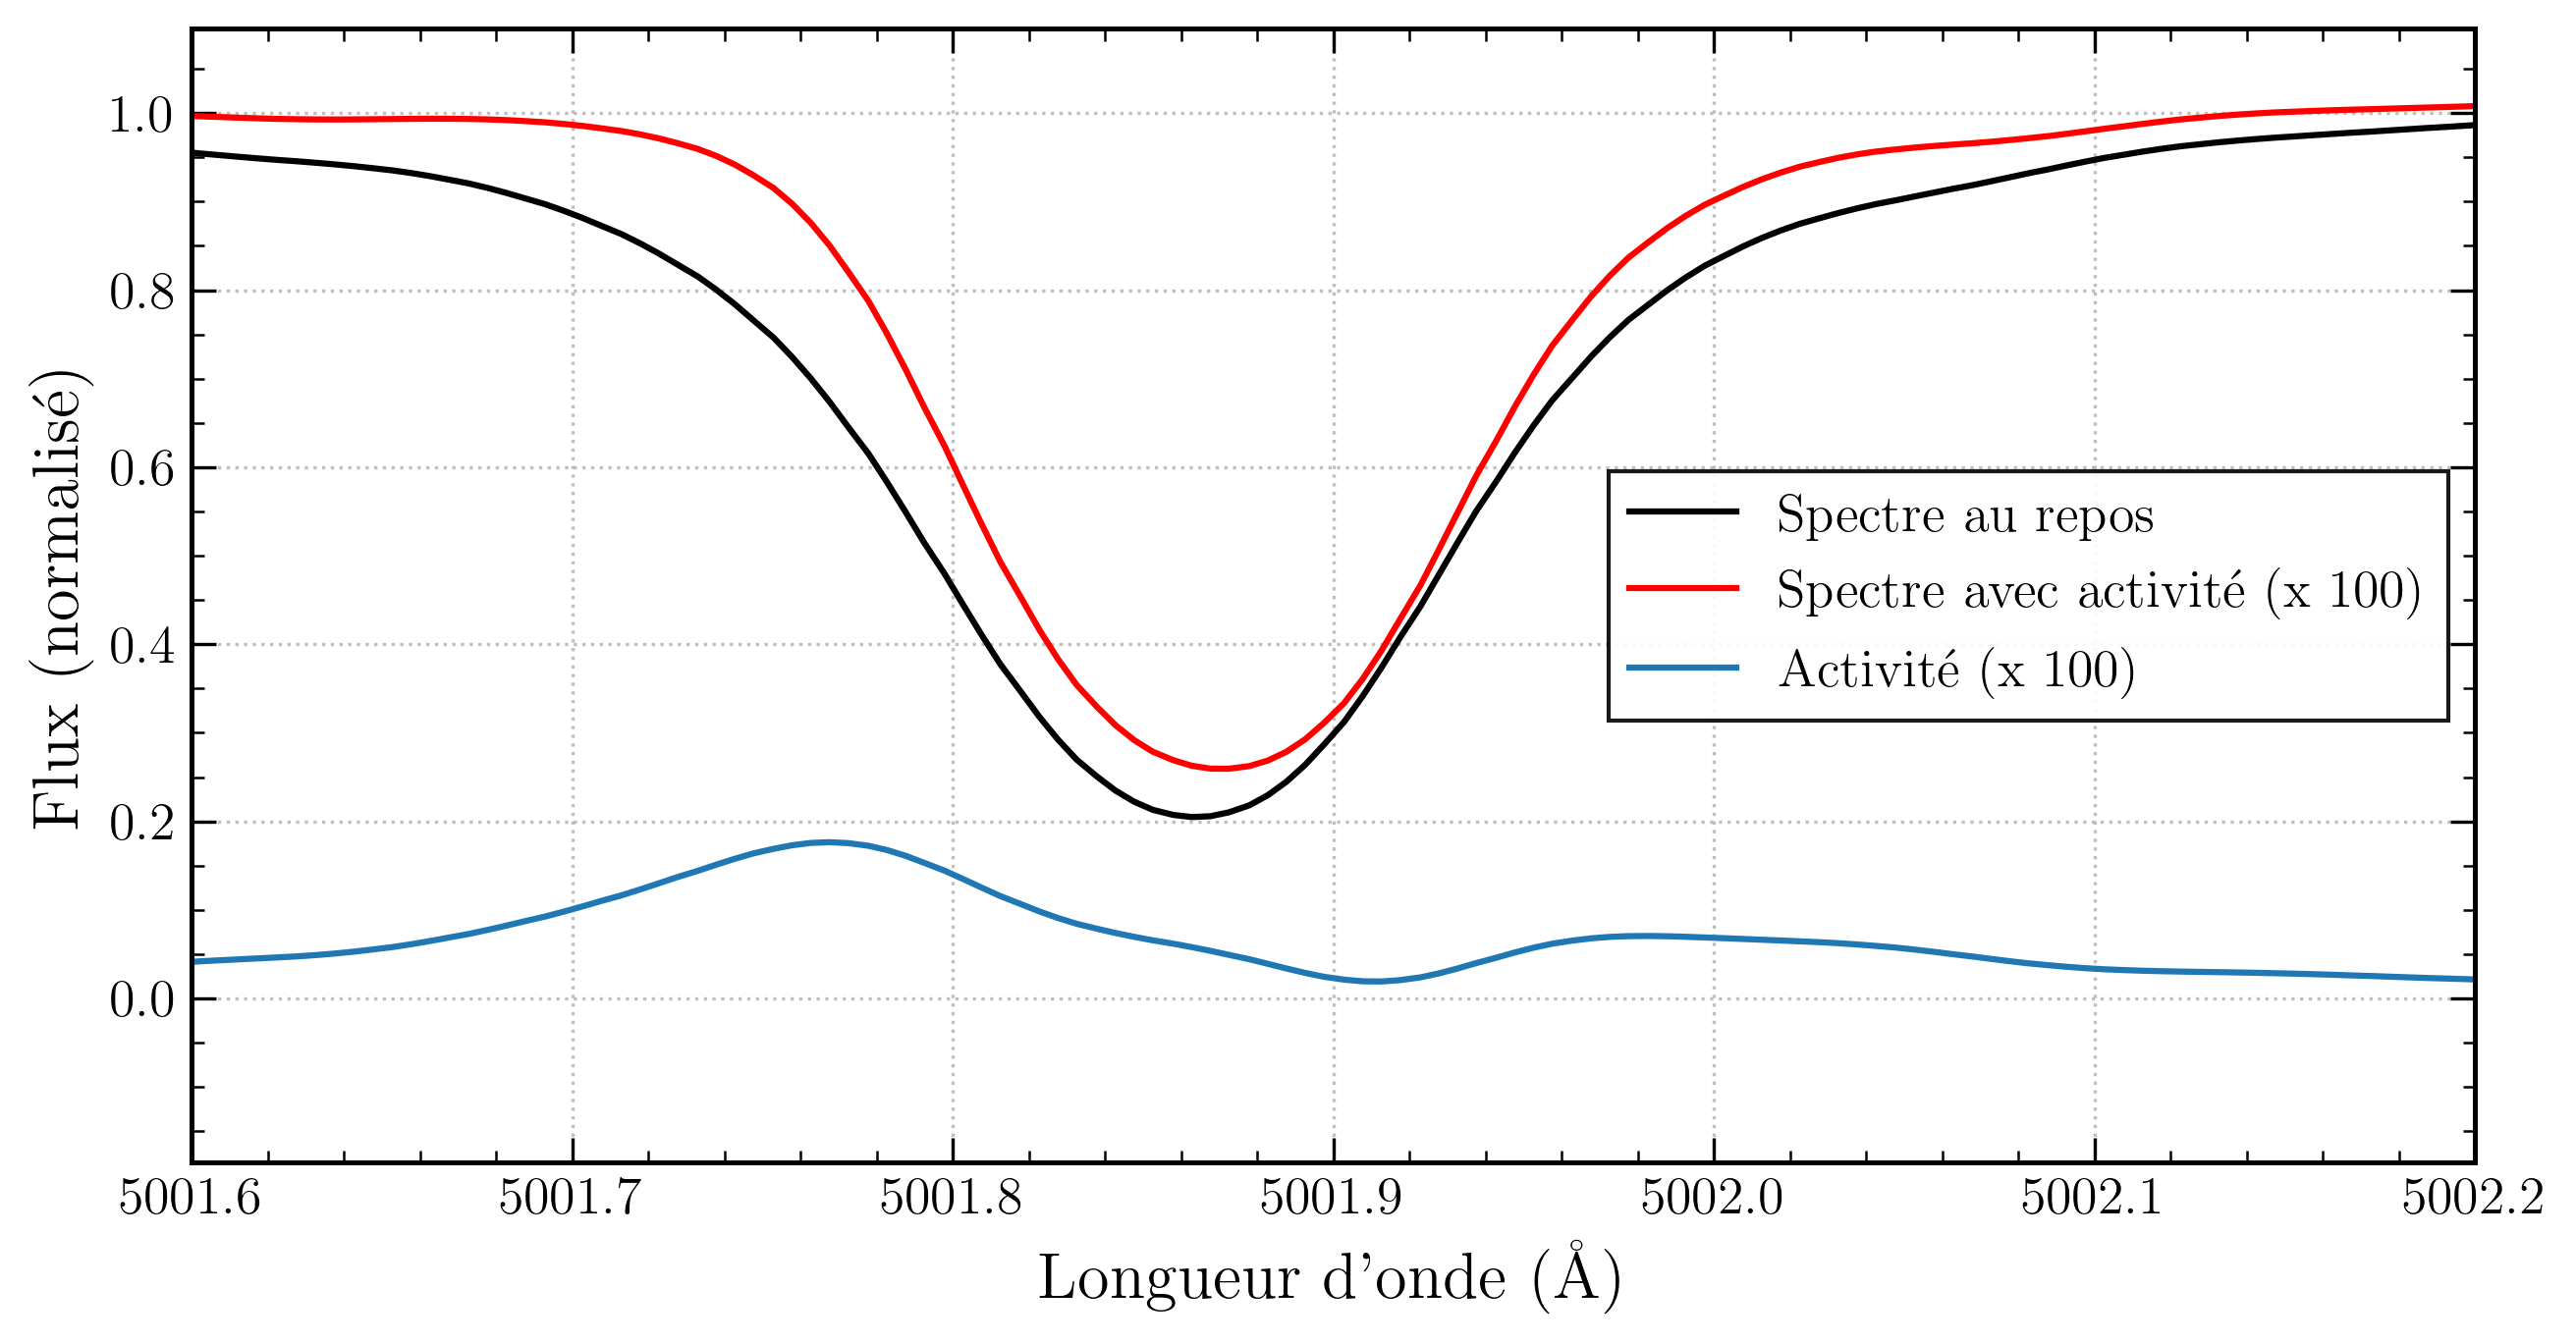

In [34]:

plt.figure(figsize=(10, 5))
plt.plot(soap_wavegrid, soap_template, label="Spectre au repos", color="black")
plt.plot(soap_wavegrid, soap_template + soap_activity[0, :] * 100, label="Spectre avec activité (x 100)", color="red")
plt.plot(
    soap_wavegrid, soap_activity[0, :] * 100, label="Activité (x 100)"
)

plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.6, 5002.2)
plt.grid()
plt.legend()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/activite.png",
    dpi=300,
)
plt.show()


Exception ignored on calling ctypes callback function: <function ExecutionEngine._raw_object_cache_notify at 0x7d1e90feb280>
Traceback (most recent call last):
  File "/home/tliopis/Codes/exoplanets_llopis_mary_2025/venv/lib/python3.9/site-packages/llvmlite/binding/executionengine.py", line 178, in _raw_object_cache_notify
    def _raw_object_cache_notify(self, data):
KeyboardInterrupt: 


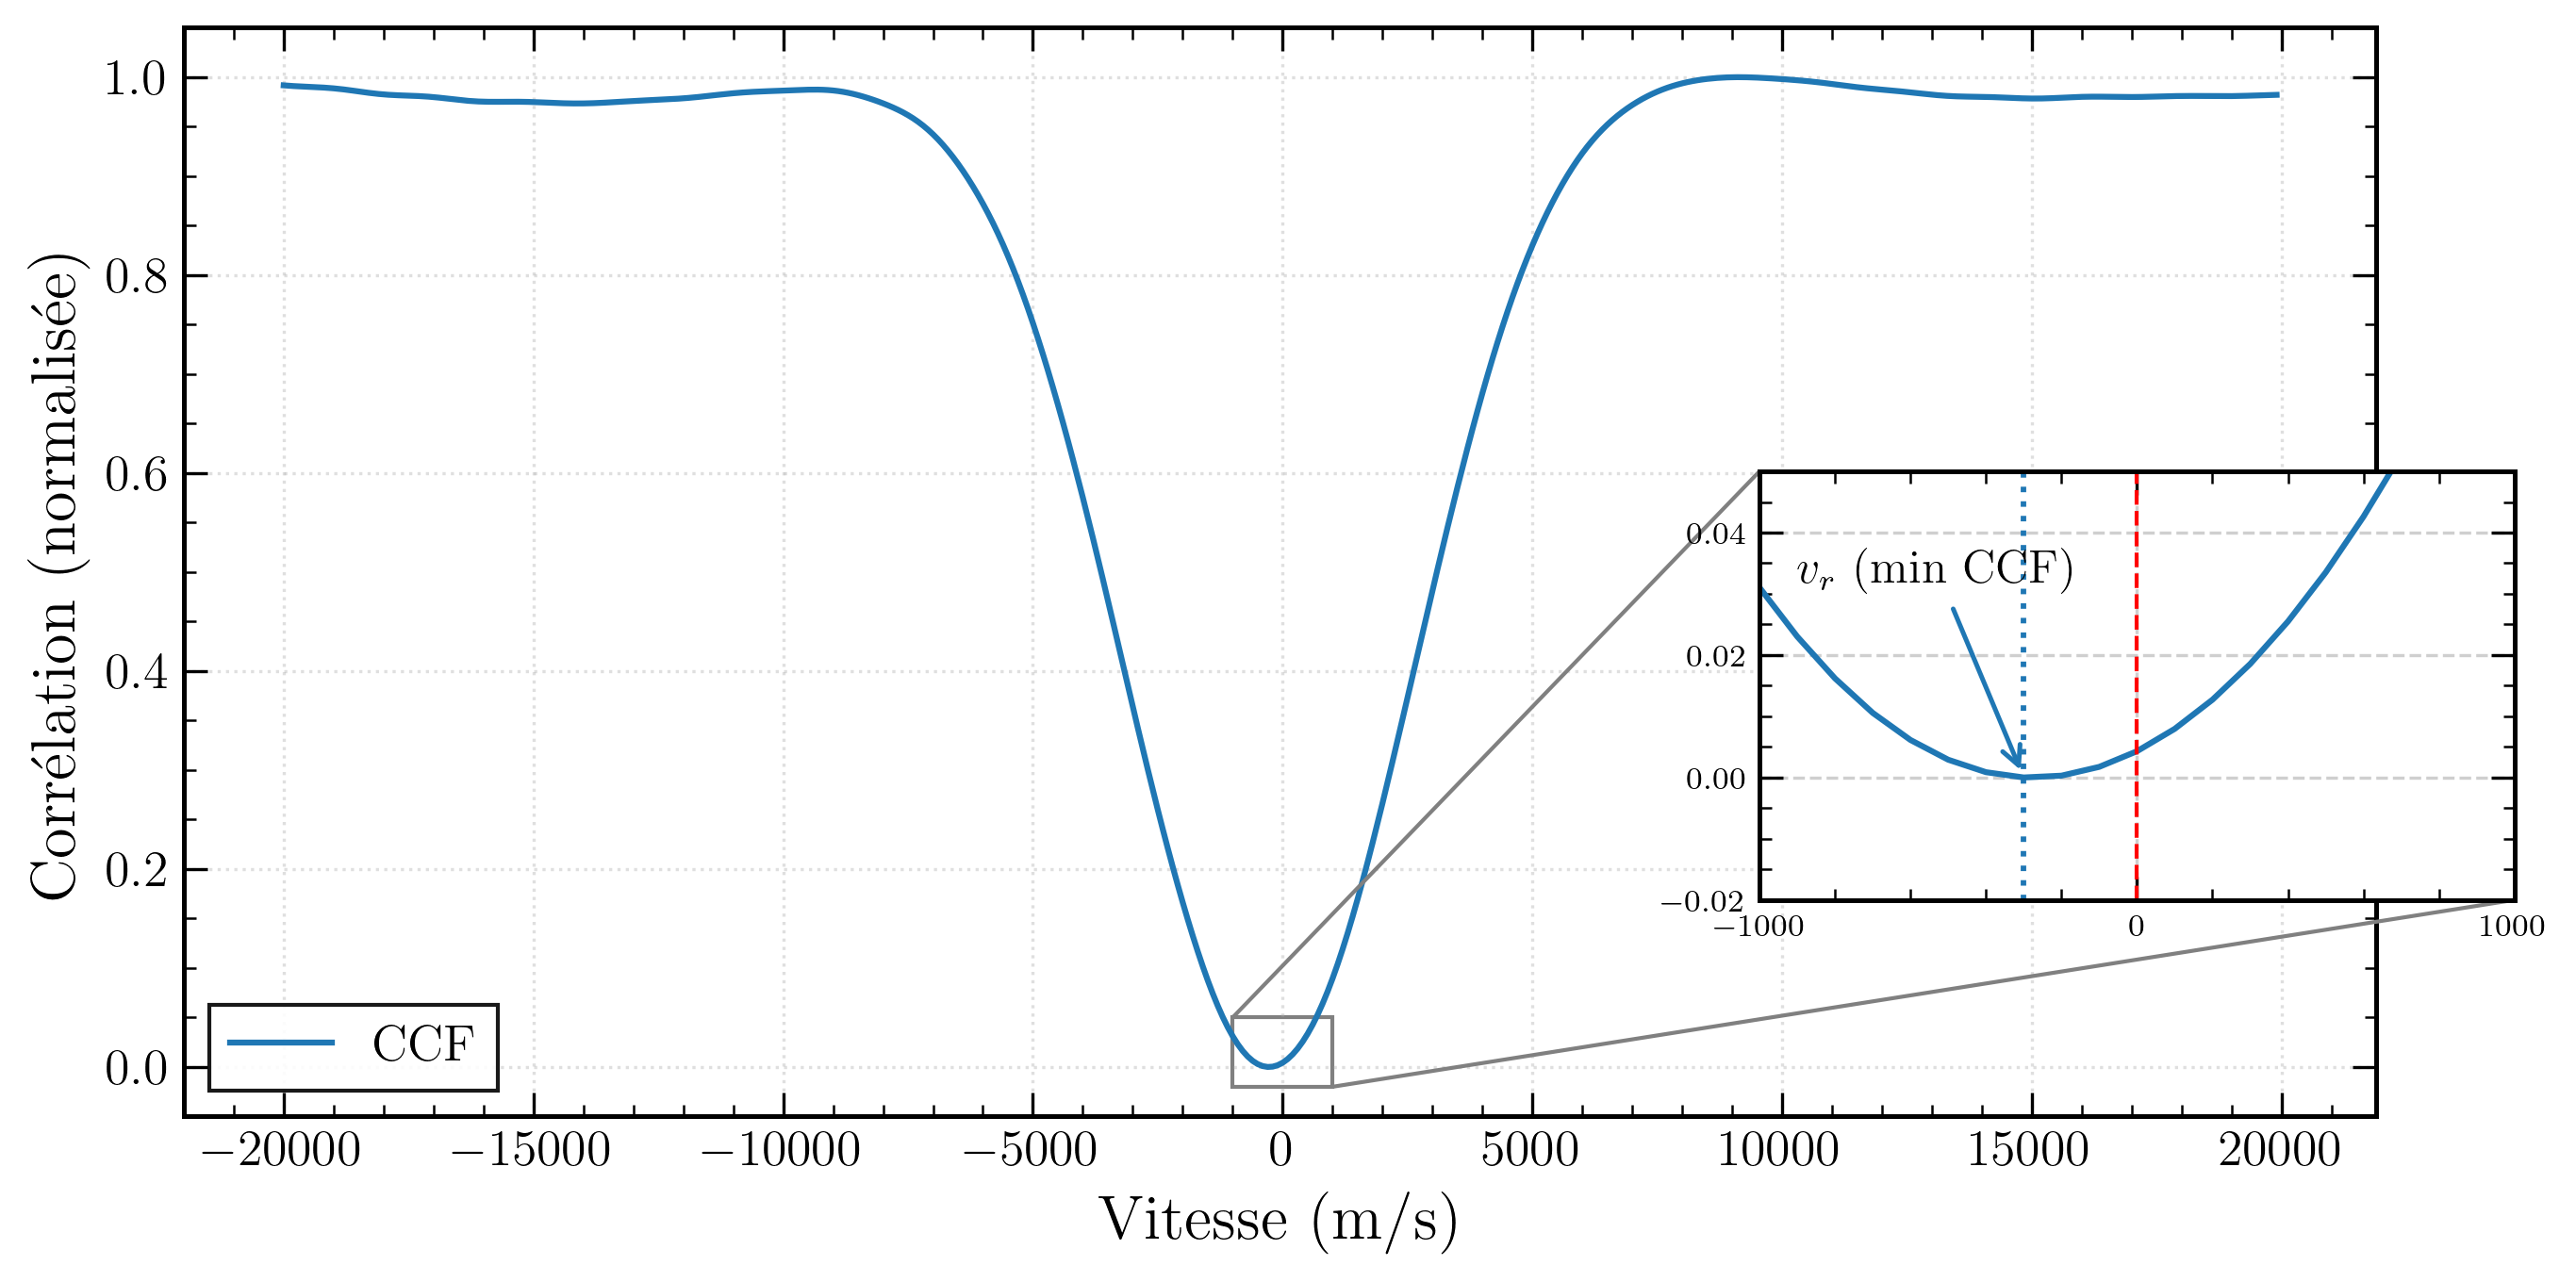

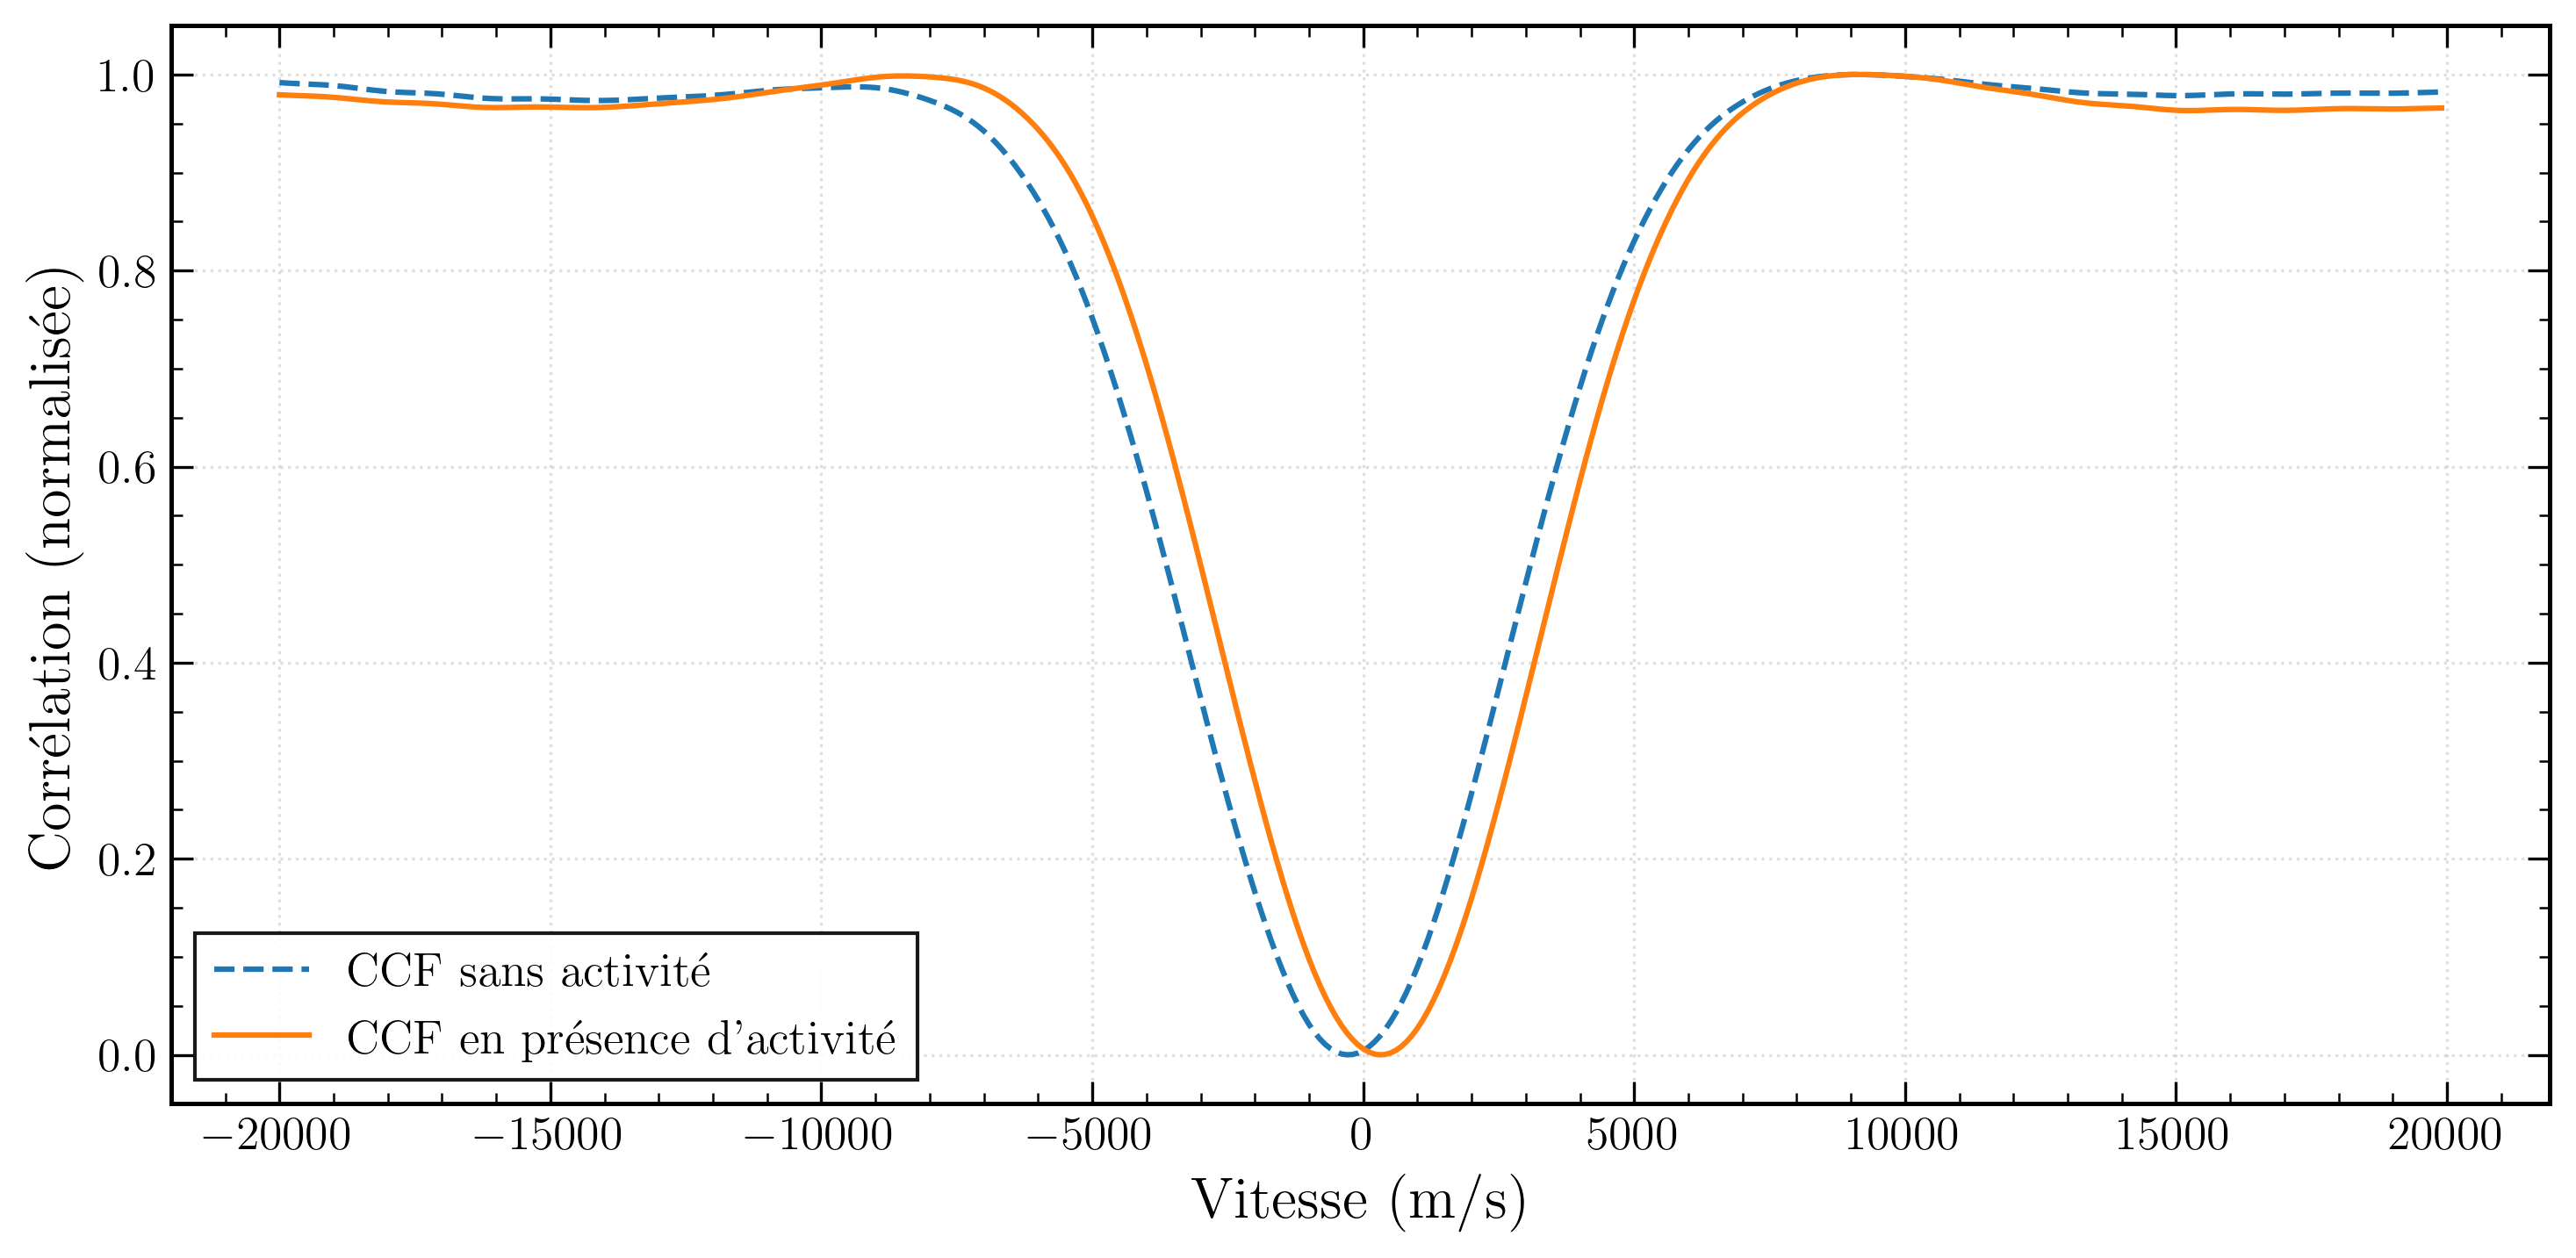

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# -----------------------------
# Préparation des données
# -----------------------------
v_grid = np.arange(-20000, 20000, 100)

tmp = dset_soap_ccf_activity["template"][None, :]
tmp_activity = (
    dset_soap_ccf_activity["activity"][0] * 100 + dset_soap_ccf_activity["template"]
)
tmp_activity = tmp_activity[None, :]

ccf = compute_CCFs(
    spectra=tmp,
    wavegrid=dset_soap_ccf_activity["wavegrid"],
    v_grid=v_grid,
    window_size_velocity=820,
)[0]

ccf_activity = compute_CCFs(
    spectra=tmp_activity,
    wavegrid=dset_soap_ccf_activity["wavegrid"],
    v_grid=v_grid,
    window_size_velocity=820,
)[0]

# -----------------------------
# Figure 1 : CCF + inset
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

# Courbe principale
ax.plot(v_grid, ccf, label="CCF")
ax.set_xlabel("Vitesse (m/s)")
ax.set_ylabel("Corrélation (normalisée)")
ax.grid(True, alpha=0.4)
ax.legend()

# Vitesse correspondant au minimum de la CCF
v_min_idx = np.argmin(ccf)
v_r = v_grid[v_min_idx]
ccf_min = ccf[v_min_idx]

# --- Sous-fenêtre (inset) agrandie ---
#   -> on augmente légèrement la surface du zoom
axins = inset_axes(
    ax,
    width="82%",  # plus grand qu'avant
    height="82%",  # plus grand qu'avant
    bbox_to_anchor=(0.70, 0.15, 0.42, 0.48),  # (x0, y0, width, height) en coords d'ax
    bbox_transform=ax.transAxes,
    loc="upper left",
    borderpad=0.8,
)

# Courbe dans l'inset
axins.plot(v_grid, ccf, label="CCF (zoom)")

# Zoom sur la zone du minimum
x1, x2 = -1000, 1000
y1, y2 = ccf_min - 0.02, ccf_min + 0.05
axins.set_xlim(x1, x2)
axins.set_ylim(y1, y2)

# Grille + lignes verticales (v=0 et v_r)
axins.grid(True, linestyle="--", alpha=0.6)
axins.axvline(0, color="red", linestyle="--", linewidth=1, label="v = 0")
min_line = axins.axvline(v_r, color="C0", linestyle=":", linewidth=1.4, label="min CCF")

# Annotation propre avec flèche sur le minimum
axins.annotate(
    r"$v_r$ (min CCF)",
    xy=(v_r, ccf_min),  # point à annoter
    xytext=(v_r - 600, ccf_min + 0.03),  # position du texte
    textcoords="data",
    arrowprops=dict(arrowstyle="->", lw=1.2, color="C0"),
    ha="left",
    va="bottom",
    fontsize=12,
)

# Ticks de l'inset
axins.set_xticks([-1000, 0, 1000])
axins.tick_params(labelsize=8)

# Légende de l'inset (labels visibles)

# Cadre reliant zone zoomée
mark_inset(ax, axins, loc1=2, loc2=4, fc="none", ec="0.5")

plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/ccf_example.png",
    dpi=300,
)
plt.show()

# -----------------------------
# Figure 2 : CCF vs CCF activité
# -----------------------------
plt.figure(figsize=(10, 5))
plt.plot(v_grid, ccf, label="CCF sans activité", linestyle="--")
plt.plot(v_grid, ccf_activity, label="CCF en présence d'activité")
plt.xlabel("Vitesse (m/s)")
plt.ylabel("Corrélation (normalisée)")
plt.grid(True, alpha=0.4)
plt.legend()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/ccf_acti.png",
    dpi=300,
)
plt.show()


In [ ]:
res = get_full_ccf_analysis(
    spectra=dset_soap_ccf_activity_planet["spectra"],
    wavegrid=dset_soap_ccf_activity_planet["wavegrid"],
    v_grid=np.arange(-20000, 20000, 250),
    window_size_velocity=820,
)

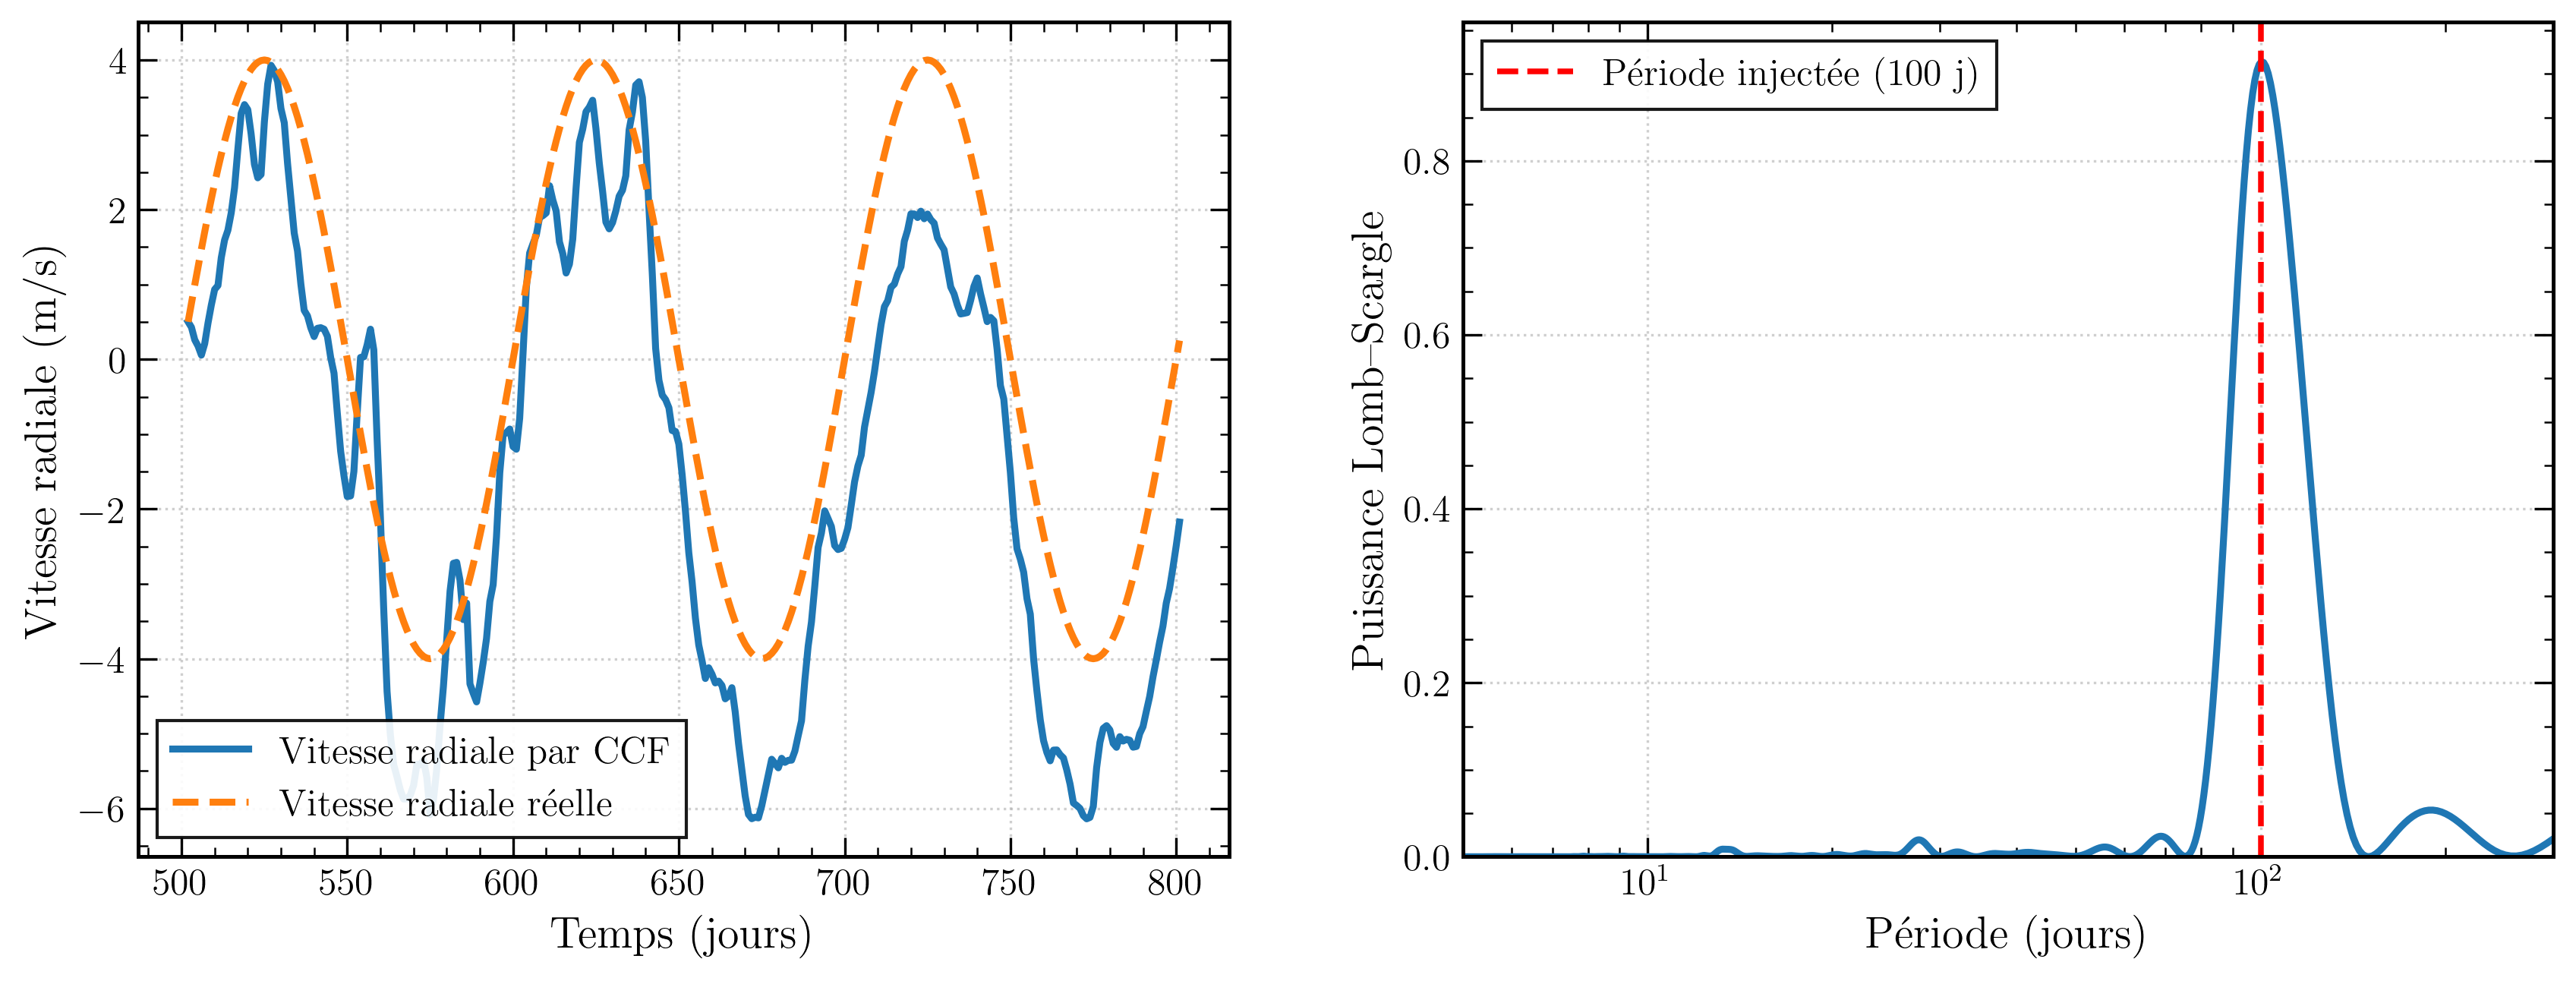

In [ ]:
# =========================
# PLOT CONDENSÉ (2 PANNEAUX)
# =========================
import numpy as np
import matplotlib.pyplot as plt
from astropy.timeseries import LombScargle

# ---- style local ----
plot_style = {
    "font.size": 13,
    "axes.titlesize": 14,
    "axes.labelsize": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.top": True,
    "ytick.right": True,
    "xtick.minor.visible": True,
    "ytick.minor.visible": True,
    "xtick.major.size": 6,
    "ytick.major.size": 6,
    "xtick.minor.size": 3,
    "ytick.minor.size": 3,
    "legend.frameon": True,
    "legend.facecolor": "white",
    "legend.edgecolor": "black",
    "legend.framealpha": 0.9,
    "legend.fancybox": False,
    "figure.dpi": 300,
    "savefig.bbox": "tight",
    "savefig.dpi": 300,
    "savefig.format": "pdf",
    "axes.grid": False,
}

# --------- Données ---------
time = dset_soap_ccf_activity_planet["time_values"]
rv_ccf = res["rv"]
rv_true = dset_soap_ccf_activity_planet["v_true"]
rv_ccf_centered = rv_ccf - np.mean(rv_ccf)

# --------- Lomb–Scargle ---------
min_period, max_period = 2, 500
frequency = np.linspace(1 / max_period, 1 / min_period, 6000)
ls = LombScargle(time, rv_ccf_centered)
power = ls.power(frequency)
periods = 1 / frequency

# =========================
# Figure combinée
# =========================
with plt.rc_context(plot_style):
    fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.5))

    # --- (a) Série temporelle RV ---
    ax = axes[0]
    ax.plot(
        time, rv_ccf - rv_ccf[0] + rv_true[0], label="Vitesse radiale par CCF", lw=2.2
    )
    ax.plot(time, rv_true, "--", label="Vitesse radiale réelle", lw=2.2)
    ax.set_xlabel("Temps (jours)")
    ax.set_ylabel("Vitesse radiale (m/s)")
    ax.legend(loc="best")
    ax.grid(True, ls=":", alpha=0.6)

    # --- (b) Périodogramme LS ---
    ax = axes[1]
    ax.plot(periods, power, lw=2.2)
    ax.axvline(100, color="r", ls="--", lw=1.8, label="Période injectée (100 j)")
    ax.set_xscale("log")
    ax.set_xlim(5, 300)
    ax.set_ylim(bottom=0)
    ax.set_xlabel("Période (jours)")
    ax.set_ylabel("Puissance Lomb–Scargle")
    ax.legend(loc="upper left")
    ax.grid(True, ls=":", alpha=0.6)

    # --- Ajustement global ---
    plt.tight_layout(w_pad=3.0)
    plt.savefig(
        "./plots_rapport/contexte_scientifique/rv_plus_periodogram_combined.png",
        bbox_inches="tight",
    )
    plt.show()

/tmp/ipykernel_295099/2427374879.py:3: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(filepath, delim_whitespace=True, comment="#")


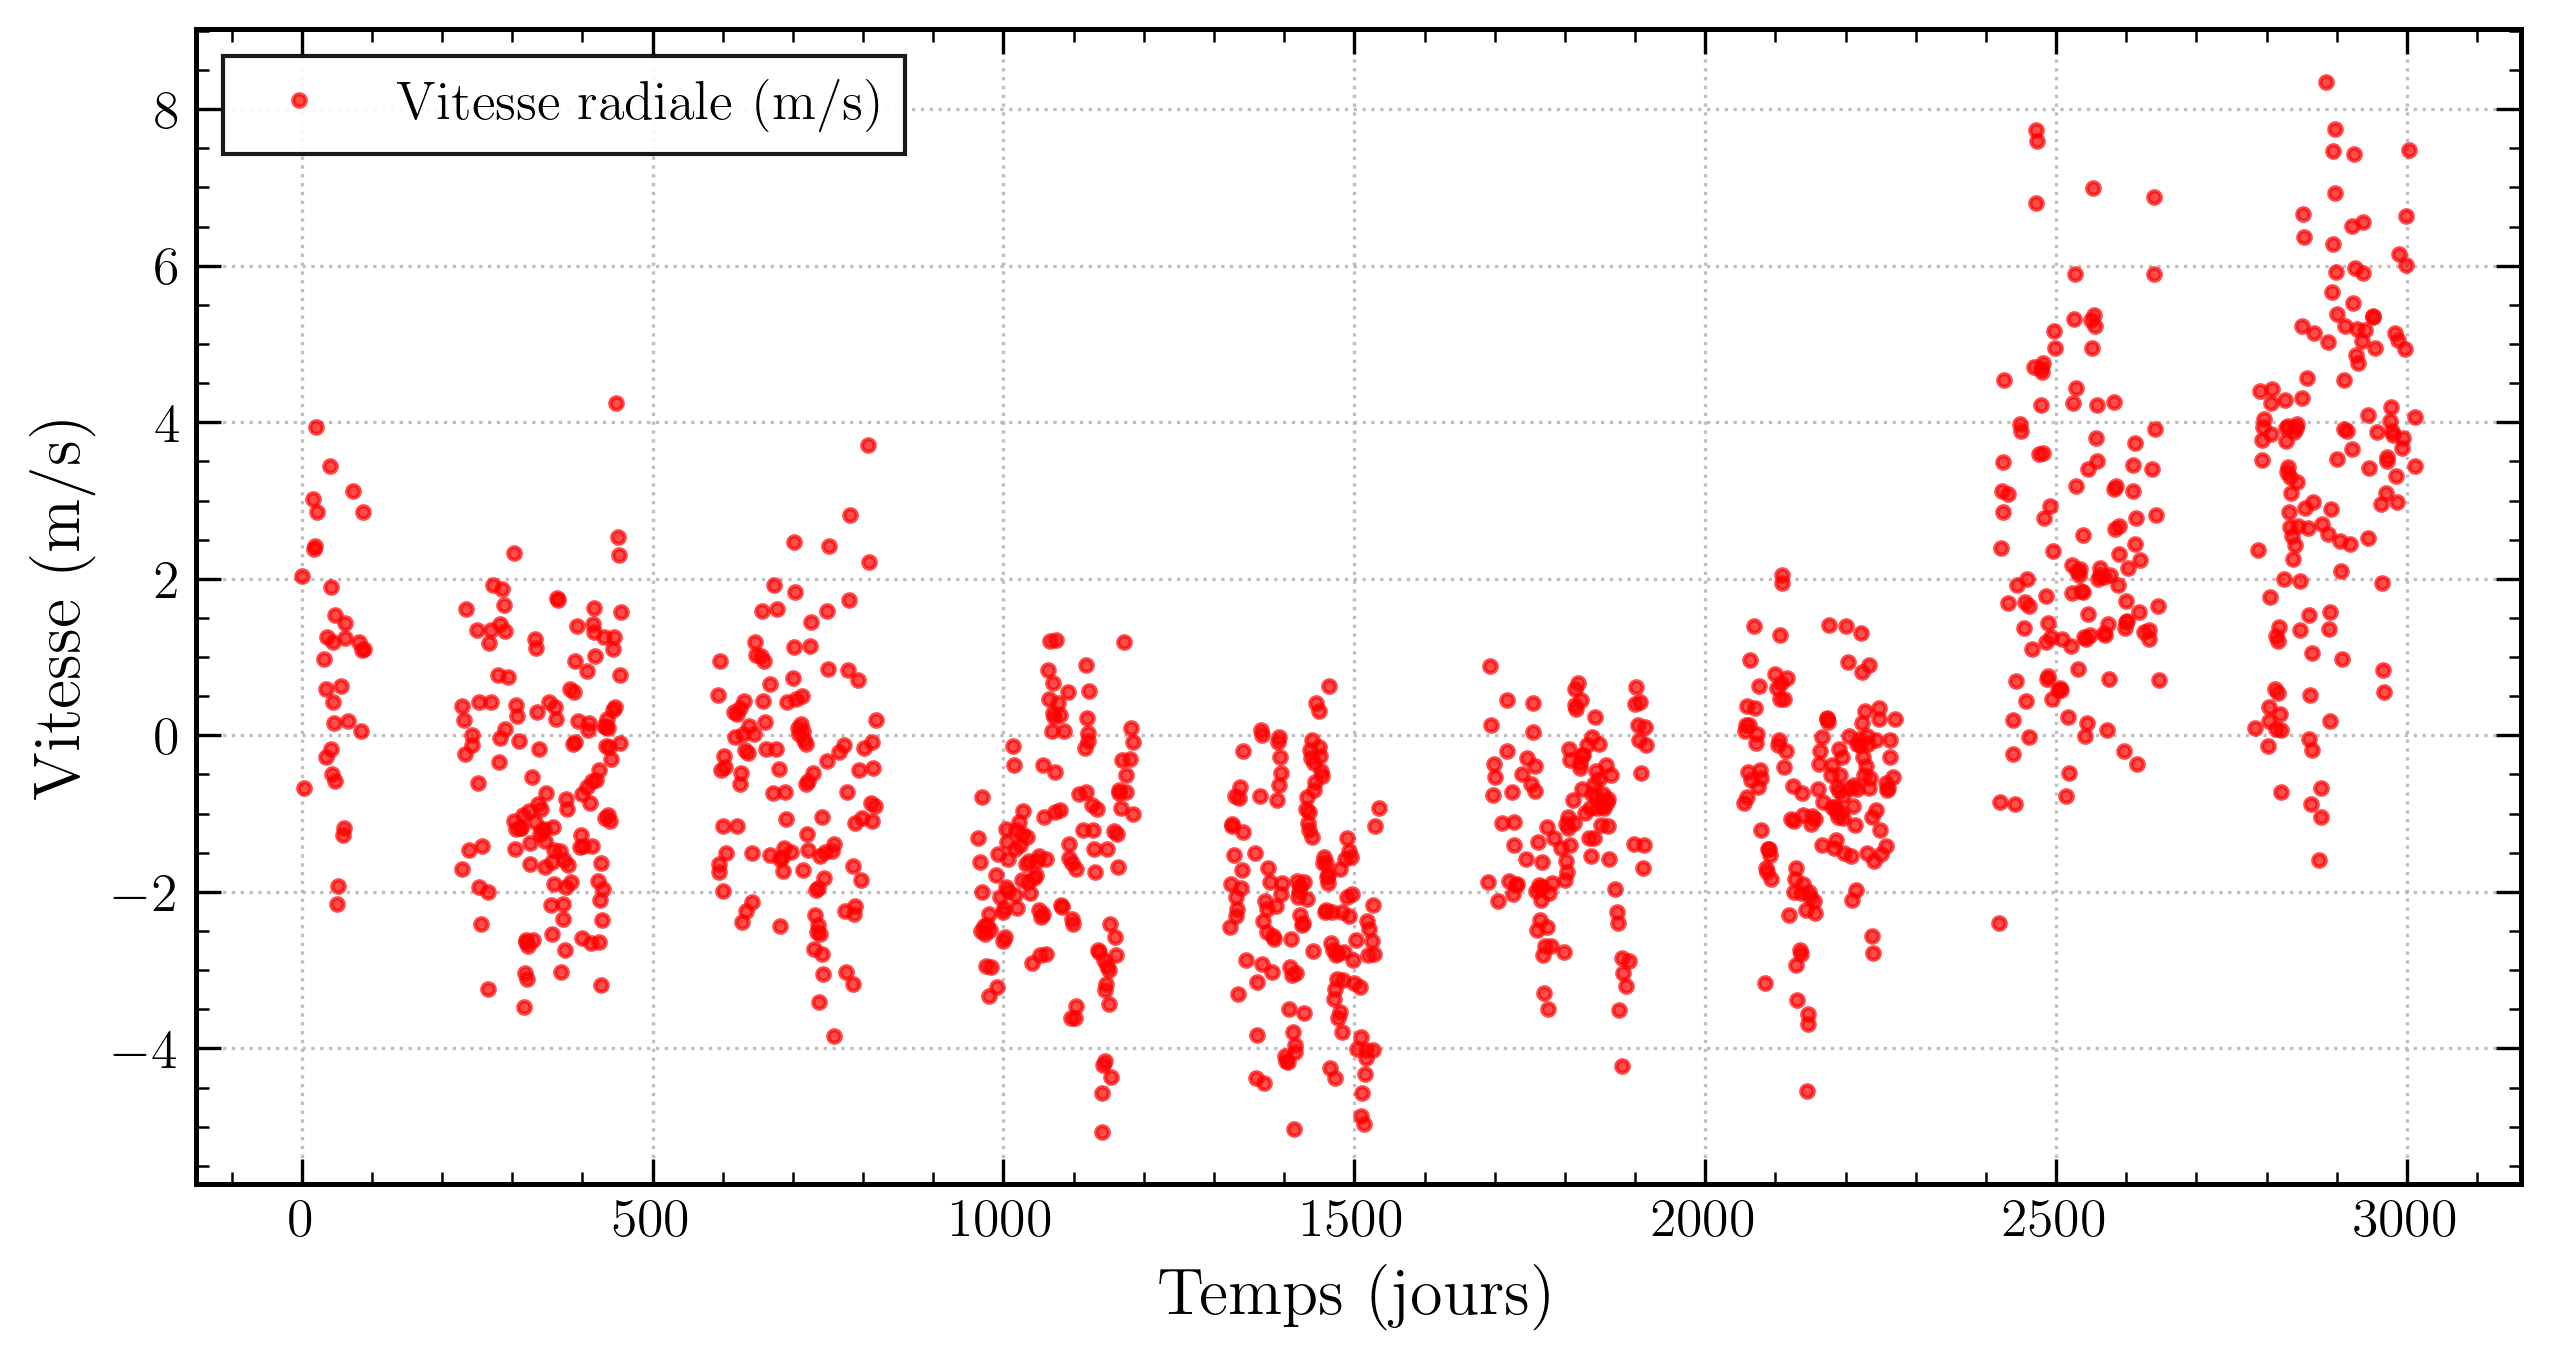

In [ ]:
filepath="/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57001_E61001_planet-FallChallenge1/STAR1136_DACE_YVA.rdb"
# --- Charger YV0 et YVA ---
df_yva = pd.read_csv(filepath, delim_whitespace=True, comment="#")

df_yva = df_yva.iloc[1:]  # enlever la premiere ligne

df_yva = df_yva.iloc[:, :-1]  # enlever la derniere colonne

df_yva = df_yva.astype({"vrad": "float32", "svrad": "float32", "jdb": "float32"})

rvA = (df_yva["vrad"] - df_yva["vrad"].mean()) * 1000
timeA = df_yva["jdb"] - df_yva["jdb"].iloc[0]

mask = rvA <= 40
rvA = rvA[mask]
timeA = timeA[mask]

# --- Tracer ---
plt.figure(figsize=(10, 5))
plt.errorbar(
    timeA,
    rvA,
    fmt="o",
    ms=3,
    color="red",
    alpha=0.7,
    label="Vitesse radiale (m/s)",
)

plt.xlabel("Temps (jours)")
plt.ylabel("Vitesse (m/s)")
plt.grid(alpha=0.8)
plt.legend()
plt.savefig("./plots_rapport/contexte_scientifique/rv_timeseries_example_irregular.png")
plt.show()


In [ ]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint(
    "../experiments/aestra_baseline/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/soapgpu_ns1275_5000-5050_harps-noise-1_p100_k0p3_phi0.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]

[00:20:43] 📂 Loading experiment checkpoint: ../experiments/aestra_baseline/models/aestra_final.pth    ]8;id=652754;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=336451;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#193\193]8;;\

RuntimeError: Error(s) in loading state_dict for AESTRA:
	size mismatch for b_obs: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for b_rest: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for spender.decoder.mlp.9.weight: copying a param with shape torch.Size([1001, 1024]) from checkpoint, the shape in current model is torch.Size([5001, 1024]).
	size mismatch for spender.decoder.mlp.9.bias: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for spender.decoder.mlp.10.weight: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for rvestimator.mlp.mlp.0.weight: copying a param with shape torch.Size([128, 1280]) from checkpoint, the shape in current model is torch.Size([128, 640

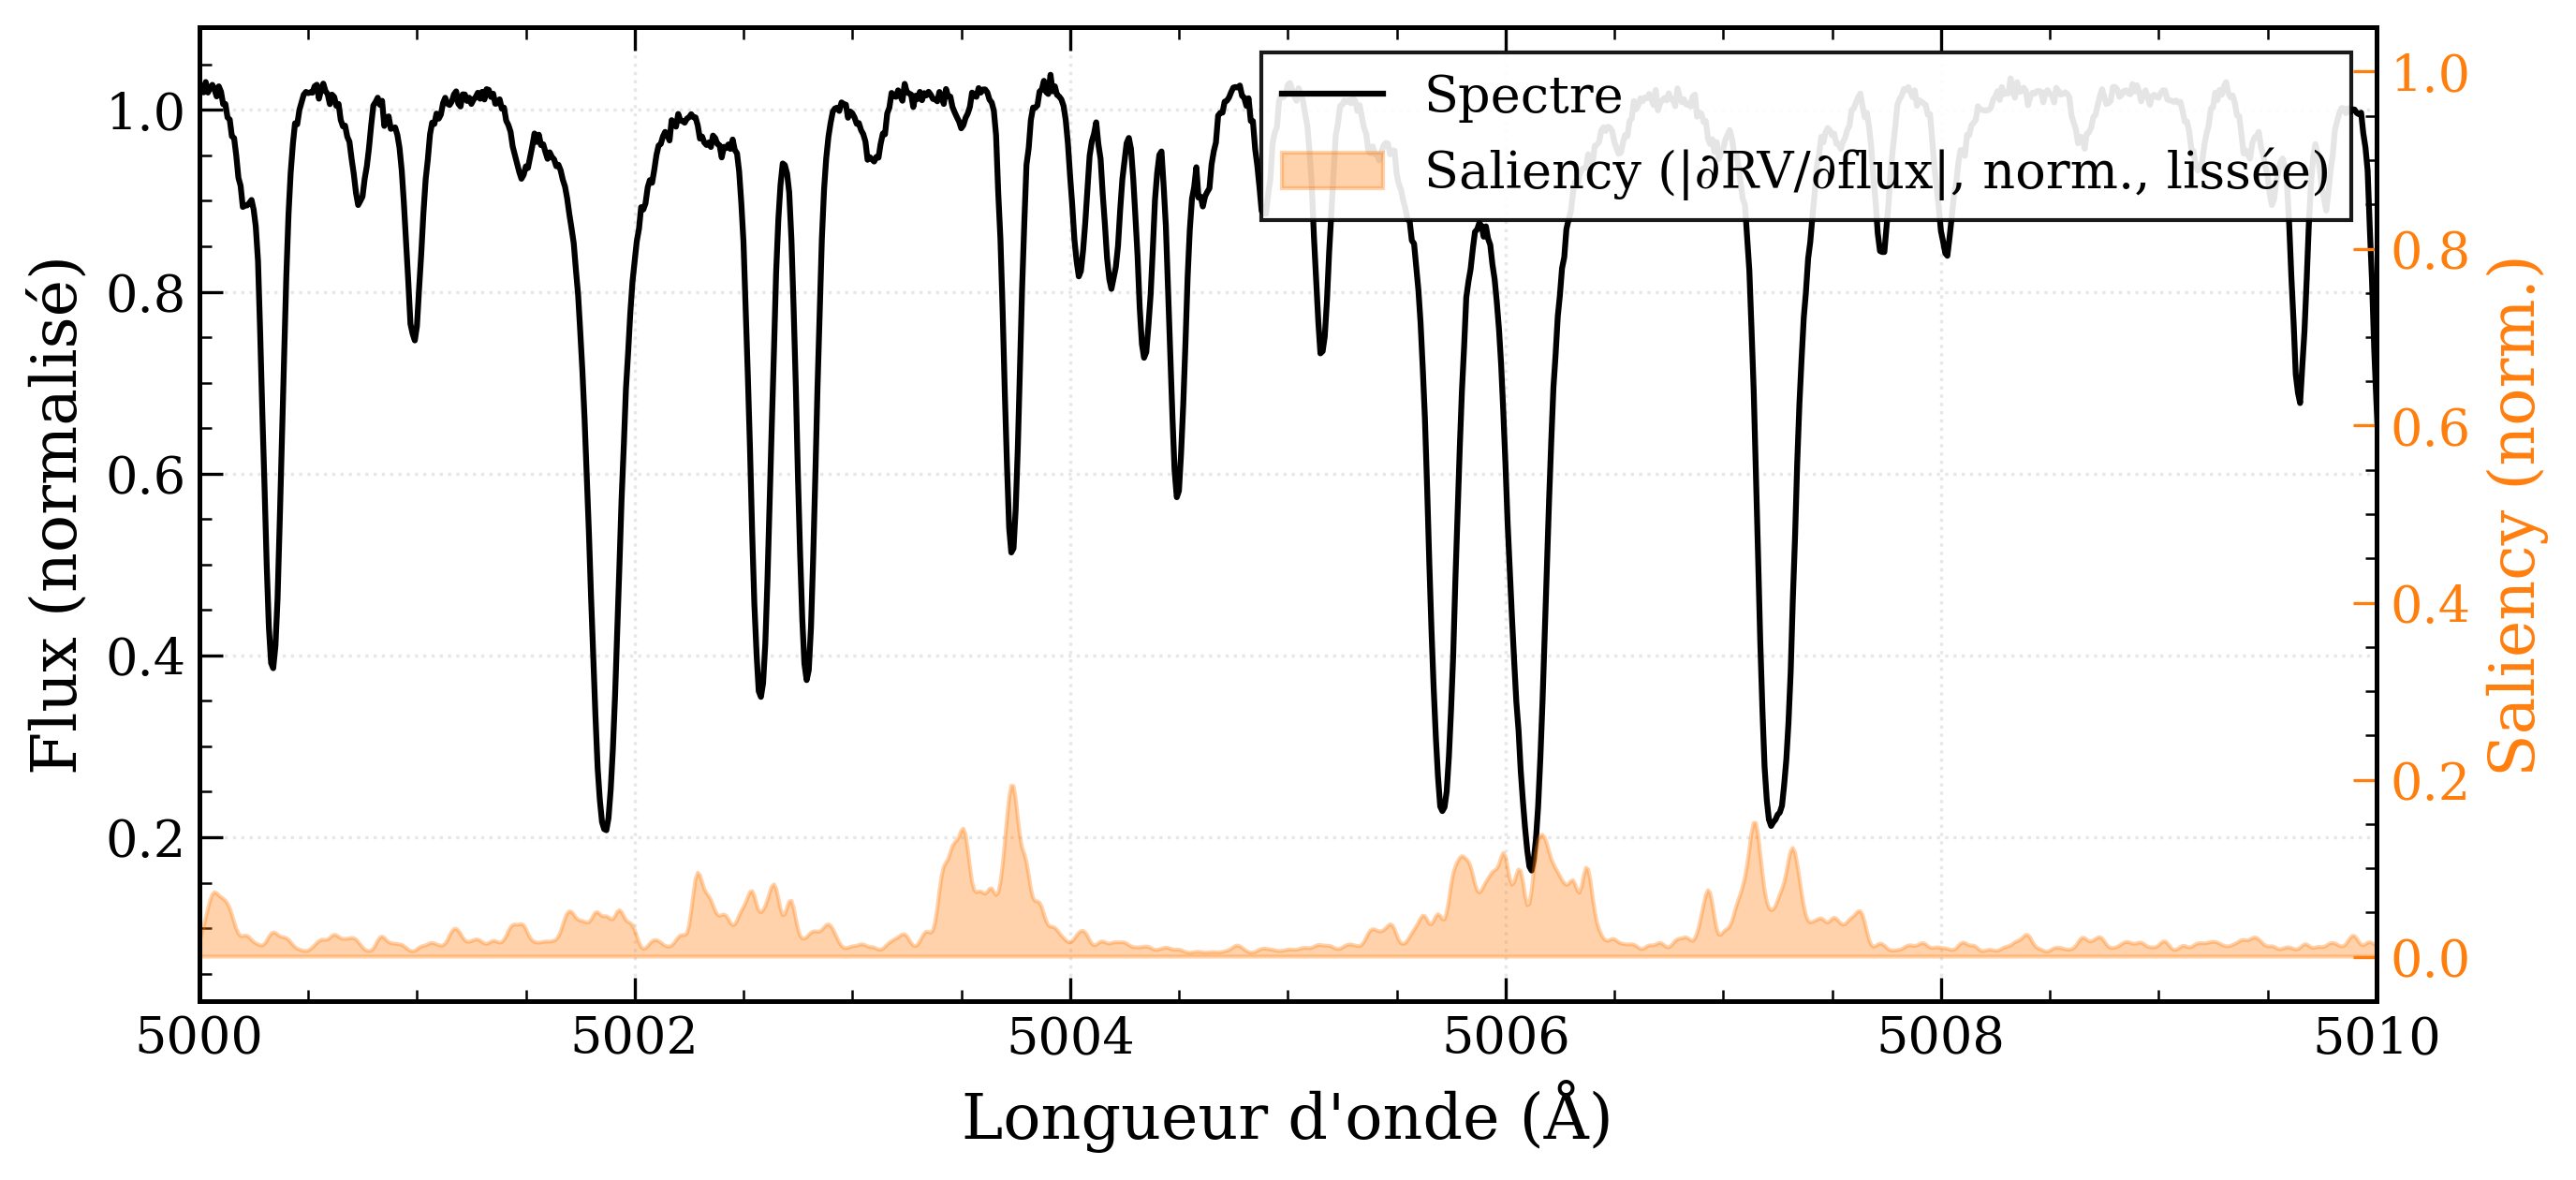

In [ ]:
from src.dataset import generate_collate_fn
from torch.utils.data import DataLoader
import torch
import numpy as np
import matplotlib.pyplot as plt
import os

# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

# Récupérer un batch et un spectre quelconque
batch = next(iter(dataloader))
batch_yobs, batch_yaug, batch_voffset_true, batch_wavegrid, *_ = batch
batch_yobs = batch_yobs.to(device)
batch_wavegrid = batch_wavegrid.to(device)

idx = 0  # on prend le premier spectre du batch
y = batch_yobs[idx:idx+1].detach().clone().requires_grad_(True)  # [1, P]
wave = batch_wavegrid[idx].detach().cpu().numpy()

# Passage par la tête RV (rvestimator) et estimation RV
ckpt_model.zero_grad()
robs = y - ckpt_model.b_obs.unsqueeze(0).to(y.device)  # x d'entrée de la tête RV
v_pred = ckpt_model.rvestimator(robs)  # [1]
rv_value = float(v_pred.detach().cpu().numpy()[0])

# Saliency: |d(RV)/d(flux)| par pixel
v_pred.sum().backward()
saliency = y.grad.detach().cpu().numpy()[0]
saliency = np.abs(saliency)

# --- Lissage léger de la saliency (Gaussien) ---
# sigma en pixels (ajuste si nécessaire)
sigma_pix = 2.0
if sigma_pix is not None and sigma_pix > 0:
    win = int(max(3, int(8 * sigma_pix) + 1))
    x = np.arange(win) - (win - 1) / 2.0
    kern = np.exp(-(x ** 2) / (2.0 * sigma_pix ** 2))
    kern = kern / np.sum(kern)
    saliency = np.convolve(saliency, kern, mode="same")

# Renormaliser pour affichage
if np.max(saliency) > 0:
    saliency = saliency / np.max(saliency)

spectrum = y.detach().cpu().numpy()[0]

# Tracé: spectre + saliency (normalisée) sur la même figure
# Désactiver temporairement LaTeX pour cette figure pour éviter les erreurs de rendu
with plt.rc_context({"text.usetex": False}):
    fig, ax1 = plt.subplots(figsize=(10, 4.5))
    ax1.plot(wave, spectrum, color="black", label="Spectre")
    ax1.set_xlabel("Longueur d'onde (Å)")
    ax1.set_ylabel("Flux (normalisé)")
    ax1.grid(True, alpha=0.3)

    ax2 = ax1.twinx()
    ax2.fill_between(
        wave,
        0,
        saliency,
        color="tab:orange",
        alpha=0.35,
        label="Saliency (|∂RV/∂flux|, norm., lissée)",
    )
    ax2.set_ylabel("Saliency (norm.)", color="tab:orange")
    ax2.tick_params(axis="y", colors="tab:orange")

    # Légende combinée
    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

    # ASCII-only title to be safe
    # ax1.set_title(f"RV estimee = {rv_value:.2f} m/s + saliency map (sigma={sigma_pix})")
    ax1.set_xlim(5000, 5010)

    # Sauvegarde optionnelle
    outdir = "./plots_rapport/aestra"
    os.makedirs(outdir, exist_ok=True)
    plt.savefig("./plots_rapport/contexte_scientifique/spectrum_with_saliency.png", dpi=300)
    plt.show()

In [ ]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint(
    "../experiments/aestra_baseline/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/soapgpu_ns1275_5000-5050_harps-noise-1_p100_k0p3_phi0.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]


# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

all_s = []
all_vencode = []

for batch in dataloader:
    batch_yobs = batch[0].to('cpu')  # [B, P]

    batch_vencode = ckpt_model.rvestimator(batch_yobs - ckpt_model.b_rest)

    batch_yact, batch_s = ckpt_model.spender(batch_yobs - ckpt_model.b_rest)

    all_s.append(batch_s.detach().cpu().numpy())
    all_vencode.append(batch_vencode.detach().cpu().numpy())

all_s = np.concatenate(all_s, axis=0) # taille [1000, 3] ici
all_vencode = np.concatenate(all_vencode, axis=0) # taille [1000] ici

[00:21:42] 📂 Loading experiment checkpoint: ../experiments/aestra_baseline/models/aestra_final.pth    ]8;id=729176;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=959011;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#193\193]8;;\

RuntimeError: Error(s) in loading state_dict for AESTRA:
	size mismatch for b_obs: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for b_rest: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for spender.decoder.mlp.9.weight: copying a param with shape torch.Size([1001, 1024]) from checkpoint, the shape in current model is torch.Size([5001, 1024]).
	size mismatch for spender.decoder.mlp.9.bias: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for spender.decoder.mlp.10.weight: copying a param with shape torch.Size([1001]) from checkpoint, the shape in current model is torch.Size([5001]).
	size mismatch for rvestimator.mlp.mlp.0.weight: copying a param with shape torch.Size([128, 1280]) from checkpoint, the shape in current model is torch.Size([128, 640

# Méthodologie : fonctionnement d’AESTRA

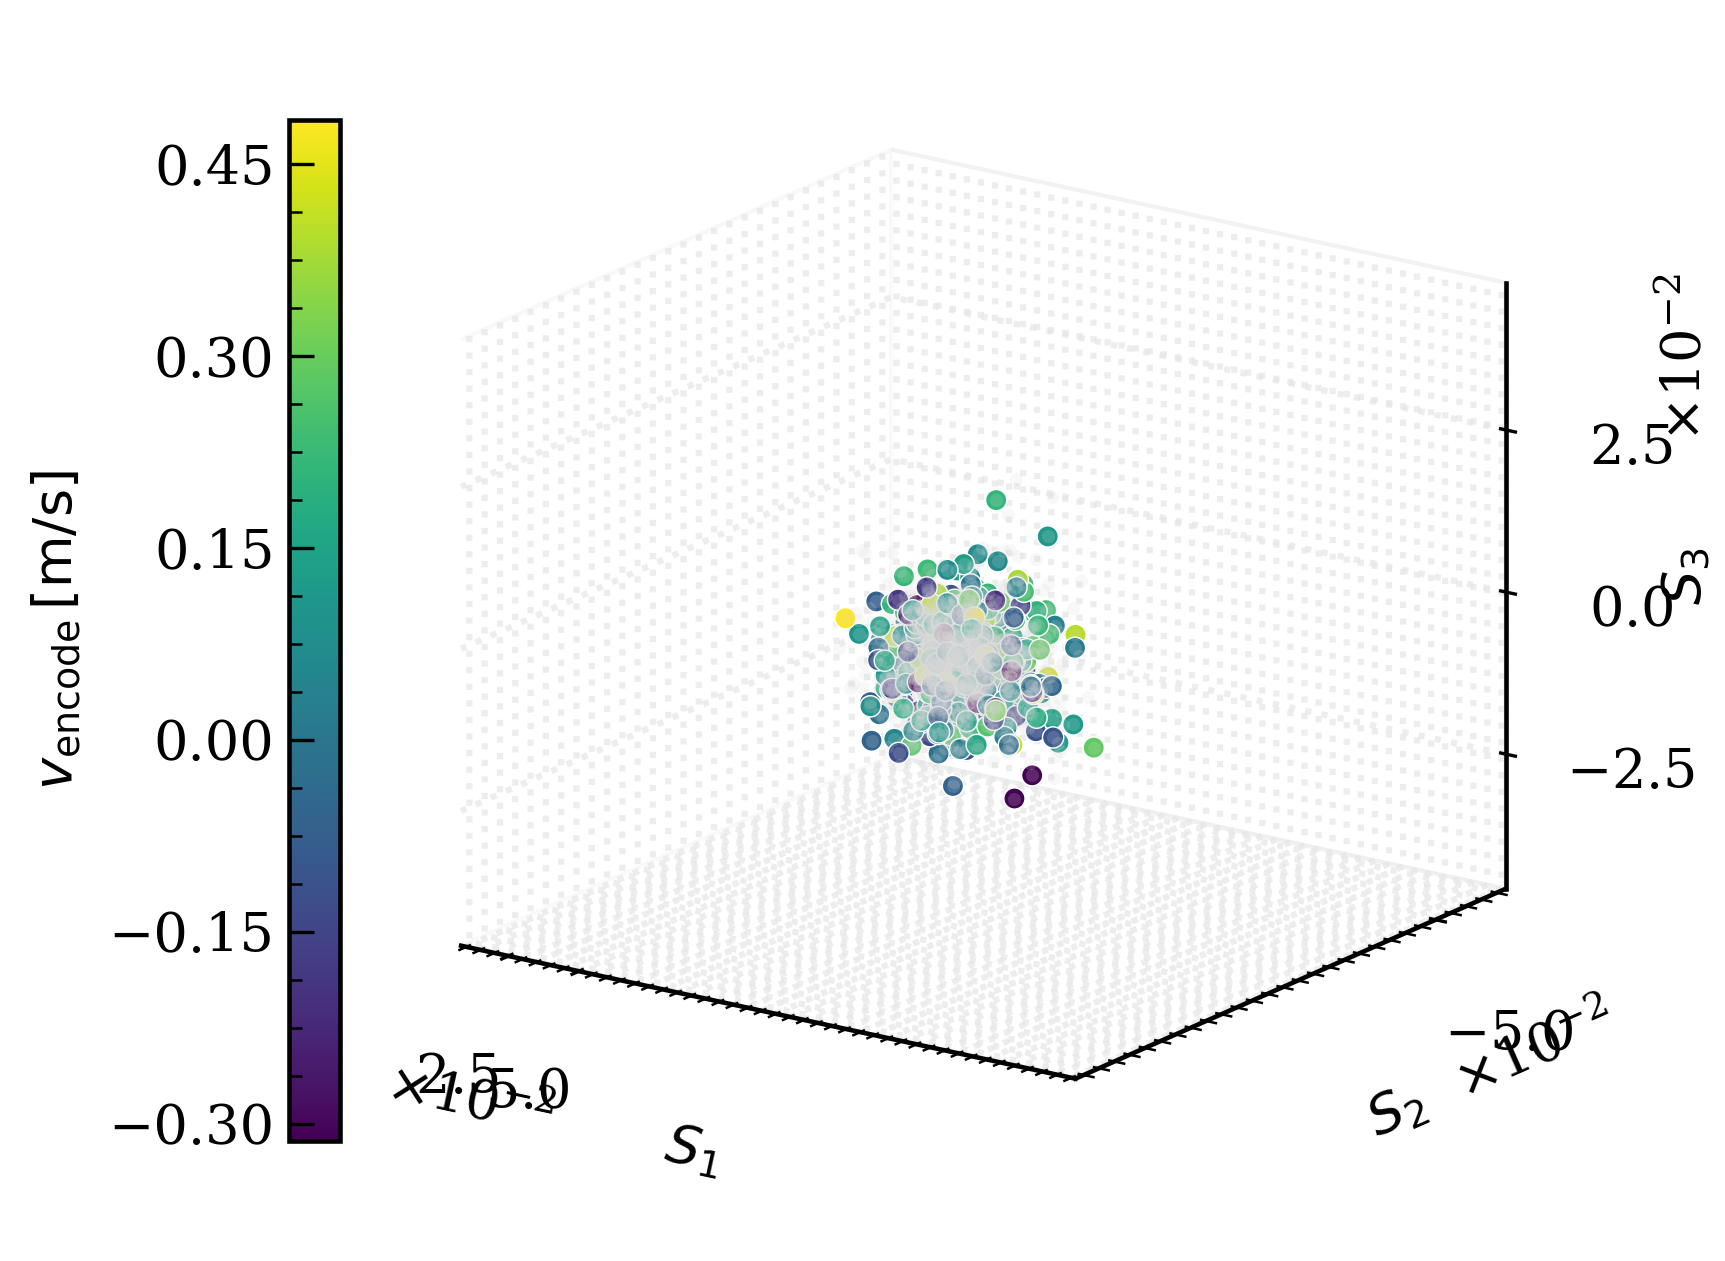

In [ ]:
# %%
# %matplotlib qt
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator, ScalarFormatter
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

S = np.asarray(all_s, dtype=float)
v = np.asarray(all_vencode, dtype=float).reshape(-1)

# Sous-échantillons (lisibilité)
rng = np.random.default_rng(42)
idx_col = rng.choice(S.shape[0], size=min(500, S.shape[0]), replace=False)
idx_bg = rng.choice(S.shape[0], size=min(1200, S.shape[0]), replace=False)

vmin, vmax = np.percentile(v, [2, 98])

rc = {
    "font.size": 11,
    "axes.labelsize": 13,
    "axes.titlesize": 14,
    "axes.linewidth": 1.1,
    "xtick.top": True,
    "ytick.right": True,
    "figure.figsize": (6.0, 5.2),  # + compact
    "axes.grid": True,
    # "text.usetex": True,
    # "font.family": "serif",
}

with plt.rc_context(rc):
    fig = plt.figure()
    fig.subplots_adjust(right=0.86)  # espace pour la colorbar verticale
    ax = fig.add_subplot(111, projection="3d")
    ax.set_proj_type("ortho")

    # Grille 3D légère
    ax.grid(alpha=1)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.pane.set_facecolor((1, 1, 1, 0))
        axis._axinfo["grid"]["color"] = (0.9, 0.9, 0.9, 0.7)
        axis._axinfo["grid"]["linewidth"] = 1.5

    # Nuage de fond
    ax.scatter(
        S[idx_bg, 0],
        S[idx_bg, 1],
        S[idx_bg, 2],
        s=10,
        c="0.85",
        alpha=0.18,
        depthshade=False,
        linewidths=0,
        zorder=1,
    )

    # Points colorés
    sc = ax.scatter(
        S[idx_col, 0],
        S[idx_col, 1],
        S[idx_col, 2],
        s=26,
        c=v[idx_col],
        vmin=vmin,
        vmax=vmax,
        alpha=1.0,
        depthshade=False,
        edgecolors="white",
        linewidths=0.35,
        zorder=10,
    )

    # Axes & ticks
    ax.set_xlabel(r"$S_1$", labelpad=5, fontweight="bold")
    ax.set_ylabel(r"$S_2$", labelpad=5, fontweight="bold")
    ax.set_zlabel(r"$S_3$", labelpad=5, fontweight="bold")
    ax.view_init(elev=18, azim=-55)
    try:
        ax.set_box_aspect((1, 1, 0.85))
    except Exception:
        pass

    loc = MaxNLocator(nbins=4)
    fmt = ScalarFormatter(useMathText=True)
    fmt.set_powerlimits((-2, 2))
    fmt.set_useOffset(True)
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_major_locator(loc)
        axis.set_major_formatter(fmt)
    ax.tick_params(
        axis="both", which="both", length=0, pad=10
    )  # pas de “traits” sur les axes

    # Colorbar VERTICALE compacte à droite
    cbar = fig.colorbar(
        sc, ax=ax, orientation="vertical", pad=0.02, fraction=0.06, shrink=0.85, location="left"
    )
    cbar.set_label(r"$v_{\mathrm{encode}}\,[\mathrm{m/s}]$", labelpad=6)
    cbar.locator = MaxNLocator(nbins=6)
    cbar.update_ticks()

    # Sauvegarde
    out_path = "./plots_rapport/contexte_scientifique/3d_latentspace.png"
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    plt.savefig(out_path, dpi=300, bbox_inches="tight")
    plt.show()

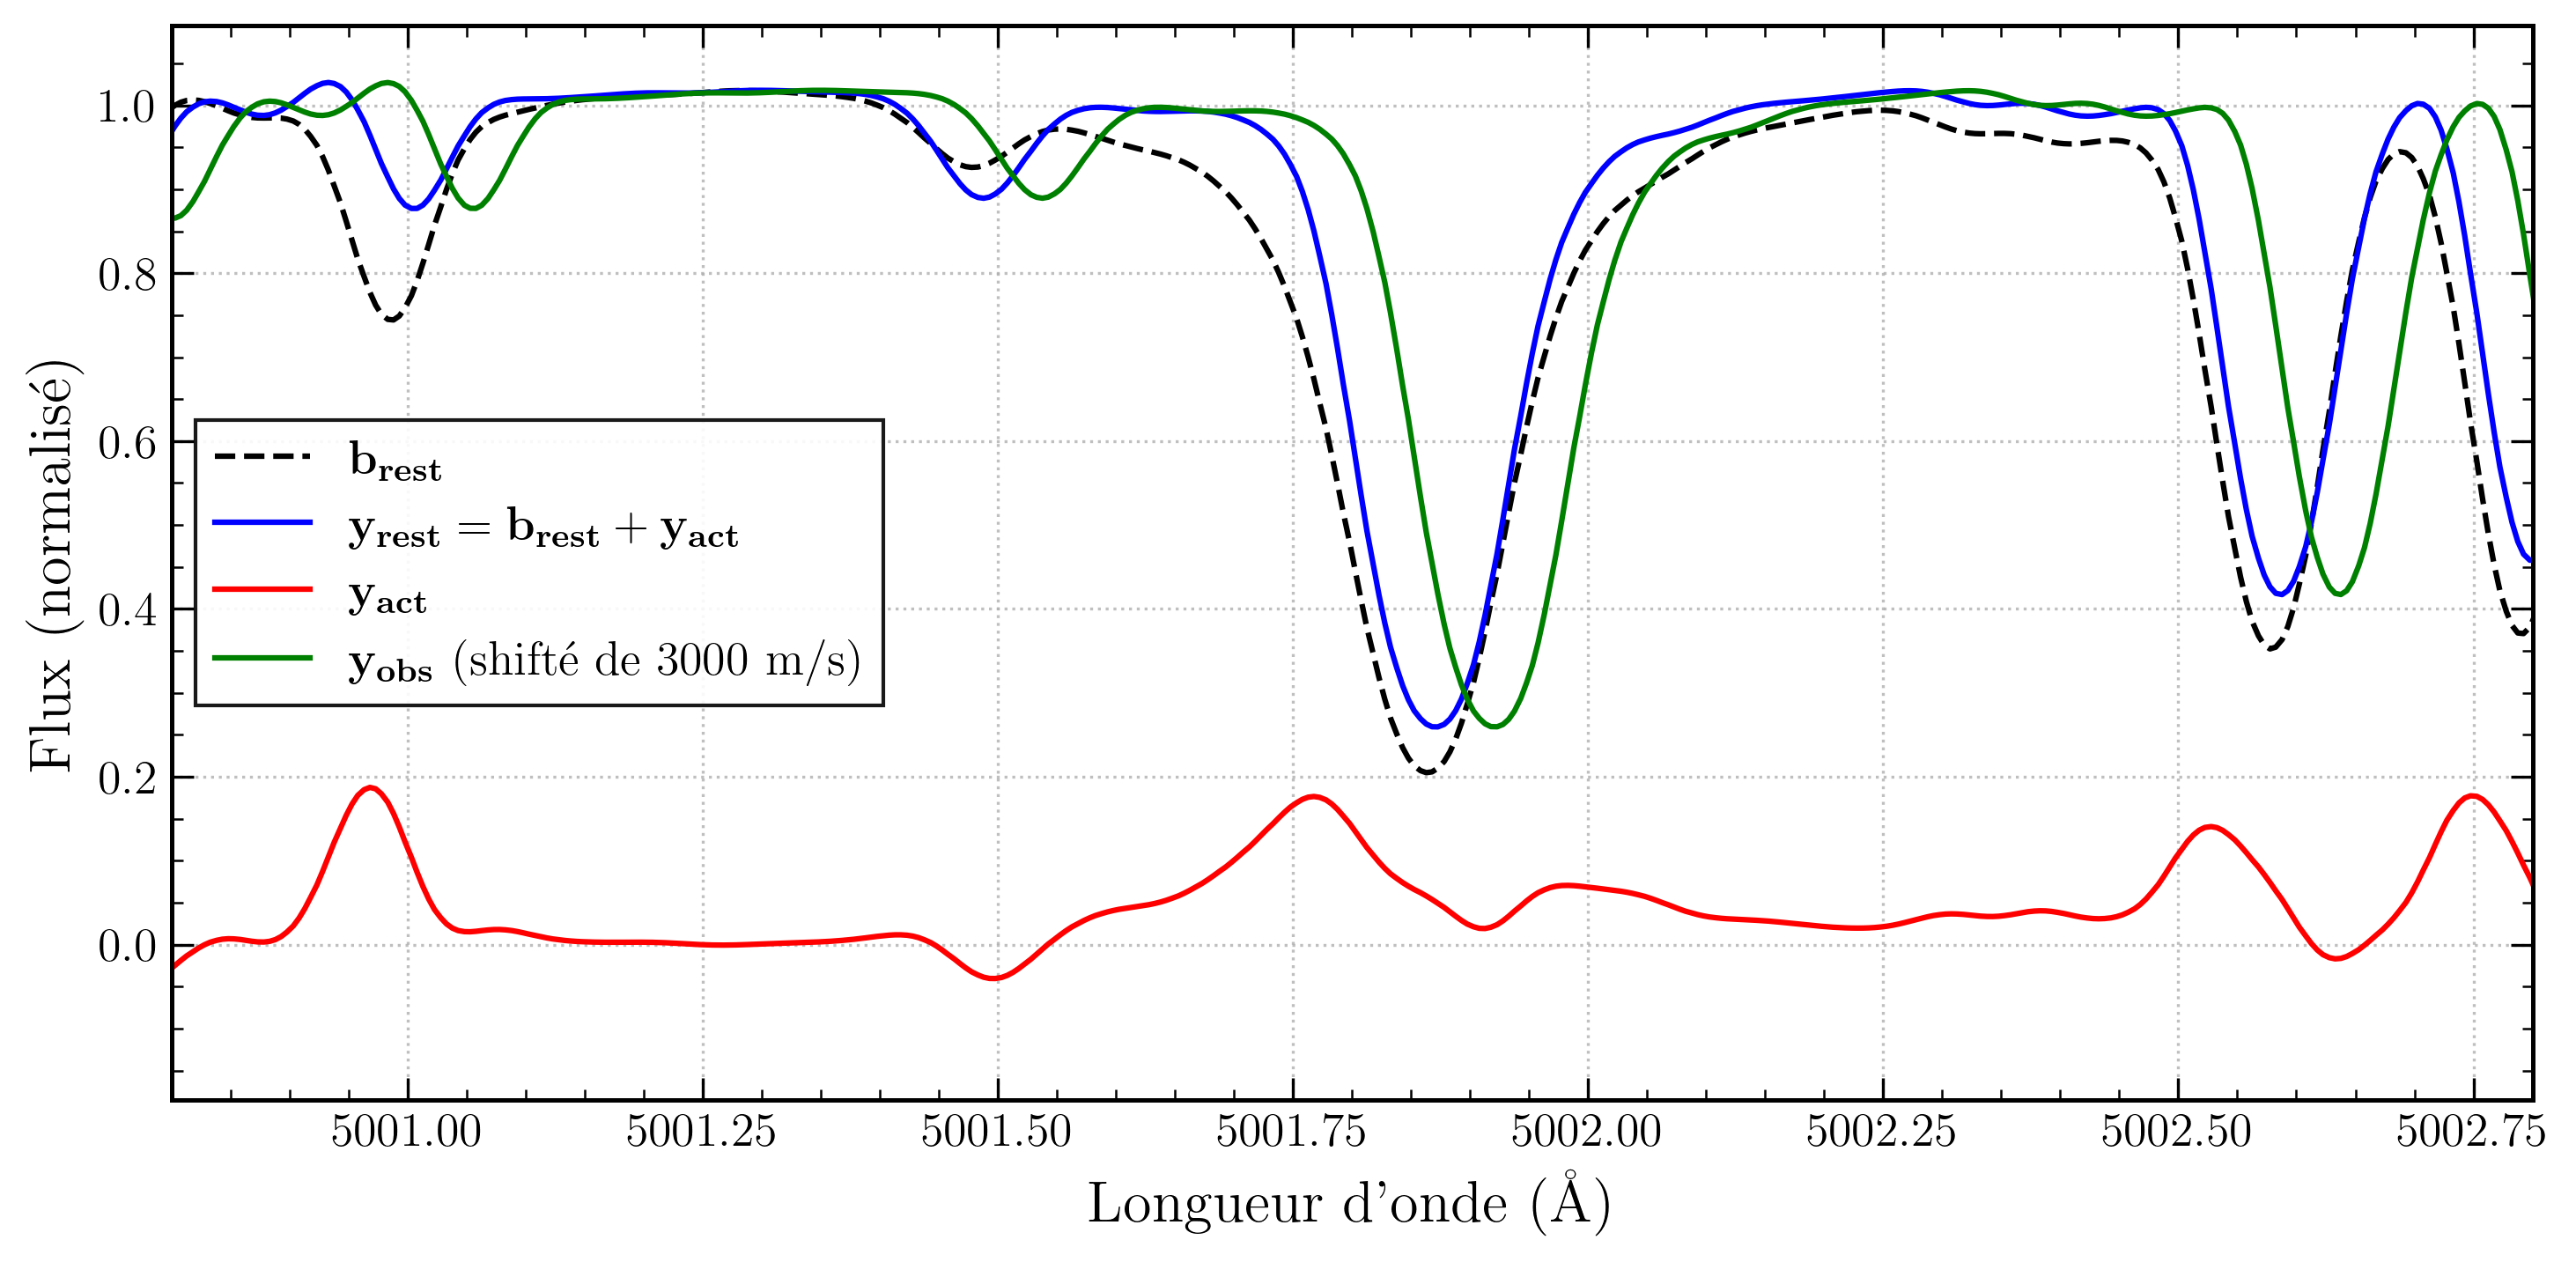

In [ ]:
b_rest = soap_template.copy()
wavegrid = soap_wavegrid.copy()
y_act = soap_activity[0, :] * 100
y_rest = b_rest + y_act
v = 3000

y_obs = shift_spectra_linear(
    spectra=torch.tensor(y_rest).unsqueeze(0),
    wavegrid=torch.tensor(wavegrid).unsqueeze(0),
    velocities=torch.tensor([v]).unsqueeze(0)
)


plt.figure(figsize=(10, 5))
plt.plot(wavegrid, b_rest, label="$\mathbf{b_{rest}}$", color="black", linestyle="--")
plt.plot(
    wavegrid,
    y_rest,
    label="$\mathbf{y_{rest}} = \mathbf{b_{rest}} + \mathbf{y_{act}}$",
    color="blue",
)
plt.plot(
    wavegrid, y_act, label="$\mathbf{y_{act}}$", color="red"
)
plt.plot(
    wavegrid,
    y_obs.squeeze(0).numpy(),
    label="$\mathbf{y_{obs}}$ (shifté de" + f" {v} m/s)",
    color="green",
)
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.8 - 1, 5001.8 + 1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/yobs_brest_yact_effect.png",
    dpi=300,
)
plt.show()


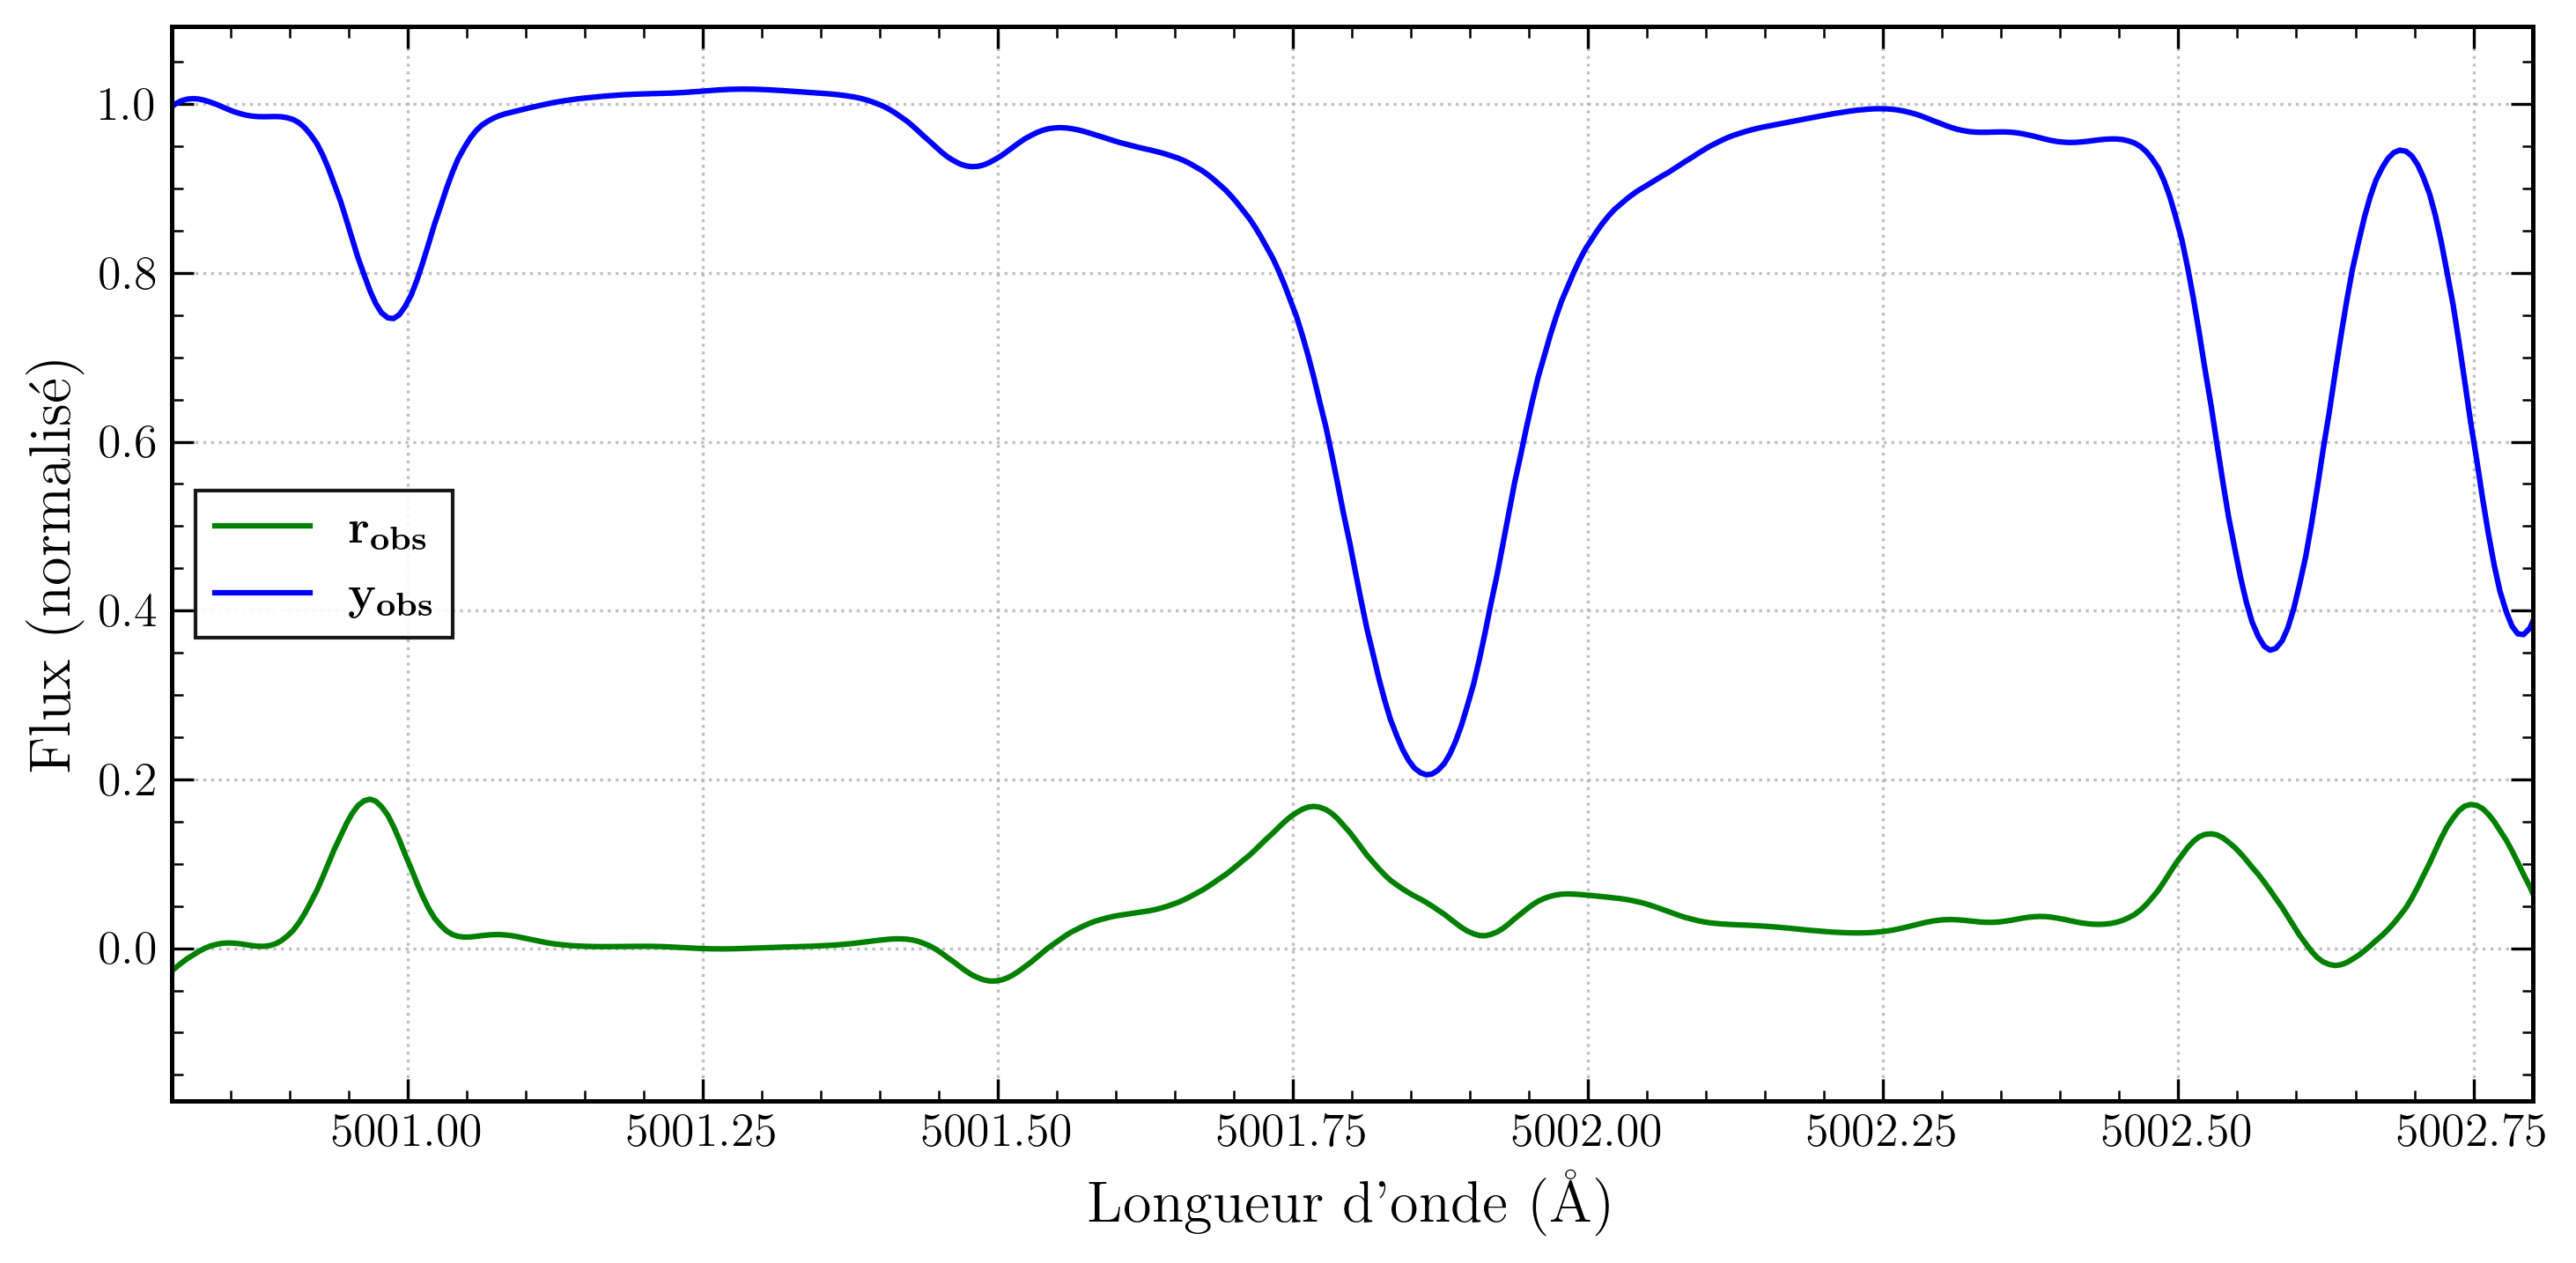

In [ ]:
b_obs = soap_spectra[np.linalg.norm(soap_activity, axis=1).argmin()]
y_obs = soap_spectra[0]
r_obs = (soap_spectra[0] - b_obs) * 100


plt.figure(figsize=(10, 5))
plt.plot(wavegrid, r_obs, label="$\mathbf{r_{obs}}$", color="green")
plt.plot(
    wavegrid,
    y_obs,
    label="$\mathbf{y_{obs}}$",
    color="blue",
)
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.xlim(5001.8 - 1, 5001.8 + 1)
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/bobs_and_yobs.png",
    dpi=300,
)
plt.show()


# Première Expérience : Entraînement d’AESTRA sur spectres de l’activité du soleil simulés

In [ ]:
spec_datachallenge = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_flux_YVA.npy"
)

summary = pd.read_csv(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_summary.csv"
)

jdb = summary["jdb"].values

material = np.load(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57000_E61000_planet-FallChallenge3/HARPN/STAR1134_HPN_Analyse_material.p",
    allow_pickle=True,
)
wavegrid_datachallenge = material["wave"].to_numpy()

template = material["stellar_template"].to_numpy()

In [ ]:
wavegrid_datachallenge[1] - wavegrid_datachallenge[0]

0.010009766

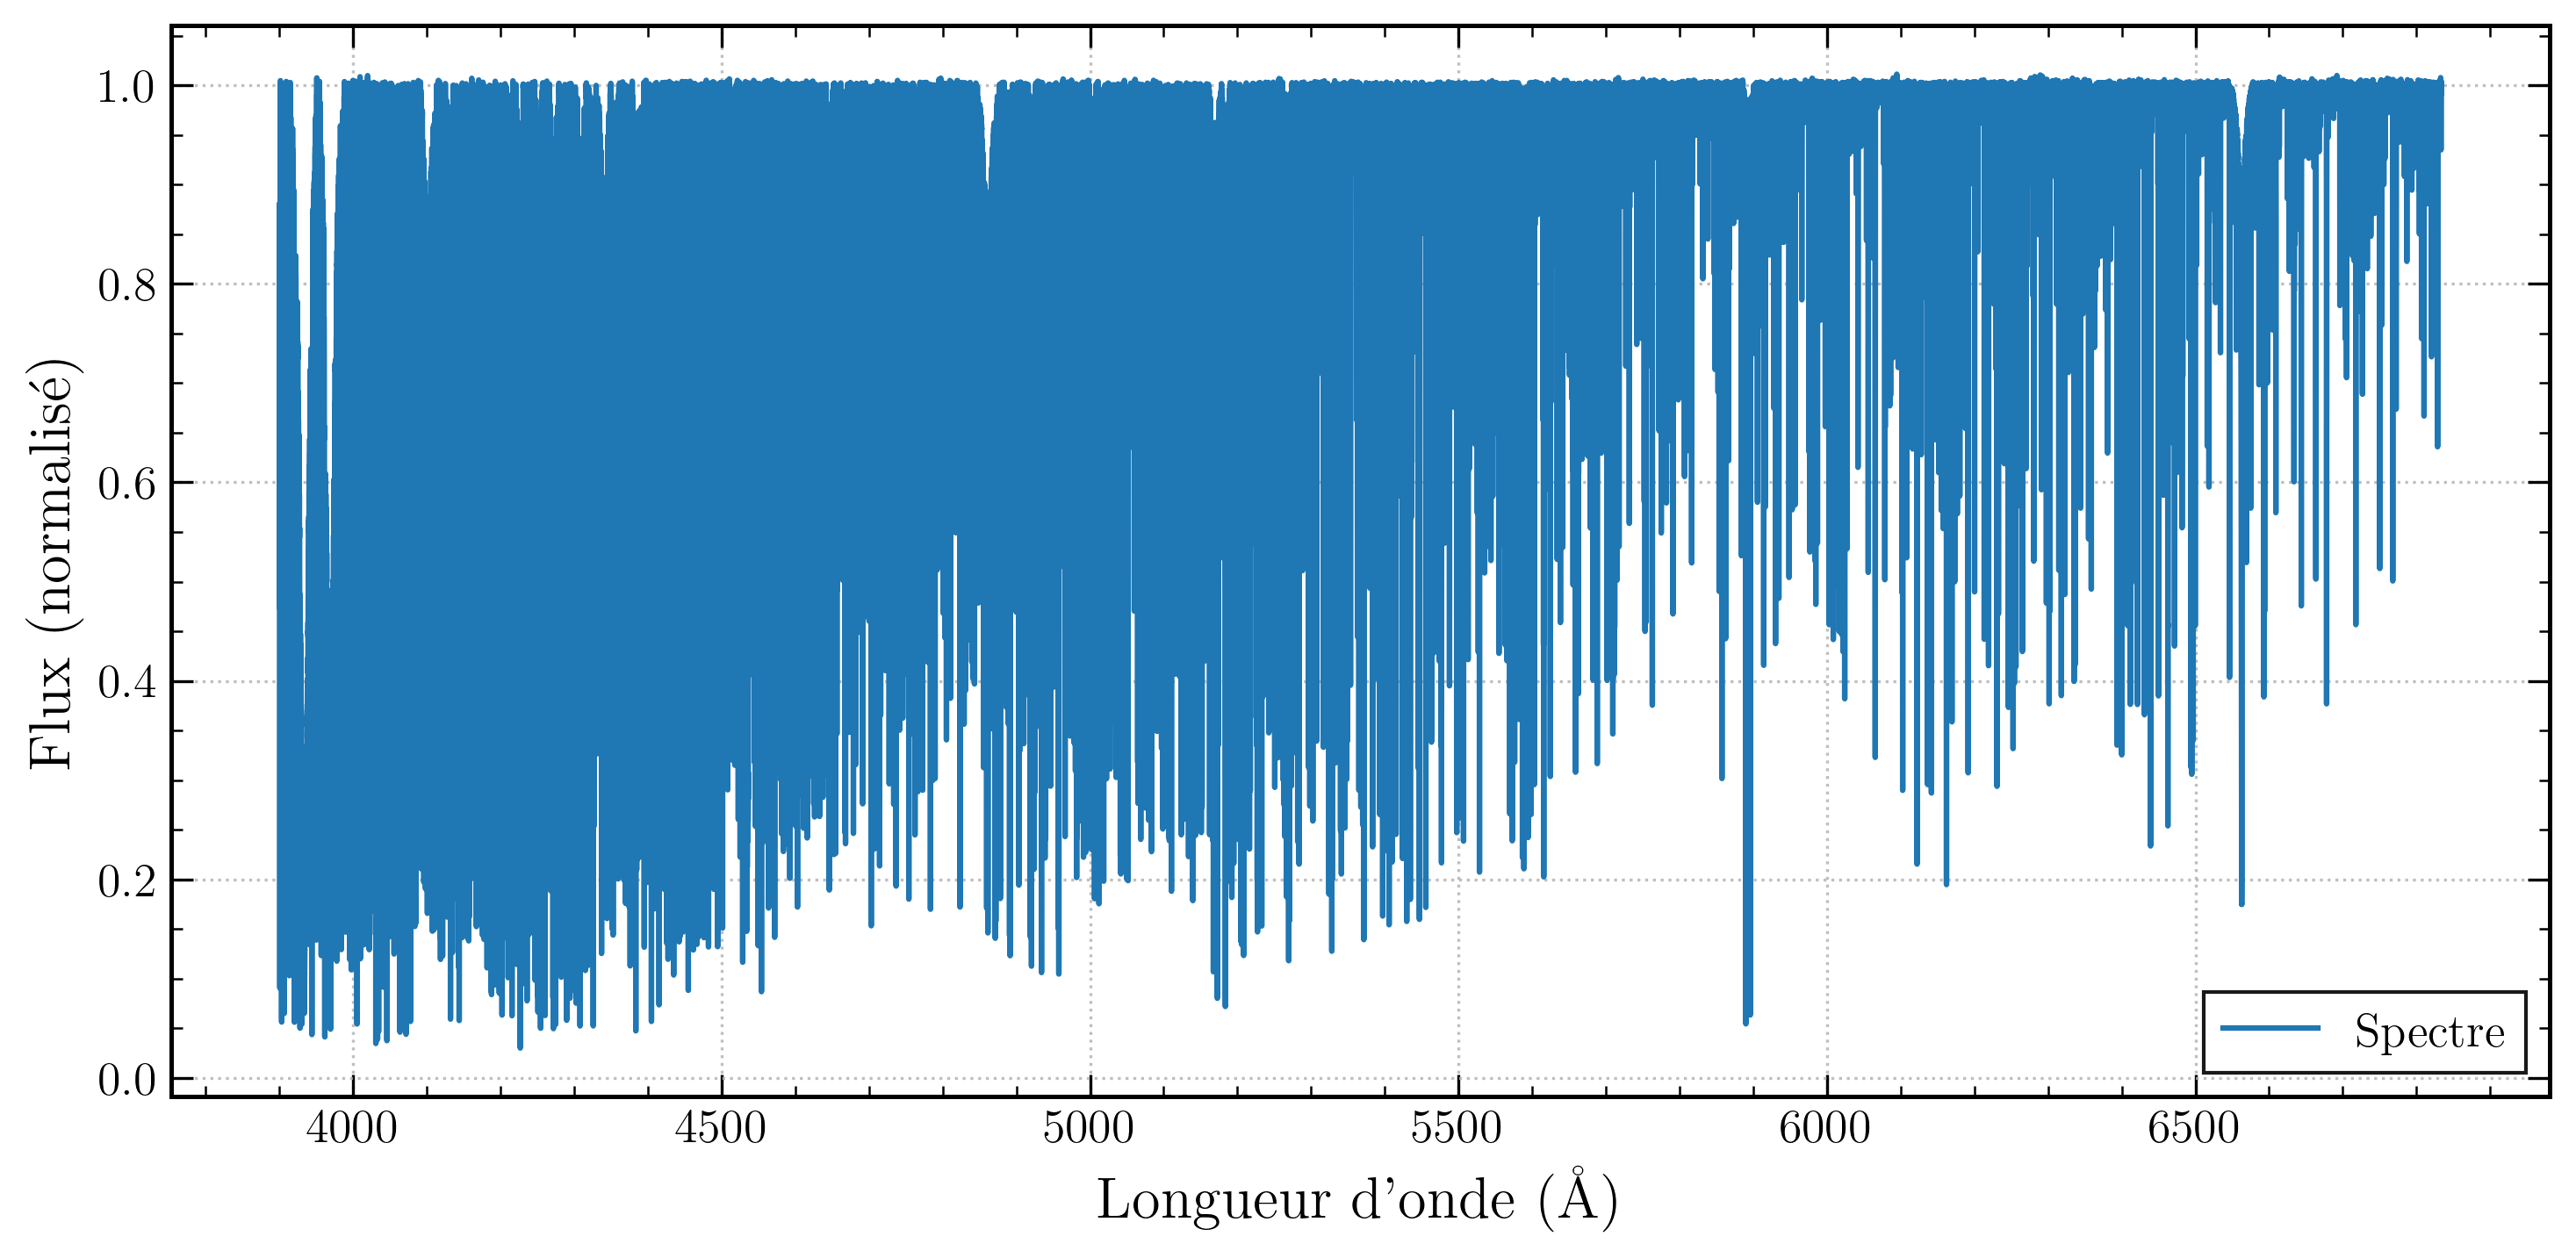

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(wavegrid_datachallenge, spec_datachallenge[0, :], label="Spectre", color="C0")
plt.xlabel("Longueur d'onde (Å)")
plt.ylabel("Flux (normalisé)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.savefig(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/contexte_scientifique/spectrum_example_rvdatachallenge.png",
    dpi=300,
)
plt.show()


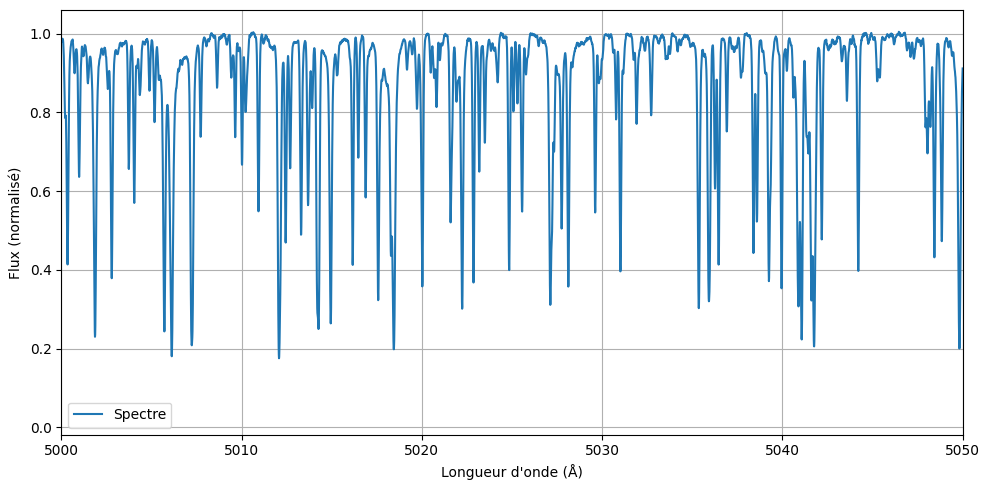

In [ ]:
with plt.style.context("default"):
    plt.figure(figsize=(10, 5))
    plt.plot(wavegrid_datachallenge, spec_datachallenge[0, :], label="Spectre", color="C0")
    plt.xlabel("Longueur d'onde (Å)")
    plt.ylabel("Flux (normalisé)")
    plt.legend()
    plt.xlim(5000, 5050)
    plt.grid()
    plt.tight_layout()
    plt.show()


[INFO] Conversion des dates : MJD (ajout 2_400_000.5 → JD)


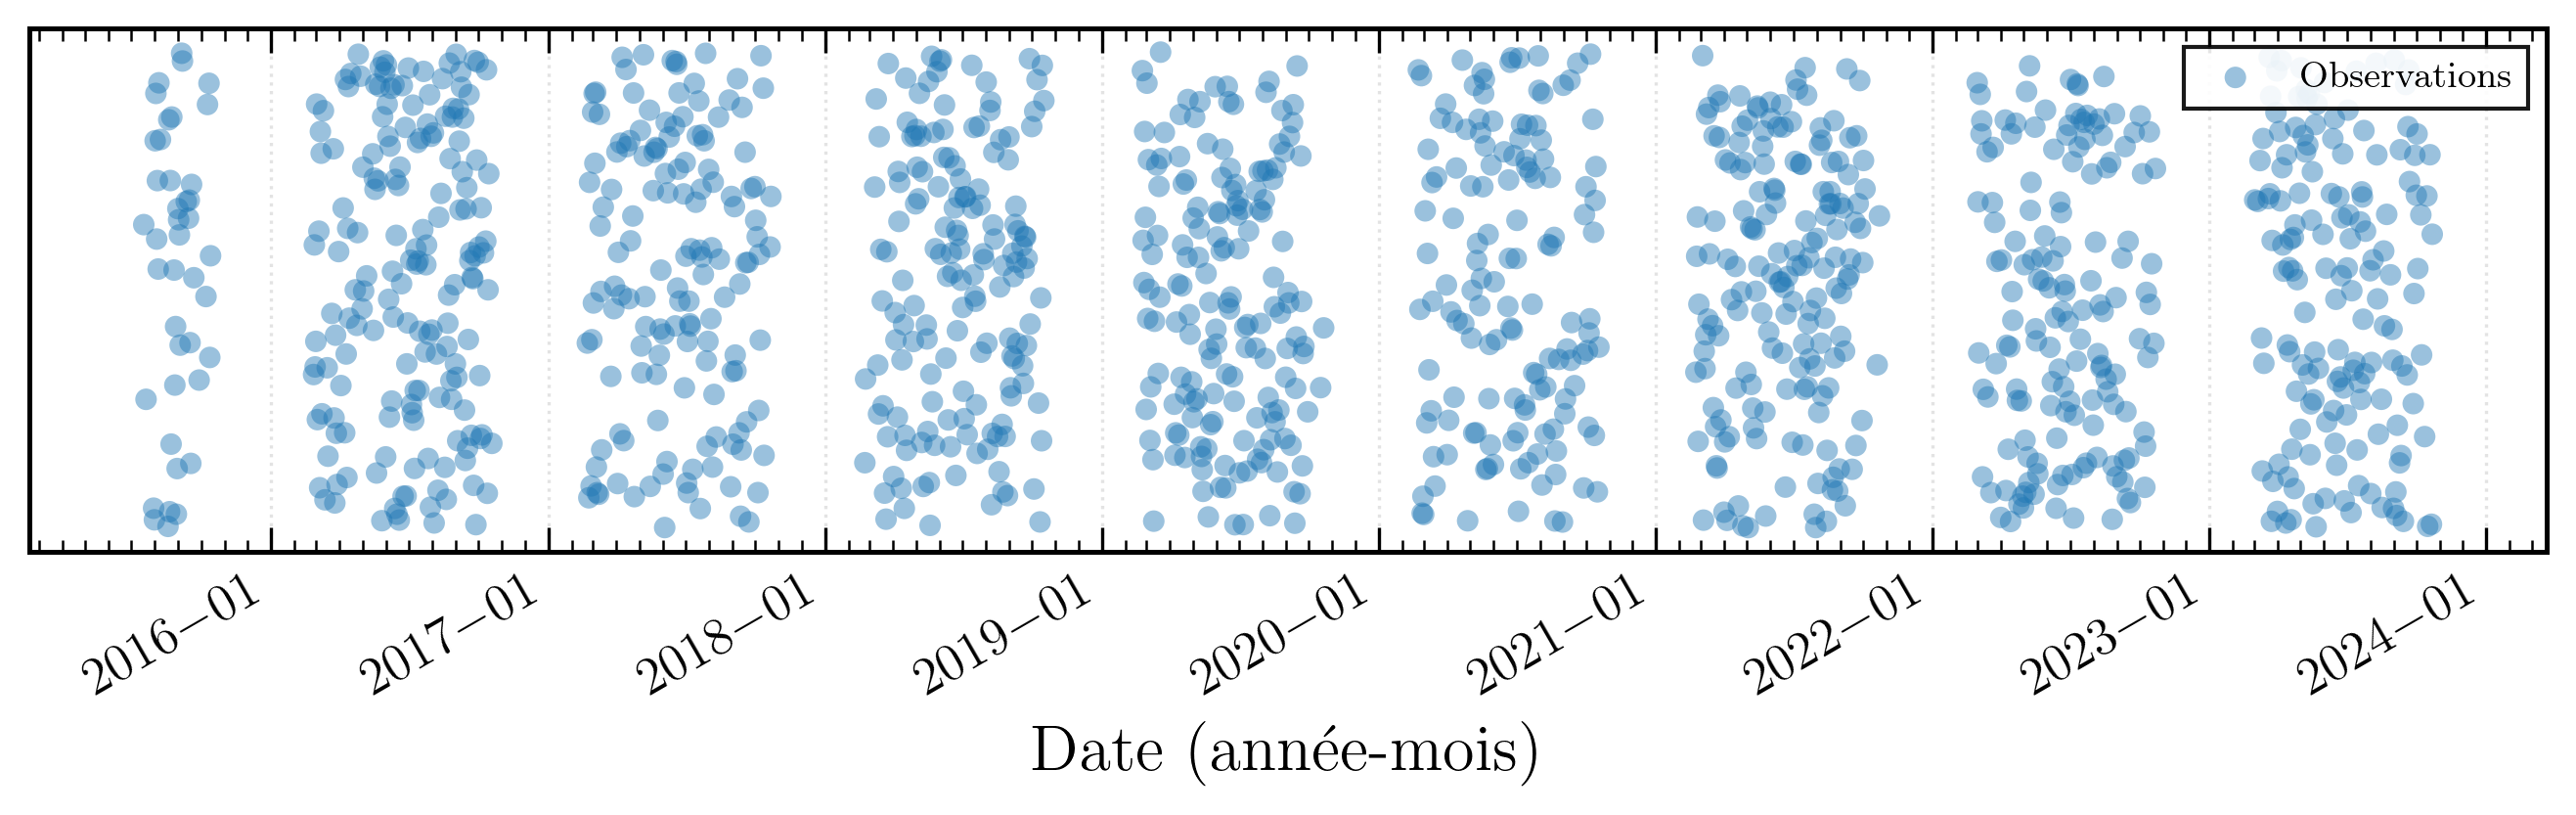

Figure sauvegardée : plots_rapport/premiere_exp/jdb_timeline_dates.png


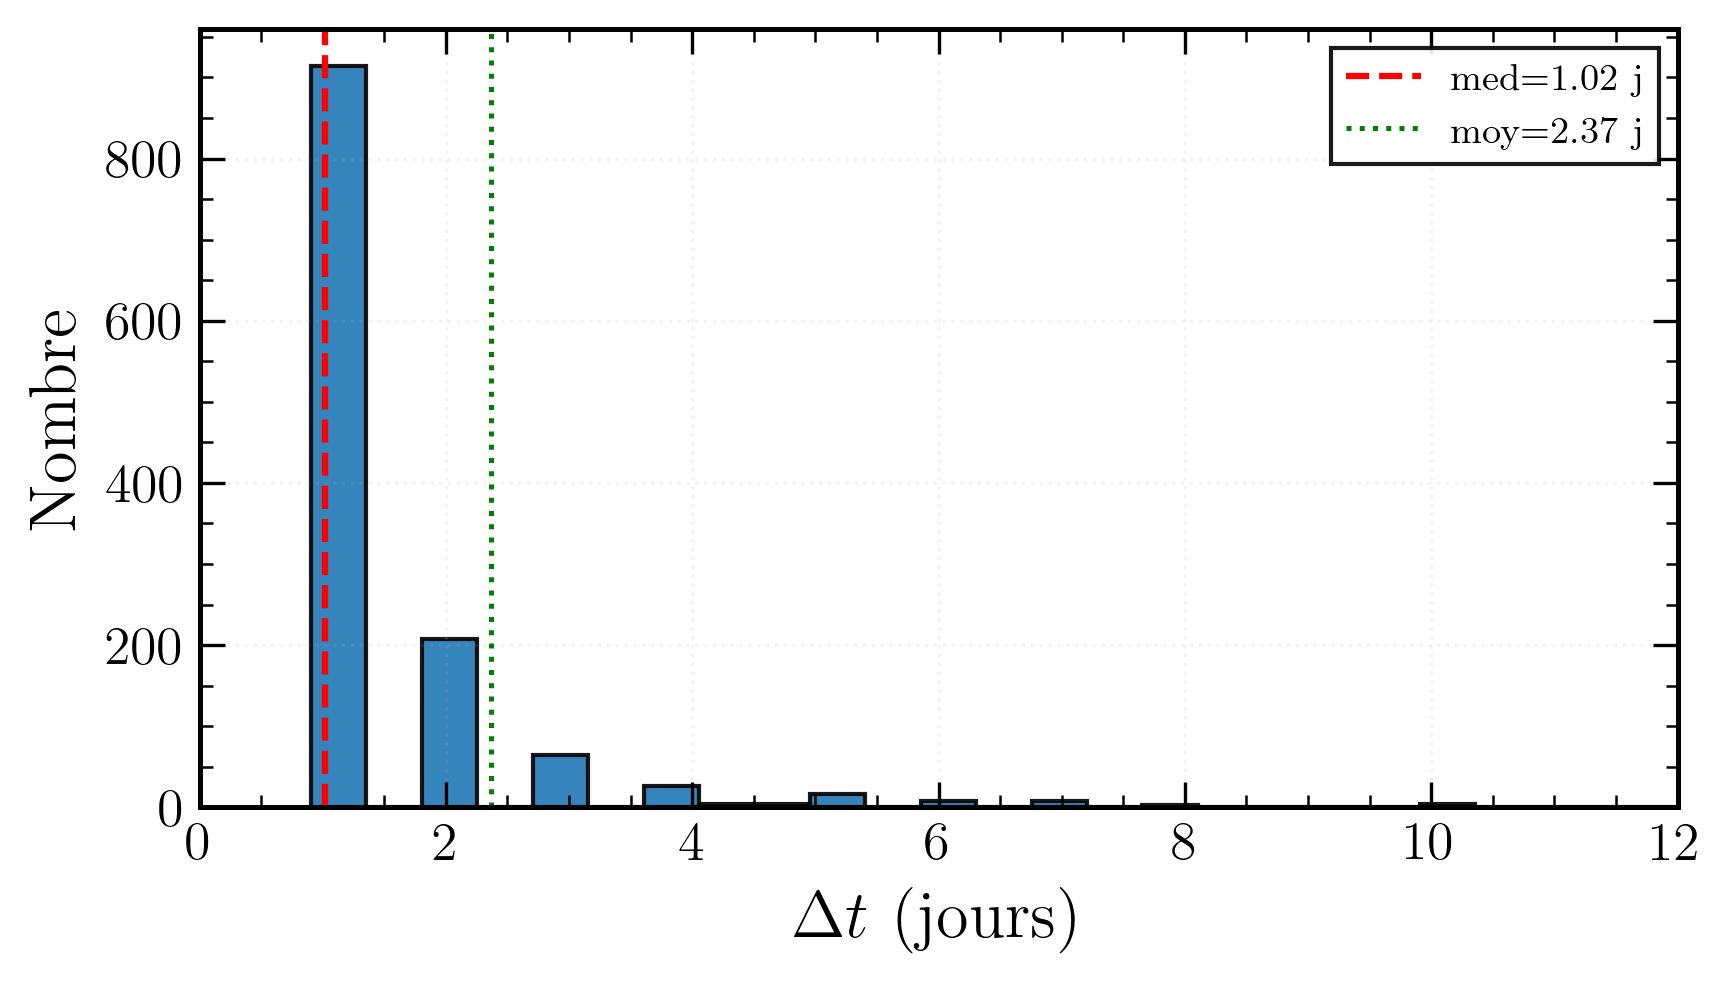

Figure sauvegardée : plots_rapport/premiere_exp/jdb_deltas_hist_zoom.png


In [ ]:
# ------------------------------------------------------------
# Trace : répartition des JDB + histogramme des écarts (2 figures)
# Avec conversion automatique JDB -> calendrier (année/mois/jour)
# ------------------------------------------------------------

import os
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pandas as pd
from astropy.time import Time


# ------------------------------------------------------------
# Fonction utilitaire : conversion JDB -> datetime
# ------------------------------------------------------------
def jdb_to_datetime(jdb_array: np.ndarray):
    """
    Convertit un tableau de dates 'jdb' en datetimes.
    - Si valeurs < 1e6 → suppose MJD/RJD et ajoute 2_400_000.5.
    - Sinon → suppose JD/BJD complet.
    Retourne (datetimes, info_scale).
    """
    jdb_array = np.asarray(jdb_array, dtype=float)
    med = np.nanmedian(jdb_array)
    if not np.isfinite(med):
        raise ValueError("jdb_array ne contient pas de valeurs finies.")

    if med < 1e6:  # cas MJD / RJD
        jd = jdb_array + 2_400_000.5
        scale_used = "MJD (ajout 2_400_000.5 → JD)"
    else:  # cas JD/BJD
        jd = jdb_array
        scale_used = "JD/BJD (aucun offset)"

    t = Time(jd, format="jd")
    dts = t.to_datetime()
    return np.array(dts), scale_used


# ------------------------------------------------------------
# Chargement des données jdb
# ------------------------------------------------------------
try:
    jdb_vals = np.asarray(jdb, dtype=float)
except Exception:
    filepath = Path(
        "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/"
        "Sun_B57001_E61001_planet-FallChallenge1/STAR1136_DACE_YVA.rdb"
    )
    df_yva_local = pd.read_csv(filepath, delim_whitespace=True, comment="#")
    df_yva_local = df_yva_local.iloc[1:, :-1]  # skip header row + last empty col
    for col in ("vrad", "svrad", "jdb"):
        if col in df_yva_local.columns:
            df_yva_local[col] = pd.to_numeric(df_yva_local[col], errors="coerce")
    jdb_vals = df_yva_local["jdb"].astype(float).to_numpy()

# --- Nettoyage ---
jdb_vals = jdb_vals[np.isfinite(jdb_vals)]
if jdb_vals.size == 0:
    raise ValueError("Aucune valeur de jdb disponible pour tracer.")

jdb_sorted = np.sort(jdb_vals)
deltas = np.diff(jdb_sorted)

# Conversion JDB → datetimes
datetimes, scale_used = jdb_to_datetime(jdb_sorted)
print(f"[INFO] Conversion des dates : {scale_used}")

# Dossier de sortie
outdir = Path("./plots_rapport/premiere_exp")
outdir.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# Figure 1 : Timeline avec axe calendrier
# ------------------------------------------------------------
fig, ax_timeline = plt.subplots(figsize=(9, 3))

rng = np.random.default_rng(0)
jitter = rng.uniform(-0.28, 0.28, size=datetimes.shape)

ax_timeline.scatter(
    datetimes,
    jitter,
    s=28,
    alpha=0.45,
    edgecolors="none",
    color="tab:blue",
    label="Observations",
)
ax_timeline.set_yticks([])
ax_timeline.set_xlabel("Date (année-mois)")
ax_timeline.grid(axis="x", alpha=0.35)

# Axe en années/mois
ax_timeline.xaxis.set_major_locator(mdates.YearLocator())
ax_timeline.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax_timeline.xaxis.set_minor_locator(mdates.MonthLocator())
fig.autofmt_xdate(rotation=30)

ax_timeline.legend(loc="upper right", fontsize=9)

outpath1 = outdir / "jdb_timeline_dates.png"
plt.tight_layout()
plt.savefig(outpath1, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {outpath1}")

# ------------------------------------------------------------
# Figure 2 : Histogramme des deltas (zoomé en jours)
# ------------------------------------------------------------
fig, ax_hist = plt.subplots(figsize=(6, 3.5))
if deltas.size > 0:
    ax_hist.hist(deltas, bins=300, alpha=0.9, edgecolor="k", color="tab:blue")
    ax_hist.set_xlabel(r"$\Delta t$ (jours)")
    ax_hist.set_ylabel("Nombre")
    ax_hist.grid(alpha=0.15)

    # Zoom resserré
    ax_hist.set_xlim(0, 12)

    # Médiane et moyenne
    med = float(np.median(deltas))
    mean = float(np.mean(deltas))
    ax_hist.axvline(med, linestyle="--", lw=1.5, color="red", label=f"med={med:.2f} j")
    ax_hist.axvline(
        mean, linestyle=":", lw=1.2, color="green", label=f"moy={mean:.2f} j"
    )
    ax_hist.legend(fontsize=9, loc="upper right")
else:
    ax_hist.text(
        0.5,
        0.5,
        "Pas d'écart (n < 2)",
        ha="center",
        va="center",
        transform=ax_hist.transAxes,
    )
    ax_hist.set_xticks([])
    ax_hist.set_yticks([])

outpath2 = outdir / "jdb_deltas_hist_zoom.png"
plt.tight_layout()
plt.savefig(outpath2, dpi=300, bbox_inches="tight")
plt.show()
print(f"Figure sauvegardée : {outpath2}")

/tmp/ipykernel_65773/3105442507.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")


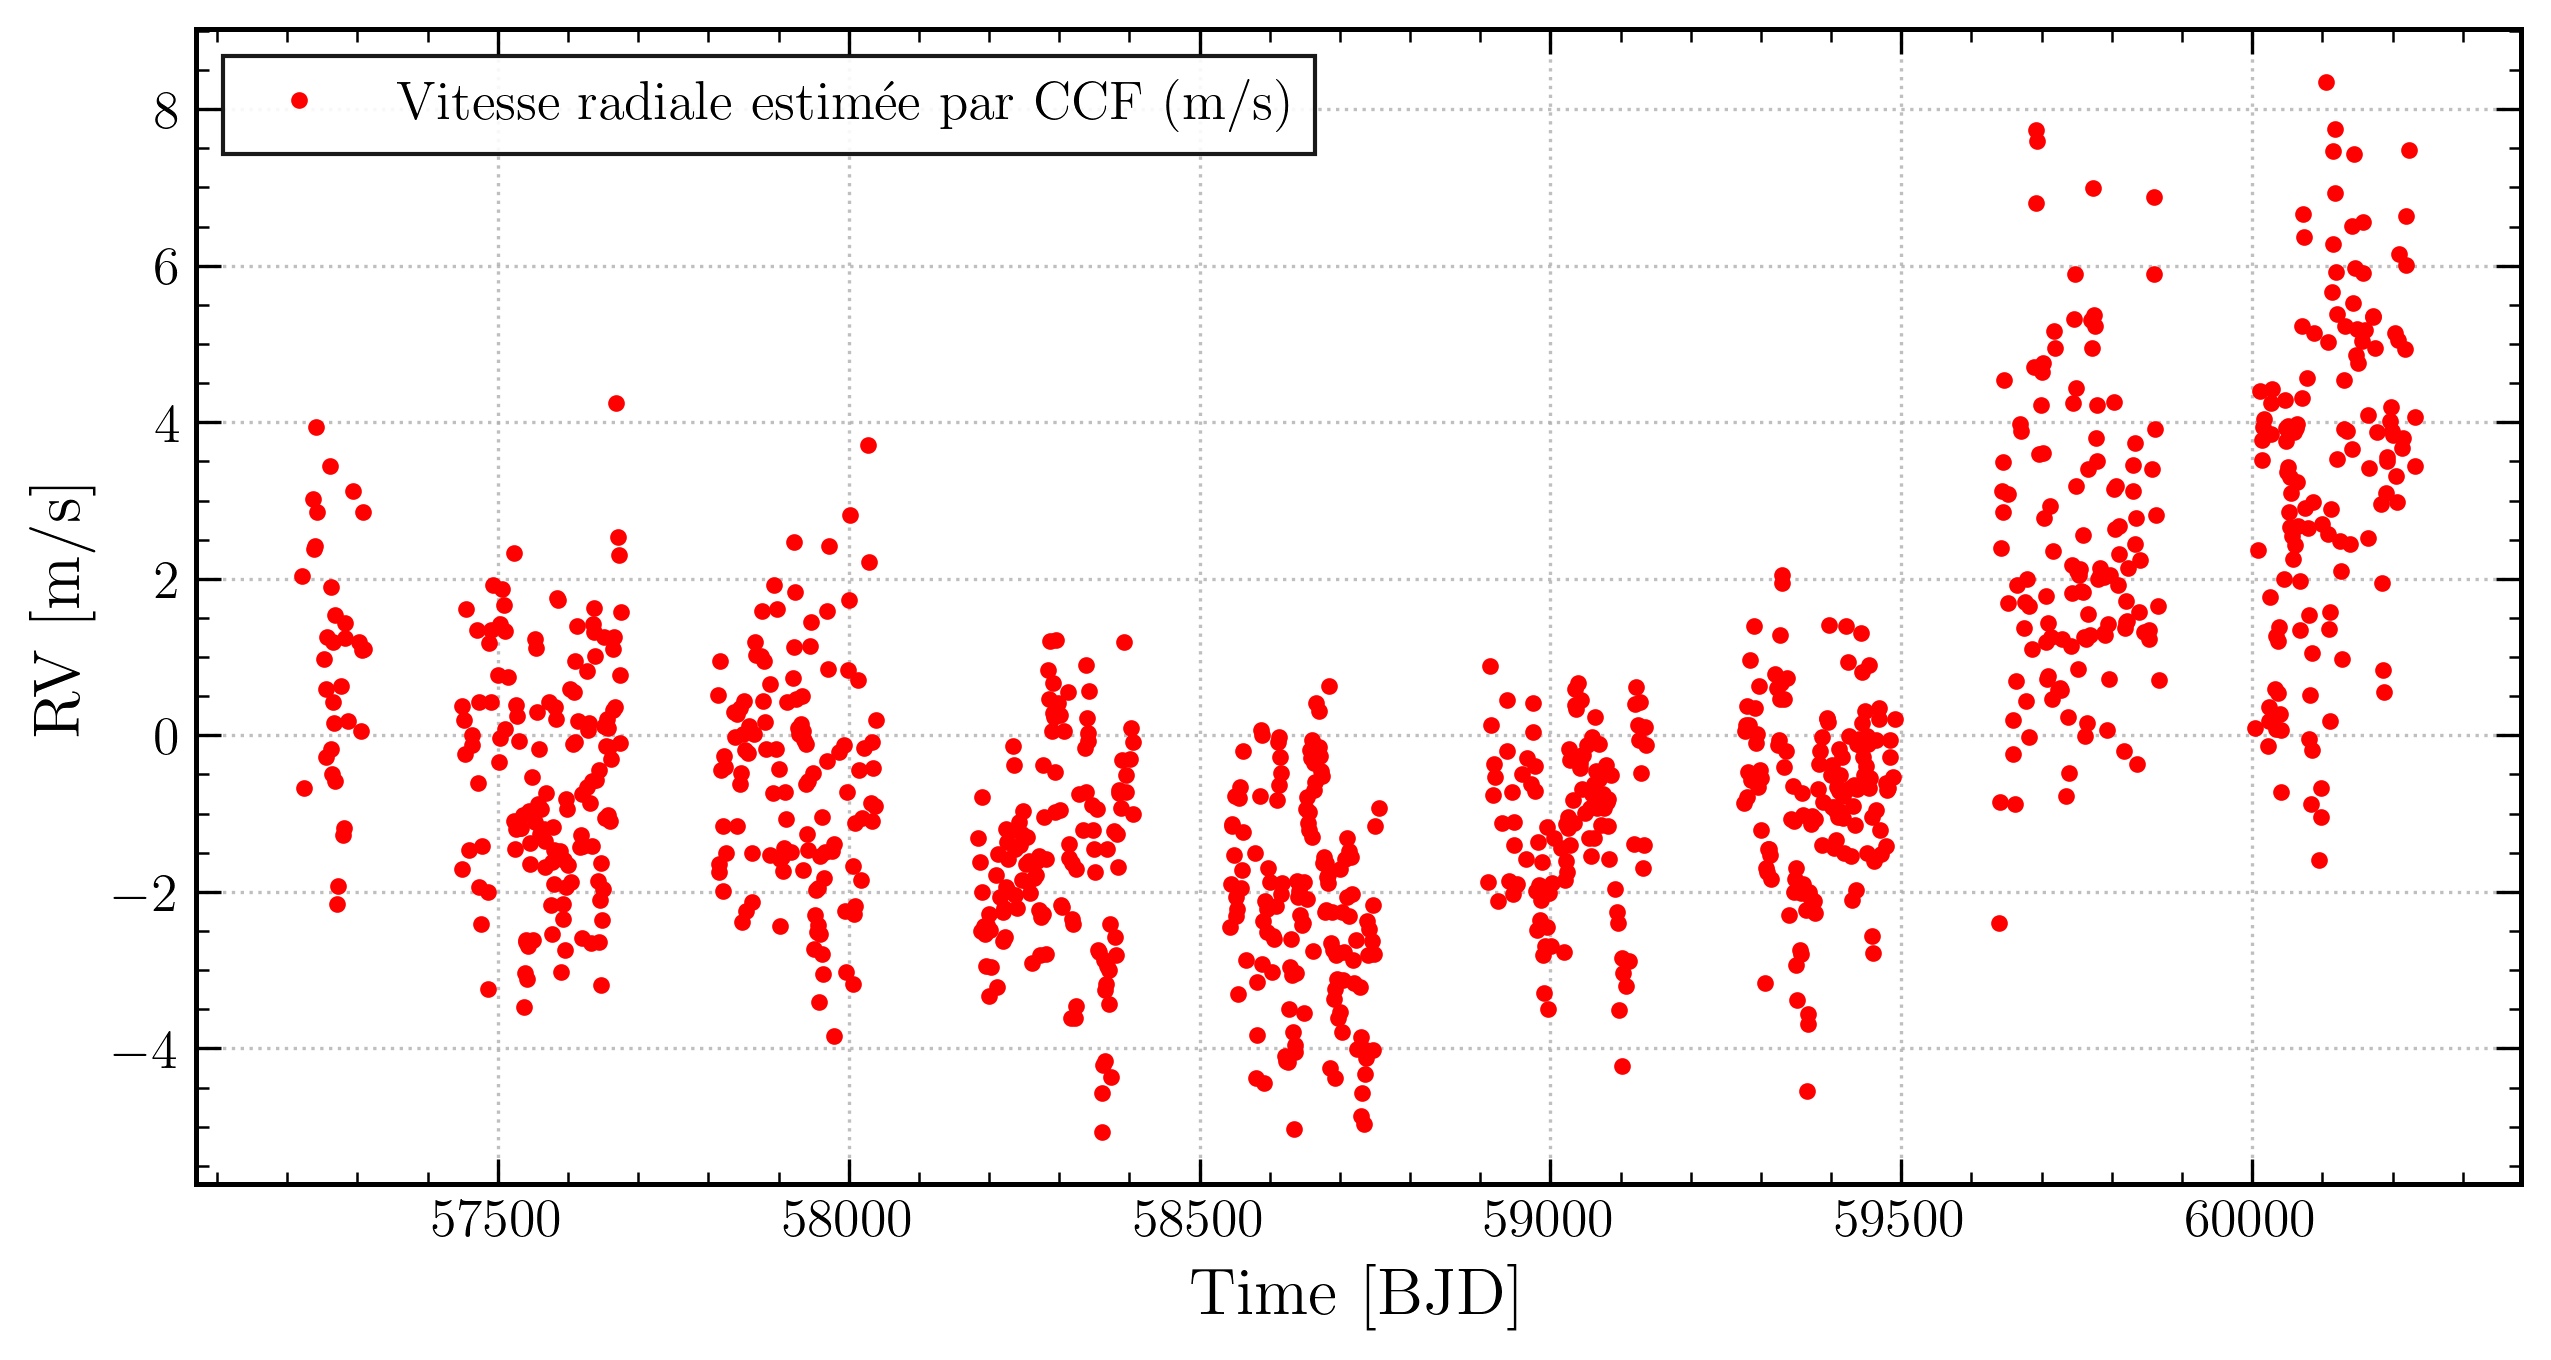

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline

for file_path in [
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/data/rv_datachallenge/Sun_B57001_E61001_planet-FallChallenge1/STAR1136_DACE_",
]:
    df_yva = pd.read_csv(f"{file_path}YVA.rdb", delim_whitespace=True, comment="#")

    df_yva = df_yva.iloc[1:]  # enlever la premiere ligne

    df_yva = df_yva.iloc[:, :-1]  # enlever la derniere colonne

    df_yva = df_yva.astype({"vrad": "float32", "svrad": "float32", "jdb": "float32"})

    rvA = (df_yva["vrad"] - df_yva["vrad"].mean()) * 1000
    rvA_err = df_yva["svrad"] * 1000
    timeA = df_yva["jdb"]

    rvA_mask = rvA <= 40
    rvA = rvA[rvA_mask]
    rvA_err = rvA_err[rvA_mask]
    timeA = timeA[rvA_mask]

    # --- Tracer ---
    plt.figure(figsize=(10, 5))
    plt.plot(
        timeA,
        rvA,
        marker="o",
        color="red",
        markersize=3,
        linestyle="",
        label="Vitesse radiale estimée par CCF (m/s)",
    )

    plt.xlabel("Time [BJD]")
    plt.ylabel("RV [m/s]")
    plt.grid()
    plt.legend()
    plt.savefig("./plots_rapport/premiere_exp/rvs_datachallenge.png", dpi=300, bbox_inches="tight")
    plt.show()


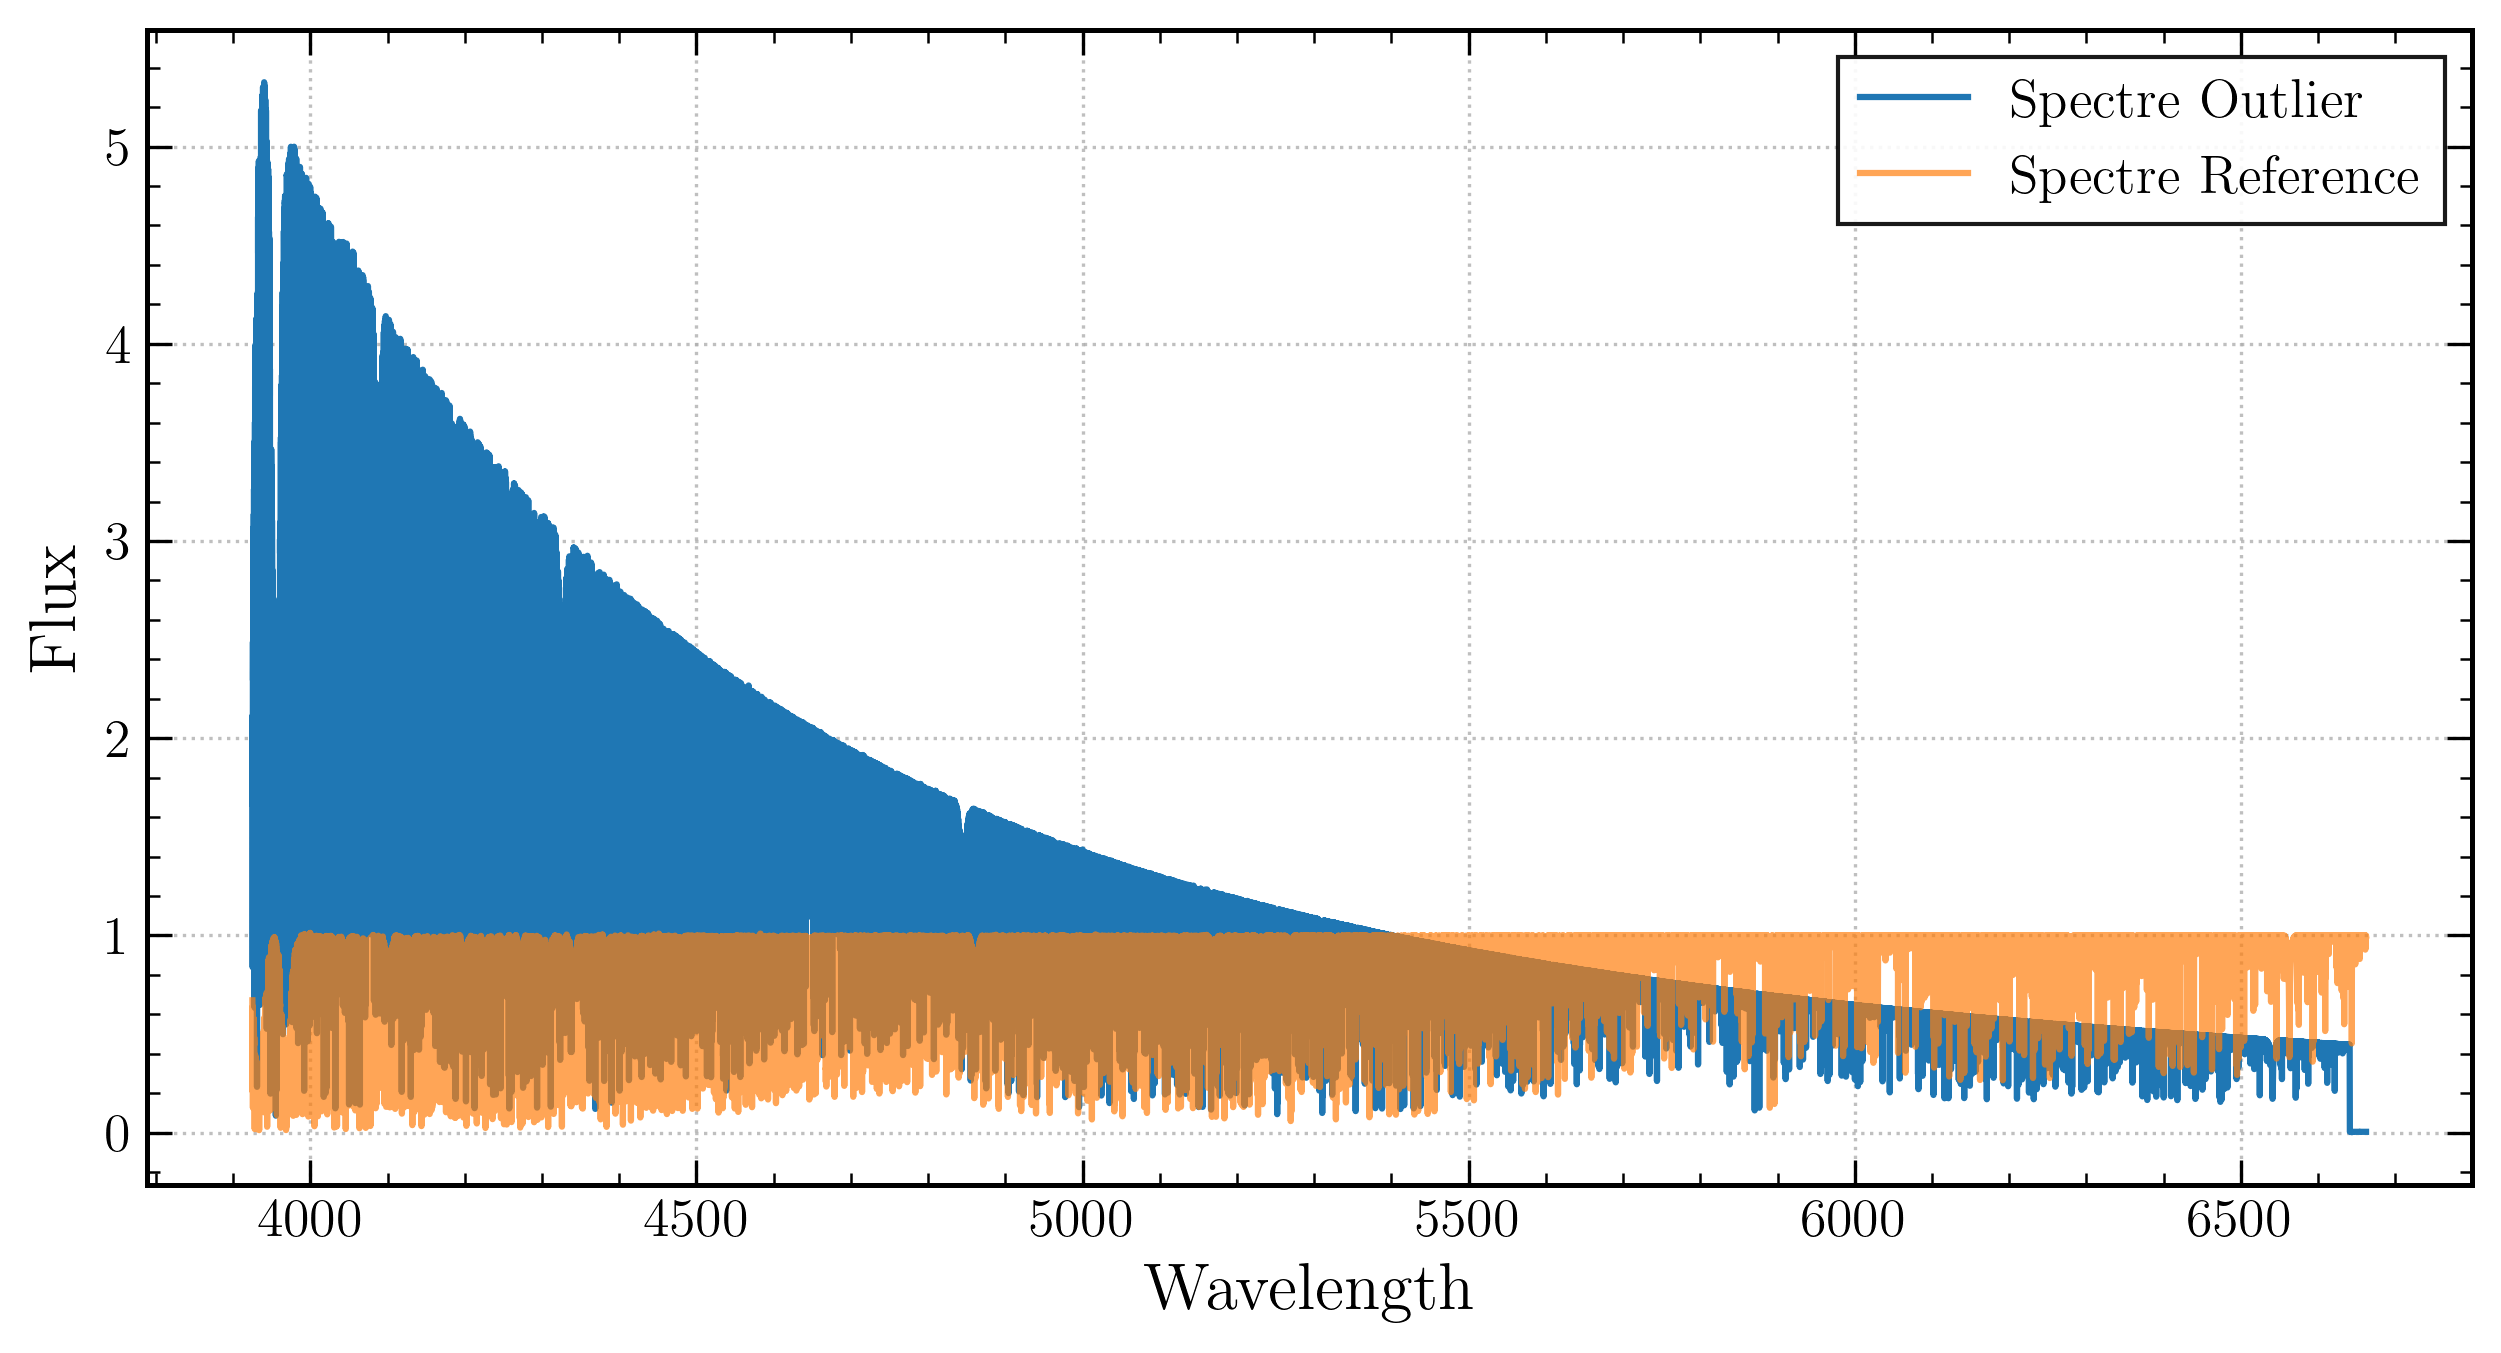

In [ ]:
import h5py

with h5py.File("../data/soap_gpu_paper/spec_cube_tot.h5", "r") as f:
    spectre_outlier = f["spec_cube"][1453]
    spectre_ref = f["spec_cube"][1455]

wavegrid_outlier = np.load("../data/soap_gpu_paper/wavegrid.npy")

plt.figure(figsize=(10, 5))
plt.plot(wavegrid_outlier, spectre_outlier, label="Spectre Outlier")
plt.plot(wavegrid_outlier, spectre_ref, alpha=0.7, label="Spectre Reference")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.grid()
plt.legend()
plt.savefig("./plots_rapport/premiere_exp/outlier_example.png")
plt.show()


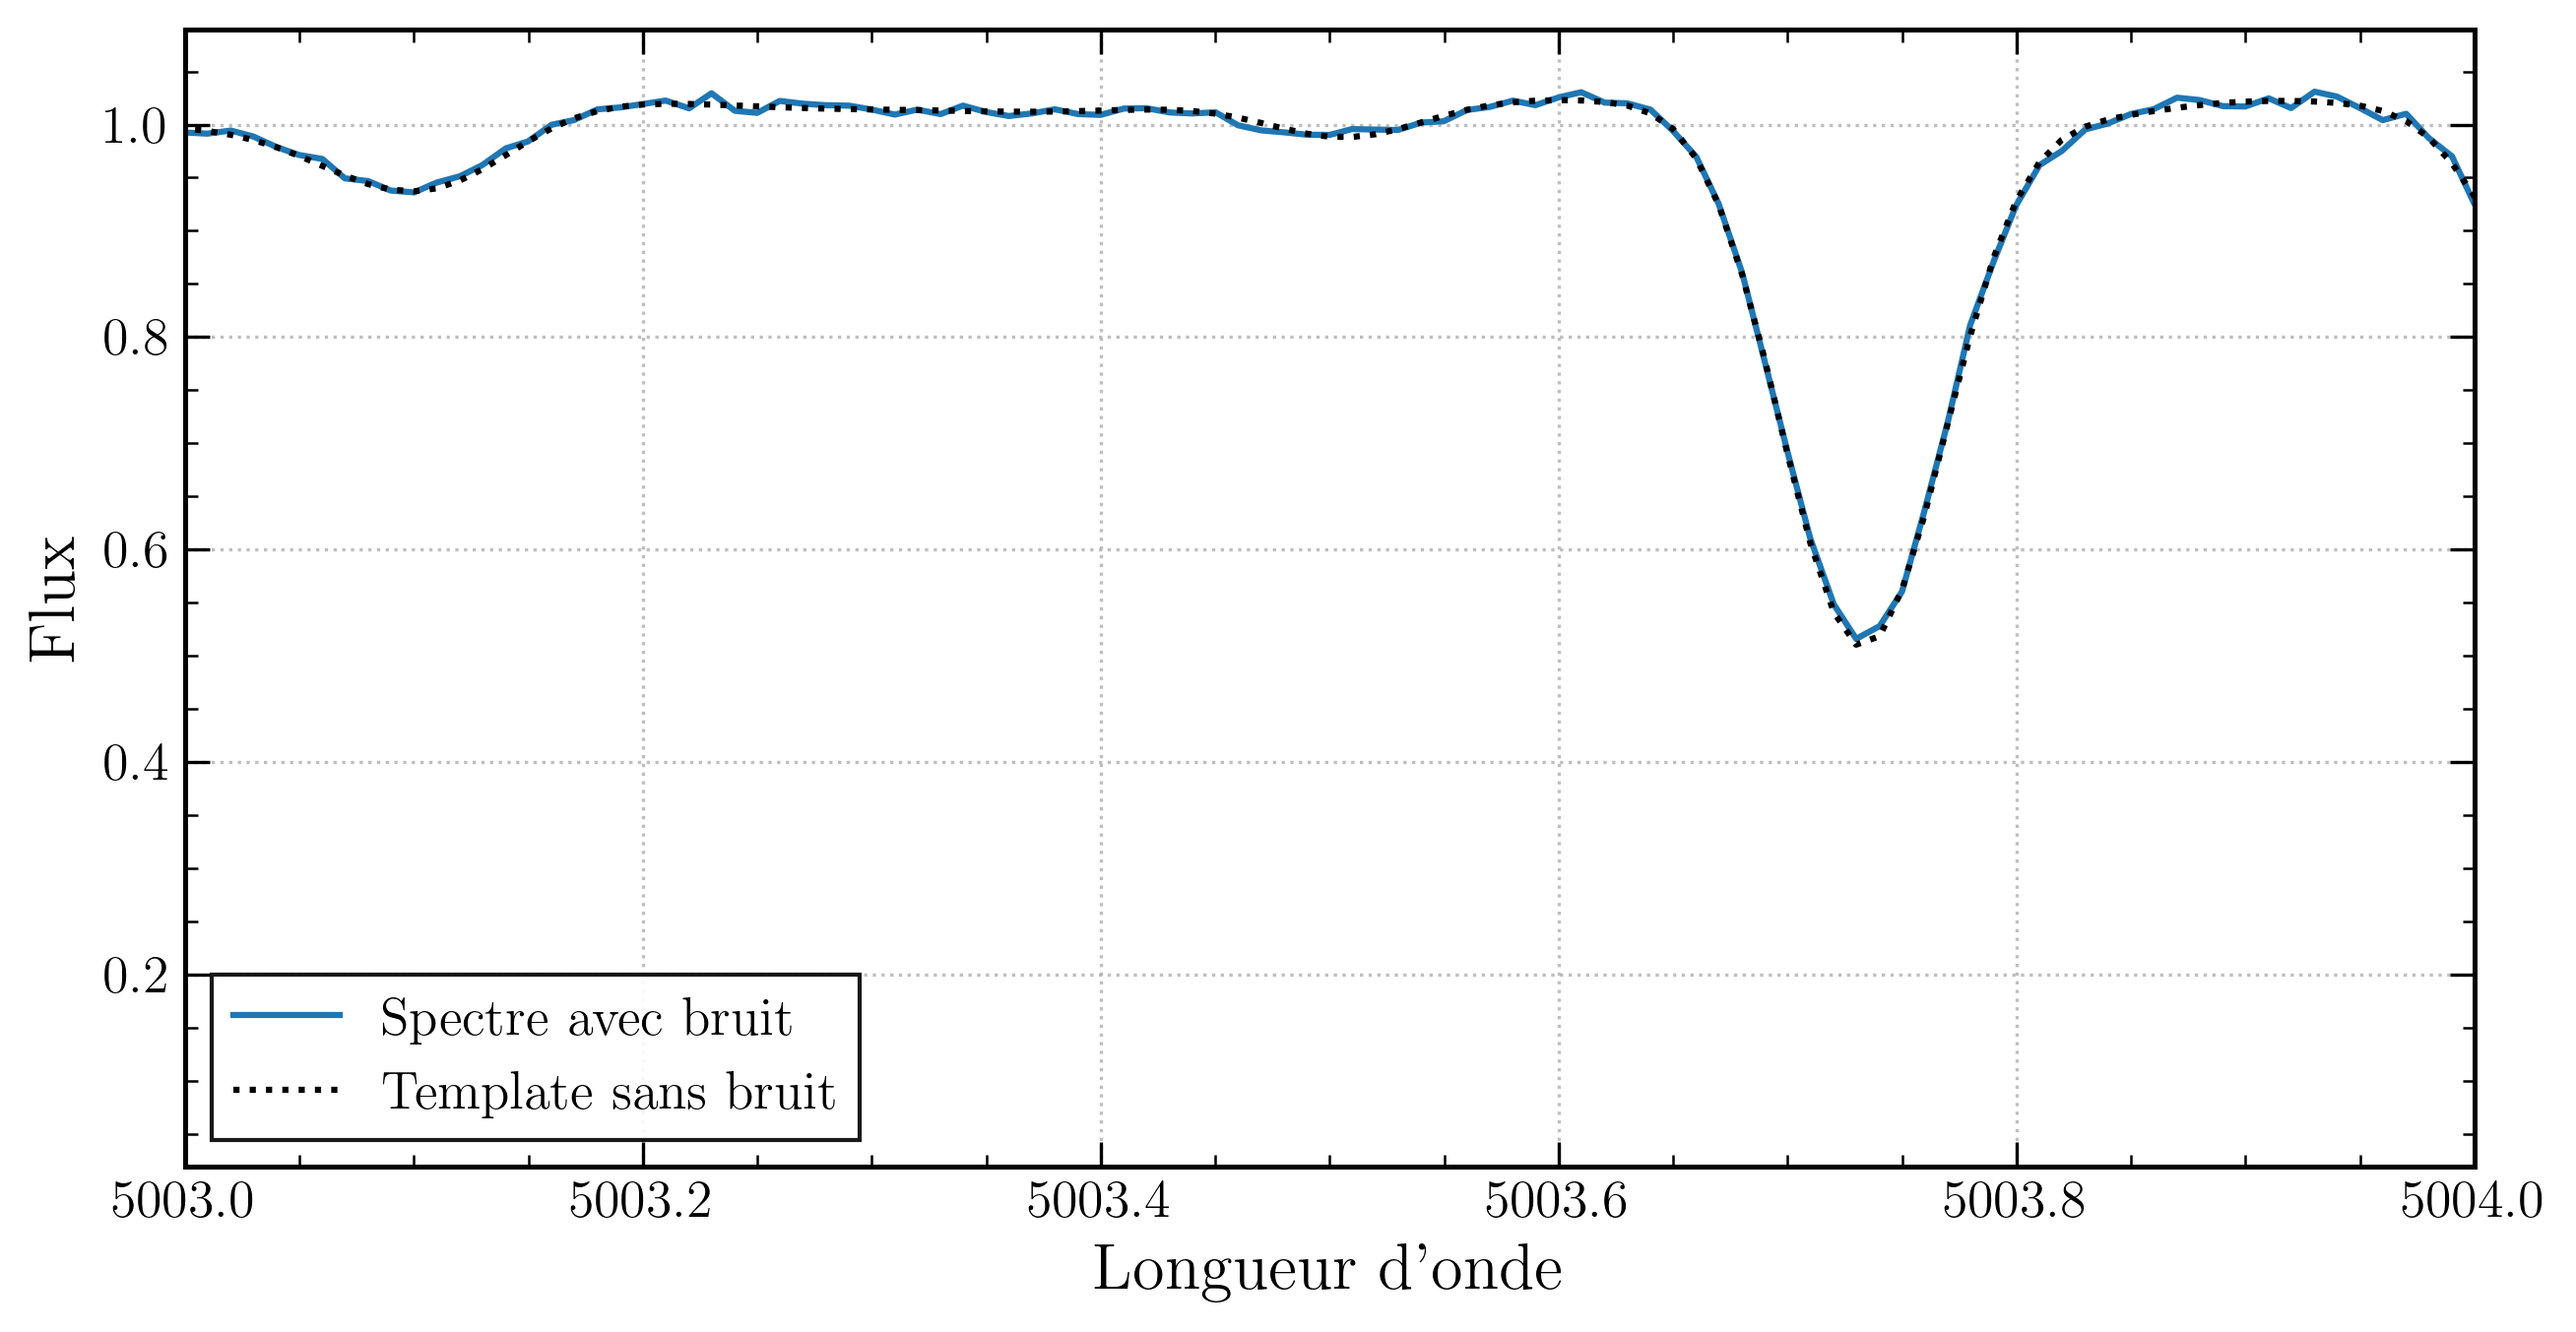

In [ ]:
dset_train = np.load(
    "../data/npz_datasets/soapgpu_ns1275_5000-5050_harps-noise-1_p100_k0p3_phi0.npz"
)

spectra_train = dset_train["spectra"]
template = dset_train["template"]
wavegrid_train = dset_train["wavegrid"]
activity_train = dset_train["activity"]

%matplotlib inline
plt.figure(figsize=(10, 5))
plt.plot(wavegrid_train, spectra_train[0, :], label="Spectre avec bruit")
plt.plot(wavegrid_train, template, label="Template sans bruit", color="black", linestyle=':')
plt.xlabel("Longueur d'onde")
plt.ylabel("Flux")
plt.grid()
plt.legend()
plt.xlim(5003, 5004)
plt.savefig("./plots_rapport/premiere_exp/spectra_noise_example.png", dpi=300)
plt.show()

In [ ]:
from src.modeling.train import load_experiment_checkpoint

ckpt = load_experiment_checkpoint(
    "../experiments/aestra_baseline/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/soapgpu_ns1275_5000-5050_harps-noise-1_p100_k0p3_phi0.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]


# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=False, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

batch = next(iter(dataloader))
(
    batch_yobs,
    batch_yaug,
    batch_voffset_true,
    batch_wavegrid,
    batch_weights_fid,
    batch_indices,
    batch_yact_true,
    batch_activity_proxies_norm,
    batch_yact_noised,
) = batch

batch_yact, batch_s = ckpt_model.spender(batch_yobs.cpu() - ckpt_model.b_obs)

batch_yact = batch_yact.detach().cpu().numpy()
batch_s = batch_s.detach().cpu().numpy()
batch_yobs = batch_yobs.detach().cpu().numpy()
batch_wavegrid = batch_wavegrid.detach().cpu().numpy()
batch_yact_true = batch_yact_true.detach().cpu().numpy()
batch_yact_noised = batch_yact_noised.detach().cpu().numpy()

b_rest = ckpt_model.b_rest.detach().cpu().numpy()

[14:43:07] 📂 Loading experiment checkpoint: ../experiments/aestra_baseline/models/aestra_final.pth    ]8;id=665304;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=841147;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#193\193]8;;\

NameError: name 'DataLoader' is not defined

In [ ]:
%matplotlib widget
# Plot de l'activité vs activité réelle
plt.figure(figsize=(10, 5))
plt.plot(
    batch_wavegrid[0], batch_yact[0], label="Activité estimée par AESTRA", color="blue"
)
plt.plot(
    batch_wavegrid[0],
    batch_yact_true[0],
    label="Activité réelle (SOAP)",
    color="orange",
)
plt.xlabel("Activité réelle")
plt.ylabel("Activité estimée")
plt.title("Activité réelle vs Activité estimée")
plt.grid()
plt.legend()
plt.show()

# %matplotlib inline

# # Plot de l'activité vs activité bruitée
# plt.figure(figsize=(10, 5))
# plt.plot(
#     batch_wavegrid[0], batch_yact[0], label="Activité estimée par AESTRA", color="blue"
# )
# plt.plot(
#     batch_wavegrid[0],
#     batch_yact_noised[0],
#     label="Activité bruitée (SOAP)",
#     color="orange",
# )
# plt.xlabel("Activité réelle")
# plt.ylabel("Activité estimée")
# plt.title("Activité réelle vs Activité bruitée")
# plt.legend()
# plt.grid()
# plt.show()



ValueError: Key backend: 'module://ipympl.backend_nbagg' is not a valid value for backend; supported values are ['gtk3agg', 'gtk3cairo', 'gtk4agg', 'gtk4cairo', 'macosx', 'nbagg', 'notebook', 'qtagg', 'qtcairo', 'qt5agg', 'qt5cairo', 'tkagg', 'tkcairo', 'webagg', 'wx', 'wxagg', 'wxcairo', 'agg', 'cairo', 'pdf', 'pgf', 'ps', 'svg', 'template', 'inline']

In [ ]:
%matplotlib widget
with plt.style.context("default"):
    plt.figure(figsize=(10, 5))
    # plt.plot(batch_wavegrid[0], b_rest, label="$b_{rest}$", color="blue")
    # plt.plot(batch_wavegrid[0], batch_yobs[0], label="$y_{obs}$", color="black")
    # plt.plot(
    #     wavegrid_datachallenge[
    #         (wavegrid_datachallenge >= 5000) & (wavegrid_datachallenge <= 5050)
    #     ],
    #     spec_datachallenge[
    #         0, (wavegrid_datachallenge >= 5000) & (wavegrid_datachallenge <= 5050)
    #     ],
    #     label="Spectre rv datachallenge",
    #     color="C0",
    # )
    plt.plot(
        batch_wavegrid[0], b_rest, label="$b_{rest}$ estimée par AESTRA", color="black"
    )
    plt.plot(
        batch_wavegrid[0], ckpt_dset.template.cpu(), label="$template$", color="red"
    )
    # plt.plot(
    #     wavegrid_datachallenge[
    #         (wavegrid_datachallenge >= 5000) & (wavegrid_datachallenge <= 5050)
    #     ],
    #     template[(wavegrid_datachallenge >= 5000) & (wavegrid_datachallenge <= 5050)
    #     ],
    #     label="Spectre rv datachallenge",
    #     color="C1",
    # )
    plt.grid()
    plt.legend()
plt.show()


In [ ]:
from src.dataset import SpectrumDataset, generate_collate_fn


dset_soap_test = np.load("../data/npz_datasets/soapgpu_ns1275_5000-5010.npz")

spectra = dset_soap_test["spectra"]
wavegrid = dset_soap_test["wavegrid"]
activity = dset_soap_test["activity"]
template = dset_soap_test["template"]

%matplotlib qt
with plt.style.context("default"):
    plt.figure(figsize=(10, 5))
    plt.plot(wavegrid, spectra[448], label='spectre', marker='x')
    plt.plot(wavegrid, template, label='template', linestyle='--')
    plt.grid()
    plt.legend()
    plt.show()


In [ ]:
np.linalg.norm(activity, axis=1).argmin()

582

In [ ]:
for key in dset_soap_test.files:
    print(key)

wavegrid
template
spectra
activity
time_values
v_true
metadata
activity_proxies
activity_proxies_norm
activity_proxies_med
activity_proxies_mad
ccfs
spectra_no_activity


In [67]:
from src.modeling.train import load_experiment_checkpoint
from src.dataset import generate_collate_fn

ckpt = load_experiment_checkpoint(
    "../experiments/fine_tuned/models/aestra_final.pth",
    dataset_filepath="../data/npz_datasets/rvdatachallenge_ns1275_5000-5010.npz",
    device="cpu",
)

ckpt_dset = ckpt["dataset"]
ckpt_model = ckpt["model"]


# Préparer DataLoader
collate_fn = generate_collate_fn(ckpt_dset)
dataloader = DataLoader(ckpt_dset, batch_size=32, shuffle=True, collate_fn=collate_fn)

# Modèle en évaluation sur CPU
ckpt_model.eval()
device = torch.device("cpu")
ckpt_model.to(device)

all_s = []
all_vencode = []
all_yact_norm = []
all_bjd = []

for batch in dataloader:
    batch_yobs = batch[0].to("cpu")  # [B, P]

    batch_vencode = ckpt_model.rvestimator(batch_yobs - ckpt_model.b_rest)

    batch_yact, batch_s = ckpt_model.spender(batch_yobs - ckpt_model.b_rest)

    all_s.append(batch_s.detach().cpu().numpy())
    all_vencode.append(batch_vencode.detach().cpu().numpy())
    all_yact_norm.append(np.linalg.norm(batch_yact.detach().cpu().numpy(), axis=1))


all_s = np.concatenate(all_s, axis=0)  # taille [1000, 3] ici
all_vencode = np.concatenate(all_vencode, axis=0)  # taille [1000] ici
all_yact_norm = np.concatenate(all_yact_norm, axis=0)  # taille [1000, P] ici


[04:49:44] 📂 Loading experiment checkpoint: ../experiments/fine_tuned/models/aestra_final.pth         ]8;id=131163;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py\train.py]8;;\:]8;id=445915;file:///home/tliopis/Codes/exoplanets_llopis_mary_2025/src/modeling/train.py#193\193]8;;\

In [68]:
# -*- coding: utf-8 -*-
import numpy as np
import plotly.graph_objects as go


def plot_latent_3d_interactive(
    S,
    color=None,
    color_label="",
    title="AESTRA latent space (3D + axis projections)",
    point_size=3.5,
    shadow_size=2.5,
    shadow_alpha=0.35,
    cmap="Viridis",
    view_elev_deg=20,
    view_azim_deg=40,
    pad_frac=0.06,
):
    """
    S: array (N,3) -> colonnes [s1, s2, s3]
    color: array (N,) pour colorer les points (ex: RV). Si None -> index.
    """
    S = np.asarray(S, float)
    assert S.ndim == 2 and S.shape[1] == 3, "S doit être (N,3)"
    N = S.shape[0]

    if color is None:
        cvals = np.arange(N, dtype=float)
        clabel = "index"
    else:
        cvals = np.asarray(color).reshape(-1)
        assert cvals.shape[0] == N, "color doit avoir N éléments"
        clabel = color_label or "color"

    # bornes + marge
    mins, maxs = S.min(axis=0), S.max(axis=0)
    span = maxs - mins
    pad = pad_frac * span.max()
    xlo, xhi = float(mins[0] - pad), float(maxs[0] + pad)
    ylo, yhi = float(mins[1] - pad), float(maxs[1] + pad)
    zlo, zhi = float(mins[2] - pad), float(maxs[2] + pad)

    # --- caméra (élévation / azimut)
    az, el = np.deg2rad(view_azim_deg), np.deg2rad(view_elev_deg)
    r_eye = 2.2
    eye = dict(
        x=r_eye * np.cos(el) * np.cos(az),
        y=r_eye * np.cos(el) * np.sin(az),
        z=r_eye * np.sin(el),
    )

    # points principaux
    main = go.Scatter3d(
        x=S[:, 0],
        y=S[:, 1],
        z=S[:, 2],
        mode="markers",
        marker=dict(
            size=point_size,
            color=cvals,
            colorscale=cmap,
            colorbar=dict(title=clabel),
            opacity=0.95,
        ),
        name="latent",
    )

    # projections grises
    shadow_xy = go.Scatter3d(
        x=S[:, 0],
        y=S[:, 1],
        z=np.full_like(S[:, 0], zlo),
        mode="markers",
        marker=dict(size=shadow_size, color="gray", opacity=shadow_alpha),
        showlegend=False,
        hoverinfo="skip",
    )
    shadow_yz = go.Scatter3d(
        x=np.full_like(S[:, 1], xlo),
        y=S[:, 1],
        z=S[:, 2],
        mode="markers",
        marker=dict(size=shadow_size, color="gray", opacity=shadow_alpha),
        showlegend=False,
        hoverinfo="skip",
    )
    shadow_xz = go.Scatter3d(
        x=S[:, 0],
        y=np.full_like(S[:, 0], ylo),
        z=S[:, 2],
        mode="markers",
        marker=dict(size=shadow_size, color="gray", opacity=shadow_alpha),
        showlegend=False,
        hoverinfo="skip",
    )

    fig = go.Figure(data=[shadow_xy, shadow_yz, shadow_xz, main])

    # --- axes avec fonds gris (mais propres, pas nos propres surfaces)
    scene = dict(
        xaxis=dict(
            title="s1",
            range=[xlo, xhi],
            showbackground=True,
            backgroundcolor="rgba(230,230,230,0.2)",
        ),
        yaxis=dict(
            title="s2",
            range=[ylo, yhi],
            showbackground=True,
            backgroundcolor="rgba(230,230,230,0.2)",
        ),
        zaxis=dict(
            title="s3",
            range=[zlo, zhi],
            showbackground=True,
            backgroundcolor="rgba(230,230,230,0.2)",
        ),
        aspectmode="cube",
        camera=dict(eye=eye),
    )

    fig.update_layout(
        title=title,
        scene=scene,
        margin=dict(l=0, r=0, t=40, b=0),
    )
    return fig


# =====================
# Exemple usage
# =====================
fig = plot_latent_3d_interactive(
    S=all_s,
    color=all_vencode,
    color_label="RV [m/s]",
    title="Latent space with projections on axis planes",
    view_elev_deg=22,
    view_azim_deg=45,
)
fig.show()


In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import cm
import matplotlib.ticker as mticker

mpl.rcParams["text.usetex"] = False


def plot_latent_3d_static(
    S,
    color=None,
    color_label="",
    title="AESTRA latent space (3D + projections)",
    point_size=14,
    cmap="viridis",
    shadow_gray="0.65",
    shadow_size=10,
    shadow_alpha=0.45,
    pad_frac=0.06,
    view=(24, 38),  # angle un peu plus haut, moins de "débord"
    equal_aspect=True,
    ortho=False,
    show_axis_panes=True,
    n_ticks=5,
    grid_alpha=0.2,
    grid_lw=0.6,
    savepath=None,
):
    S = np.asarray(S, float)
    assert S.ndim == 2 and S.shape[1] == 3
    N = S.shape[0]
    if color is None:
        cvals = np.arange(N, dtype=float)
        clabel = "index"
    else:
        cvals = np.asarray(color, float).reshape(-1)
        assert cvals.shape[0] == N
        clabel = color_label or "color"

    mins, maxs = S.min(axis=0), S.max(axis=0)
    span = maxs - mins
    pad = pad_frac * max(span.max(), 1e-12)
    xlo, xhi = mins[0] - pad, maxs[0] + pad
    ylo, yhi = mins[1] - pad, maxs[1] + pad
    zlo, zhi = mins[2] - pad, maxs[2] + pad

    fig = plt.figure(figsize=(9.6, 7.6), constrained_layout=True)
    ax = fig.add_subplot(111, projection="3d")
    if ortho:
        try:
            ax.set_proj_type("ortho")
        except Exception:
            pass

    # Limites d'abord (pour récupérer les plans des axes plus bas)
    ax.set_xlim(xlo, xhi)
    ax.set_ylim(ylo, yhi)
    ax.set_zlim(zlo, zhi)

    # Nuage principal
    sc = ax.scatter(
        S[:, 0],
        S[:, 1],
        S[:, 2],
        c=cvals,
        s=point_size,
        cmap=cmap,
        alpha=0.95,
        depthshade=False,
        zorder=3,
        linewidths=0,
    )

    # === Projections grises exactement sur les plans des axes ===
    # (ε minuscule et intérieur pour éviter le clipping et l'effet "qui dépasse")
    maxspan = max(xhi - xlo, yhi - ylo, zhi - zlo)
    eps = 1e-6 * maxspan

    # XY @ z=zmin+ε
    ax.scatter(
        S[:, 0],
        S[:, 1],
        np.full_like(S[:, 0], ax.get_zlim()[0] + eps),
        c=shadow_gray,
        s=shadow_size,
        alpha=shadow_alpha,
        depthshade=False,
        zorder=1,
        linewidths=0,
    )

    # YZ @ x=xmin+ε
    ax.scatter(
        np.full_like(S[:, 1], ax.get_xlim()[0] + eps),
        S[:, 1],
        S[:, 2],
        c=shadow_gray,
        s=shadow_size,
        alpha=shadow_alpha,
        depthshade=False,
        zorder=1,
        linewidths=0,
    )

    # XZ @ y=ymin+ε
    ax.scatter(
        S[:, 0],
        np.full_like(S[:, 0], ax.get_ylim()[0] + eps),
        S[:, 2],
        c=shadow_gray,
        s=shadow_size,
        alpha=shadow_alpha,
        depthshade=False,
        zorder=1,
        linewidths=0,
    )

    # Labels / aspect
    ax.set_xlabel("s1", fontweight="bold", labelpad=20)
    ax.set_ylabel("s2", fontweight="bold", labelpad=20)
    ax.set_zlabel("s3", fontweight="bold", labelpad=20)
    ax.set_title(title)
    if equal_aspect:
        centers = np.array([(xlo + xhi) / 2, (ylo + yhi) / 2, (zlo + zhi) / 2])
        half = maxspan / 2
        ax.set_xlim(centers[0] - half, centers[0] + half)
        ax.set_ylim(centers[1] - half, centers[1] + half)
        ax.set_zlim(centers[2] - half, centers[2] + half)
        try:
            ax.set_box_aspect((1, 1, 1))
        except Exception:
            pass

    # Grille moins dense + plus légère
    for axis in (ax.xaxis, ax.yaxis, ax.zaxis):
        axis.set_major_locator(mticker.MaxNLocator(n_ticks))
    ax.grid(True, alpha=grid_alpha, linewidth=grid_lw)

    # Plans des axes discrets
    if show_axis_panes:
        for pane in (ax.xaxis.pane, ax.yaxis.pane, ax.zaxis.pane):
            pane.set_alpha(0.10)

    # Point de vue
    ax.view_init(elev=view[0], azim=view[1])

    ax.tick_params(pad=10)

    # Colorbar
    cb = fig.colorbar(sc, ax=ax, pad=0.02, fraction=0.05)
    cb.set_label(clabel)

    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()
    return fig

fig = plot_latent_3d_static(
    S=all_s,
    color=all_vencode,
    color_label = r"$v_{\mathrm{obs}} \; [\mathrm{m\,s^{-1}}]$",
    title="",
    view=(40, 70),
    n_ticks=5,
    grid_alpha=0.18,
    grid_lw=0.6,
    savepath="./plots_rapport/premiere_exp/latent_space_3d_colored_by_vobs.png"
)

fig = plot_latent_3d_static(
    S=all_s,
    color=all_yact_norm,
    color_label=r"$\Vert y_{\mathrm{act}} \Vert_{2} \; [\mathrm{m\,s^{-1}}]$",
    title="",
    view=(40, 70),
    n_ticks=5,
    grid_alpha=0.18,
    grid_lw=0.6,
    savepath="./plots_rapport/premiere_exp/latent_space_3d_colored_by_yact_norm.png",
)


NameError: name 'all_s' is not defined

In [ ]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator

CSV_PATH = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_baseline_1000_spectra_colab/logs/losses.csv"
OUTPUT_DIR = Path(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp"
)
DPI = 300
FIGSIZE = (14, 4)  # figure horizontale pour 3 sous-plots

LOSS_COLS = ["fid_loss", "rv_loss", "c_loss"]
LOSS_COLS_LATEX = [r"$\mathcal{L}_{fid}$", r"$\mathcal{L}_{rv}$", r"$\mathcal{L}_{c}$"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def compute_true_epoch(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df = df.sort_values(["exp_name", "timestamp"], kind="mergesort")
    df["true_epoch"] = df.groupby("exp_name").cumcount()  # démarre à 0
    return df


def plot_losses_side_by_side(df: pd.DataFrame, exp_name: str):
    df_exp = df[df["exp_name"] == exp_name].copy()
    x = df_exp["true_epoch"].to_numpy()

    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE, dpi=DPI, sharey=False)

    for ax, col, latex_name in zip(axes, LOSS_COLS, LOSS_COLS_LATEX):
        y = df_exp[col].to_numpy(dtype=float)

        valid_mask = np.isfinite(y) & (y > 0)
        if not np.any(valid_mask):
            continue
        first_idx = np.argmax(valid_mask)
        x_valid, y_valid = x[first_idx:], y[first_idx:].copy()

        # Forcer le point de départ de L_fid et L_c à 100
        if col in ["fid_loss", "c_loss"] and len(y_valid) > 0:
            y_valid[0] = 100.0

        ax.plot(x_valid, y_valid, linewidth=1.4, label=latex_name)

        ax.set_yscale("log")
        ax.set_xlabel("Epoch")
        ax.set_ylabel(latex_name)  # <- label Y propre à chaque loss
        ax.set_title(latex_name, fontsize=16, fontweight="bold")
        ax.xaxis.set_major_locator(MaxNLocator(integer=True))
        ax.grid(True, which="both", alpha=0.3)

    fig.tight_layout(rect=[0, 0, 1, 0.93])
    fig.savefig(OUTPUT_DIR / f"{exp_name}__losses_side_by_side.png")
    plt.close(fig)


def main():
    df = pd.read_csv(CSV_PATH)
    df["fid_loss"] = df["fid_loss"].astype(float) / 2.0
    df = compute_true_epoch(df)

    for exp_name, _ in df.groupby("exp_name"):
        plot_losses_side_by_side(df, exp_name)

    print(f"OK. Figures enregistrées dans {OUTPUT_DIR}")


if __name__ == "__main__":
    main()

OK. Figures enregistrées dans /home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp


In [52]:
# -*- coding: utf-8 -*-
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import MaxNLocator

CSV_PATH = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_baseline_1000_spectra_colab/logs/losses.csv"
OUTPUT_DIR = Path(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp"
)
DPI = 300
FIGSIZE = (8, 5)

LOSS_COLS = ["fid_loss", "rv_loss", "c_loss", "reg_loss"]
LOSS_COLS_LATEX = [r"$\mathcal{L}_{fid}$", r"$\mathcal{L}_{rv}$", r"$\mathcal{L}_{c}$", r"$\mathcal{L}_{reg}$"]

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def compute_true_epoch(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce", utc=True)
    df = df.sort_values(["exp_name", "timestamp"], kind="mergesort")
    df["true_epoch"] = df.groupby("exp_name").cumcount()  # démarre à 0
    return df


def plot_losses_single(df: pd.DataFrame, exp_name: str):
    df_exp = df[df["exp_name"] == exp_name].copy()
    x = df_exp["true_epoch"].to_numpy()

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)

    curves = {}
    for col, latex_name in zip(LOSS_COLS, LOSS_COLS_LATEX):
        y = df_exp[col].to_numpy(dtype=float)

        valid_mask = np.isfinite(y) & (y > 0)
        if not np.any(valid_mask):
            continue
        first_idx = np.argmax(valid_mask)
        x_valid, y_valid = x[first_idx:], y[first_idx:].copy()

        # Forcer le point de départ de L_fid et L_c à 100
        if col in ["fid_loss", "c_loss"] and len(y_valid) > 0:
            y_valid[0] = 100.0

        ax.plot(x_valid, y_valid, linewidth=1.4, label=latex_name)
        curves[col] = (x_valid, y_valid, first_idx)

    # -- Colorier la première phase RV seule --
    if "rv_loss" in curves and "fid_loss" in curves and "c_loss" in curves:
        rv_x, _, rv_first = curves["rv_loss"]
        fid_first = curves["fid_loss"][2]
        c_first = curves["c_loss"][2]
        first_other = min(fid_first, c_first)

        if rv_first < first_other:
            x0 = x[rv_first]
            x1 = x[first_other]
            ax.axvspan(x0, x1, color="orange", alpha=0.15, label="Phase RV seule")

    ax.set_yscale("log")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss value (log scale)")
    # ax.set_title(f"Loss curves – {exp_name}", fontsize=12, fontweight="bold")
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.grid(True, which="both", alpha=0.3)
    ax.legend(loc="upper right", fontsize=12)

    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / f"losses_panel.png")
    plt.close(fig)


def main():
    df = pd.read_csv(CSV_PATH)
    df["fid_loss"] = df["fid_loss"].astype(float) / 2.0
    df = compute_true_epoch(df)

    for exp_name, _ in df.groupby("exp_name"):
        plot_losses_single(df, exp_name)

    print(f"OK. Figures enregistrées dans {OUTPUT_DIR}")


if __name__ == "__main__":
    main()


OK. Figures enregistrées dans /home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp


In [49]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import LogLocator, NullFormatter

# =========
# Réglages
# =========
NPZ_PATH = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_baseline_1000_spectra_colab/postprocessing/data/periodograms.npz"
OUTPUT_DIR = Path(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300
FIGSIZE = (8.5, 5.0)
USE_COMMON_RANGE = (
    True  # n'afficher que l'intersection des périodes entre les courbes comparées
)
ANNOTATE_TOP = True  # annoter le pic principal
TOP_K = 1  # nombre de pics à annoter (1 = pic principal)
PEAK_EXCLUDE_EDGE = (
    0.0  # fraction pour exclure les bords (ex: 0.02 -> 2% à chaque bord)
)


# =========
# Helpers
# =========
def clean_series(periods, power):
    """Tri par période, garde périodes > 0 et valeurs finies."""
    p = np.asarray(periods).astype(float)
    y = np.asarray(power).astype(float)
    m = np.isfinite(p) & np.isfinite(y) & (p > 0)
    p, y = p[m], y[m]
    if p.size == 0:
        return p, y
    # tri
    idx = np.argsort(p)
    return p[idx], y[idx]


def normalize(y):
    y = np.asarray(y, float)
    ymax = np.nanmax(y) if y.size else np.nan
    if not np.isfinite(ymax) or ymax <= 0:
        return y
    return y / ymax


def intersect_range(p1, p2):
    pmin = max(np.min(p1), np.min(p2))
    pmax = min(np.max(p1), np.max(p2))
    return pmin, pmax


def crop_to_range(p, y, pmin, pmax):
    m = (p >= pmin) & (p <= pmax)
    return p[m], y[m]


def find_top_peaks(p, y, k=1, exclude_edge_frac=0.0):
    """Retourne indices des k plus grands maxima (simples) par puissance (approx)."""
    if p.size < 3:
        return []
    i0 = int(exclude_edge_frac * (p.size - 1))
    i1 = (p.size - 1) - i0
    i0 = max(i0, 1)
    i1 = max(i1, i0 + 1)
    # on choisit les k indices de plus forte puissance sur [i0:i1]
    idx_region = np.arange(i0, i1)
    y_region = y[idx_region]
    if y_region.size == 0:
        return []
    order = np.argsort(y_region)[::-1]
    top_idx = idx_region[order[:k]]
    return list(top_idx)


def plot_pair(ax, p1, y1, label1, p2, y2, label2, title):
    # Nettoyage
    p1, y1 = clean_series(p1, y1)
    p2, y2 = clean_series(p2, y2)
    if p1.size == 0 or p2.size == 0:
        ax.text(
            0.5, 0.5, "Séries vides", ha="center", va="center", transform=ax.transAxes
        )
        return

    # Option: intersection des plages de périodes
    if USE_COMMON_RANGE:
        pmin, pmax = intersect_range(p1, p2)
        if pmin < pmax:
            p1, y1 = crop_to_range(p1, y1, pmin, pmax)
            p2, y2 = crop_to_range(p2, y2, pmin, pmax)

    # Normalisation indépendante dans [0, 1]
    y1n = normalize(y1)
    y2n = normalize(y2)

    # Traces
    ax.plot(p1, y1n, linewidth=1.4, label=label1)
    ax.plot(p2, y2n, linewidth=1.4, linestyle="--", label=label2)

    # Axe période en log
    ax.set_xscale("log")
    ax.set_xlabel("Period (days)")
    ax.set_ylabel("Normalized power")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.3)

    # Ticks log plus propres
    ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
    ax.xaxis.set_minor_formatter(NullFormatter())

    # Annotations pics principaux
    if ANNOTATE_TOP:
        for p, y, lab in [(p1, y1n, label1), (p2, y2n, label2)]:
            peaks = find_top_peaks(p, y, k=TOP_K, exclude_edge_frac=PEAK_EXCLUDE_EDGE)
            for idx in peaks:
                ax.axvline(p[idx], ymin=0, ymax=0.98, alpha=0.15)
                ax.annotate(
                    f"{lab}: {p[idx]:.3f} d\npow={y[idx]:.2f}",
                    xy=(p[idx], y[idx]),
                    xytext=(5, 8),
                    textcoords="offset points",
                    fontsize=9,
                    bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.7", alpha=0.85),
                    arrowprops=dict(arrowstyle="->", lw=0.8, alpha=0.6),
                )

    ax.legend(loc="upper right", frameon=True)


def main():
    data = np.load(NPZ_PATH, allow_pickle=True)

    # 1) v_encode vs v_correct
    p1, y1 = data["v_encode_periods"], data["v_encode_power"]
    p2, y2 = data["v_correct_periods"], data["v_correct_power"]

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    plot_pair(
        ax,
        p1,
        y1,
        r"$v_{\mathrm{encode}}$",
        p2,
        y2,
        r"$v_{\mathrm{correct}}$",
        "Periodogram – $v_{encode}$ vs $v_{correct}$",
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "periodogram_v_encode_vs_v_correct.png")
    plt.close(fig)

    # 2) v_correct vs v_traditionnal
    p3, y3 = data["v_traditionnal_periods"], data["v_traditionnal_power"]

    fig, ax = plt.subplots(figsize=FIGSIZE, dpi=DPI)
    plot_pair(
        ax,
        p2,
        y2,
        r"$v_{\mathrm{correct}}$",
        p3,
        y3,
        r"$v_{\mathrm{trad}}$",
        "Periodogram – $v_{correct}$ vs $v_{trad}$",
    )
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "periodogram_v_correct_vs_v_trad.png")
    plt.close(fig)


if __name__ == "__main__":
    main()

In [ ]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import LogLocator, NullFormatter

# =========
# Réglages
# =========
NPZ_PATH = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_baseline_1000_spectra_colab/postprocessing/data/periodograms.npz"
OUTPUT_DIR = Path(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300
FIGSIZE_SINGLE = (8.0, 4.8)   # PNG individuels
FIGSIZE_GRID = (14.0, 4.2)    # figure 1x3
ROTATION_DAYS = 27.0          # rotation stellaire ~27 j
ZOOM_RANGE = (15.0, 45.0)     # fenêtre de zoom autour de 27 j
NORMALIZE = True              # normaliser chaque périodogramme dans [0, 1]
SAVE_INDIVIDUAL = True        # en plus de la figure 1x3

# =========
# Helpers
# =========
def clean_series(periods, power):
    p = np.asarray(periods, dtype=float)
    y = np.asarray(power, dtype=float)
    m = np.isfinite(p) & np.isfinite(y) & (p > 0)
    if not np.any(m):
        return np.array([]), np.array([])
    p, y = p[m], y[m]
    idx = np.argsort(p)
    return p[idx], y[idx]

def normalize(y):
    if y.size == 0:
        return y
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return y
    return y / ymax

def style_axes(ax, title):
    ax.set_xscale("log")
    ax.set_xlim(ZOOM_RANGE)
    ax.set_xlabel("Period (days)")
    ax.set_ylabel("Normalized power" if NORMALIZE else "Power")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.grid(True, which="both", alpha=0.3)
    ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
    ax.xaxis.set_minor_formatter(NullFormatter())
    # marqueur de rotation ~27 j
    ax.axvline(ROTATION_DAYS, ymin=0, ymax=0.98, alpha=0.25, linestyle="--")
    ax.annotate(
        f"~{ROTATION_DAYS:.0f} d",
        xy=(ROTATION_DAYS, ax.get_ylim()[1] if ax.get_ylim()[1] > 0 else 1),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.7", alpha=0.85),
    )

def plot_single(ax, periods, power, label):
    p, y = clean_series(periods, power)
    if p.size == 0:
        ax.text(0.5, 0.5, "Série vide", ha="center", va="center", transform=ax.transAxes)
        style_axes(ax, label)
        return
    y_plot = normalize(y) if NORMALIZE else y
    ax.plot(p, y_plot, linewidth=1.4)
    style_axes(ax, label)

# =========
# Main
# =========
def main():
    data = np.load(NPZ_PATH, allow_pickle=True)

    sets = [
        ("s_1_periods", "s_1_power", r"$s_1$"),
        ("s_2_periods", "s_2_power", r"$s_2$"),
        ("s_3_periods", "s_3_power", r"$s_3$"),
    ]

    # Figure 1x3 (sans superposition)
    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_GRID, dpi=DPI, sharey=True)
    for ax, (per_key, pow_key, label) in zip(axes, sets):
        plot_single(ax, data[per_key], data[pow_key], f"Periodogram – {label}")
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "periodogram_s1_s2_s3_zoom27_grid.png")
    plt.close(fig)

    # PNG individuels (optionnel)
    if SAVE_INDIVIDUAL:
        for per_key, pow_key, label in sets:
            fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE, dpi=DPI)
            plot_single(ax, data[per_key], data[pow_key], f"Periodogram – {label}")
            fig.tight_layout()
            short = label.replace("$", "").replace("\\", "").replace("{", "").replace("}", "").replace(" ", "")
            fig.savefig(OUTPUT_DIR / f"periodogram_{short}_zoom27.png")
            plt.close(fig)

if __name__ == "__main__":
    main()


In [65]:
# -*- coding: utf-8 -*-
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from matplotlib.ticker import LogLocator, NullFormatter

# =========
# Réglages
# =========
NPZ_PATH = "/home/tliopis/Codes/exoplanets_llopis_mary_2025/experiments/aestra_baseline_1000_spectra_colab/postprocessing/data/periodograms.npz"
OUTPUT_DIR = Path(
    "/home/tliopis/Codes/exoplanets_llopis_mary_2025/notebooks/plots_rapport/premiere_exp"
)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DPI = 300
FIGSIZE_SINGLE = (8.0, 4.8)  # PNG individuels
FIGSIZE_GRID = (14.0, 4.2)  # figure 1x3
ROTATION_DAYS = 27.0  # rotation stellaire ~27 j
ZOOM_RANGE = None  # ex: (20.0, 35.0) ou None pour plein champ
NORMALIZE = False  # normaliser chaque périodogramme dans [0, 1]
SAVE_INDIVIDUAL = True  # en plus de la figure 1x3


# =========
# Helpers
# =========
def clean_series(periods, power):
    p = np.asarray(periods, dtype=float)
    y = np.asarray(power, dtype=float)
    m = np.isfinite(p) & np.isfinite(y) & (p > 0)
    if not np.any(m):
        return np.array([]), np.array([])
    p, y = p[m], y[m]
    idx = np.argsort(p)
    return p[idx], y[idx]


def normalize_to_one(y):
    if y.size == 0:
        return y
    ymax = np.nanmax(y)
    if not np.isfinite(ymax) or ymax <= 0:
        return y
    return y / ymax


def style_axes(ax, periods=None, power=None):
    """Habillage des axes + ligne verticale à 27 j + annotation simple."""
    ax.set_xscale("log")
    if ZOOM_RANGE is not None:
        ax.set_xlim(ZOOM_RANGE)
    ax.set_xlabel("Period (days)")
    ax.set_ylabel("Normalized power" if NORMALIZE else "Power")
    ax.grid(True, which="both", alpha=0.3)
    ax.xaxis.set_minor_locator(LogLocator(subs="auto"))
    ax.xaxis.set_minor_formatter(NullFormatter())

    # Marqueur vertical ~27 j
    ax.axvline(ROTATION_DAYS, ymin=0, ymax=0.98, alpha=0.25, linestyle="--")

    # Déterminer y au niveau de ~27 j pour placer la box
    if periods is not None and power is not None and periods.size > 0:
        idx = np.argmin(np.abs(periods - ROTATION_DAYS))
        yval = power[idx]
        ymin, ymax = ax.get_ylim()
        if not np.isfinite(yval):
            yval = ymin + 0.1 * (ymax - ymin)
        else:
            pad = 0.04 * (ymax - ymin)
            yval = np.clip(
                yval - pad, ymin + 0.02 * (ymax - ymin), ymax - 0.02 * (ymax - ymin)
            )
    else:
        ymin, ymax = ax.get_ylim()
        yval = ymin + 0.08 * (ymax - ymin)

    # Annotation simple sans flèche
    ax.annotate(
        f"~{ROTATION_DAYS:.0f} jours",
        xy=(ROTATION_DAYS, yval),
        xytext=(6, -10),
        textcoords="offset points",
        fontsize=9,
        bbox=dict(boxstyle="round,pad=0.2", fc="w", ec="0.7", alpha=0.9),
    )


def plot_single(ax, periods, power):
    """Trace un seul périodogramme sans superposition et applique le style."""
    p, y = clean_series(periods, power)
    if p.size == 0:
        ax.text(
            0.5, 0.5, "Série vide", ha="center", va="center", transform=ax.transAxes
        )
        style_axes(ax)
        return
    y_plot = normalize_to_one(y) if NORMALIZE else y
    ax.plot(p, y_plot, linewidth=1.4)
    style_axes(ax, periods=p, power=y_plot)


# =========
# Main
# =========
def main():
    data = np.load(NPZ_PATH, allow_pickle=True)

    sets = [
        ("s_1_periods", "s_1_power", "s1"),
        ("s_2_periods", "s_2_power", "s2"),
        ("s_3_periods", "s_3_power", "s3"),
    ]

    # Figure 1x3 (sans superposition)
    fig, axes = plt.subplots(1, 3, figsize=FIGSIZE_GRID, dpi=DPI, sharey=True)
    for ax, (per_key, pow_key, _) in zip(axes, sets):
        plot_single(ax, data[per_key], data[pow_key])
    fig.tight_layout()
    fig.savefig(OUTPUT_DIR / "periodogram_s1_s2_s3_rot27_grid.png")
    plt.close(fig)

    # PNG individuels (optionnel)
    if SAVE_INDIVIDUAL:
        for per_key, pow_key, label in sets:
            fig, ax = plt.subplots(figsize=FIGSIZE_SINGLE, dpi=DPI)
            plot_single(ax, data[per_key], data[pow_key])
            fig.tight_layout()
            fig.savefig(OUTPUT_DIR / f"periodogram_{label}_rot27.png")
            plt.close(fig)


if __name__ == "__main__":
    main()
